# 11. Stochastic Volatility Models

In [ ]:
import warnings
import time
import math
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.stats import norm
from numba import njit, prange
from IPython.display import display

from quantfinlab.dataio import load_par_yield_curve, load_spx_option_pairs
from quantfinlab.fixed_income.bootstrap import build_zero_curve_panel_from_par_yields
from quantfinlab.fixed_income.discounting import discount_factor_from_rate, map_curve_rates_to_dates_and_taus
from quantfinlab.options.bsm import black76_price
from quantfinlab.options.greeks import compute_greeks_numpy
from quantfinlab.options.iv import compute_iv_table, implied_vol_newton_bisection_python
from quantfinlab.options.parity import infer_forwards_from_paired_quotes
from quantfinlab.options.quote_cleaning import surface_ready_quotes
from quantfinlab.options.quote_cleaning import surface_support_by_date as quote_support_by_date
from quantfinlab.plotting import set_plot_style

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
set_plot_style()
plt.rcParams.update({"figure.figsize": (8.2, 4.6), "axes.grid": True})
from quantfinlab.backtest.options import run_scheduled_option_hedging_backtest, summarize_hedging_backtest

In [2]:
times = []


def tic():
    return time.perf_counter()


def toc(label, t0, n=np.nan):
    seconds = time.perf_counter() - t0
    times.append({"label": label, "seconds": seconds, "n": n})
    return seconds

In [3]:
root = Path.cwd()
if root.name.lower() == "notebooks":
    root = root.parent

data_dir = root / "data"
spx_chain_path = data_dir / "spx_options_chain_202201_202312.parquet"
rates_path = data_dir / "par-yield-curve-rates-1990-2026.csv"

In [4]:
ann_days = 365.25
t0 = tic()
q_pair = load_spx_option_pairs(
    spx_chain_path,
    annualization_days=ann_days,
    max_rel_spread=0.65,
    tau_min_days=7.0,
    tau_max_days=180.0,
    k_over_s_range=(0.62, 1.62),
    top_n_per_expiry=200,
    min_pairs_per_expiry=5,
)
q_pair["dte_days"] = q_pair["tau"] * ann_days
toc("load paired spx quotes", t0, len(q_pair))
display(q_pair[["date", "expiry", "spot", "strike", "dte_days", "c_mid", "p_mid", "c_rel_spread", "p_rel_spread"]].head(8))

,date,expiry,spot,strike,dte_days,c_mid,p_mid,c_rel_spread,p_rel_spread
0,2022-01-03,2022-01-12,"4,795.570000","3,800.000000",8.333333,994.100000,0.225000,0.006639,0.222222
1,2022-01-03,2022-01-12,"4,795.570000","3,825.000000",8.333333,968.000000,0.200000,0.006818,0.500000
2,2022-01-03,2022-01-12,"4,795.570000","3,850.000000",8.333333,943.000000,0.200000,0.006999,0.500000
3,2022-01-03,2022-01-12,"4,795.570000","3,875.000000",8.333333,918.000000,0.200000,0.007190,0.500000
4,2022-01-03,2022-01-12,"4,795.570000","3,900.000000",8.333333,894.200000,0.250000,0.007381,0.400000
5,2022-01-03,2022-01-12,"4,795.570000","3,925.000000",8.333333,869.200000,0.250000,0.007593,0.400000
6,2022-01-03,2022-01-12,"4,795.570000","3,950.000000",8.333333,843.100000,0.250000,0.007828,0.400000
7,2022-01-03,2022-01-12,"4,795.570000","3,975.000000",8.333333,819.300000,0.300000,0.008056,0.333333


In [5]:
t0 = tic()
par_yields = load_par_yield_curve(rates_path, source="us_treasury")
rate_curve = build_zero_curve_panel_from_par_yields(par_yields, method="pchip", as_continuous=True)
q_pair["rate"], q_pair["rate_source_date"] = map_curve_rates_to_dates_and_taus(
    rate_curve,
    dates=q_pair["date"],
    taus=q_pair["tau"],
    method="previous",
    interpolation="linear",
    return_source_dates=True,
)
q_pair["discount_factor"] = discount_factor_from_rate(q_pair["rate"], q_pair["tau"])
toc("attach zero rates", t0, len(q_pair))

137.80376760000217

In [6]:
t0 = tic()
fwd = infer_forwards_from_paired_quotes(q_pair).rename(columns={"n_pairs": "fwd_pairs"})
fwd["fwd_ok"] = np.isfinite(fwd["forward"]) & (fwd["forward"] > 0) & (fwd["fwd_pairs"] >= 5)
cols = ["date", "expiry", "forward", "implied_carry", "fwd_pairs", "parity_error_iqr", "fwd_ok"]
q_pair = q_pair.merge(fwd[cols], on=["date", "expiry"], how="inner")
q_pair = q_pair[q_pair["fwd_ok"].fillna(False) & (q_pair["forward"] > 0) & (q_pair["discount_factor"] > 0)].copy()
q_pair["k_pair"] = np.log(q_pair["strike"] / q_pair["forward"])
toc("infer parity forwards", t0, len(q_pair))
display(fwd[["date", "expiry", "tau", "spot", "rate", "forward", "implied_carry", "fwd_pairs", "parity_error_iqr"]].head(8))

,date,expiry,tau,spot,rate,forward,implied_carry,fwd_pairs,parity_error_iqr
0,2022-01-03,2022-01-12,0.022815,"4,795.570000",0.000500,"4,793.982689",-0.014510,176,1.625322
1,2022-01-03,2022-01-14,0.028291,"4,795.570000",0.000500,"4,793.769909",-0.013270,200,1.404643
2,2022-01-03,2022-01-18,0.039243,"4,795.570000",0.000500,"4,793.807433",-0.009368,183,0.987667
3,2022-01-03,2022-01-19,0.041980,"4,795.570000",0.000500,"4,793.786005",-0.008863,172,0.700403
4,2022-01-03,2022-01-21,0.047456,"4,795.570000",0.000500,"4,793.998137",-0.006908,200,0.282888
5,2022-01-03,2022-01-24,0.055670,"4,795.570000",0.000500,"4,793.696345",-0.007020,157,1.086809
6,2022-01-03,2022-01-26,0.061145,"4,795.570000",0.000500,"4,793.699655",-0.006380,159,1.105120
7,2022-01-03,2022-01-28,0.066621,"4,795.570000",0.000500,"4,793.345032",-0.006966,200,0.536278


In [7]:
base = [
    "date", "timestamp", "expiry", "underlying", "spot", "strike", "tau", "dte_days",
    "rate", "rate_source_date", "discount_factor", "forward", "implied_carry",
    "fwd_pairs", "parity_error_iqr", "k_pair",
]
q_call = q_pair[base + ["c_bid", "c_ask", "c_mid", "c_spread", "c_rel_spread", "c_volume"]].copy()
q_call = q_call.rename(columns={"c_bid": "bid", "c_ask": "ask", "c_mid": "mid", "c_spread": "spread", "c_rel_spread": "relative_spread", "c_volume": "volume"})
q_call["option_type"] = "call"

q_put = q_pair[base + ["p_bid", "p_ask", "p_mid", "p_spread", "p_rel_spread", "p_volume"]].copy()
q_put = q_put.rename(columns={"p_bid": "bid", "p_ask": "ask", "p_mid": "mid", "p_spread": "spread", "p_rel_spread": "relative_spread", "p_volume": "volume"})
q_put["option_type"] = "put"

q_long = pd.concat([q_call, q_put], ignore_index=True).sort_values(["date", "expiry", "strike", "option_type"]).reset_index(drop=True)
q_long["contract_id"] = q_long["option_type"].astype(str) + "_" + pd.to_datetime(q_long["expiry"]).dt.strftime("%Y-%m-%d") + "_" + q_long["strike"].round(6).astype(str)
display(q_long[["date", "expiry", "option_type", "spot", "forward", "strike", "dte_days", "mid", "bid", "ask"]].head(10))

,date,expiry,option_type,spot,forward,strike,dte_days,mid,bid,ask
0,2022-01-03,2022-01-12,call,"4,795.570000","4,793.982689","3,800.000000",8.333333,994.100000,990.800000,997.400000
1,2022-01-03,2022-01-12,put,"4,795.570000","4,793.982689","3,800.000000",8.333333,0.225000,0.200000,0.250000
2,2022-01-03,2022-01-12,call,"4,795.570000","4,793.982689","3,825.000000",8.333333,968.000000,964.700000,971.300000
3,2022-01-03,2022-01-12,put,"4,795.570000","4,793.982689","3,825.000000",8.333333,0.200000,0.150000,0.250000
4,2022-01-03,2022-01-12,call,"4,795.570000","4,793.982689","3,850.000000",8.333333,943.000000,939.700000,946.300000
5,2022-01-03,2022-01-12,put,"4,795.570000","4,793.982689","3,850.000000",8.333333,0.200000,0.150000,0.250000
6,2022-01-03,2022-01-12,call,"4,795.570000","4,793.982689","3,875.000000",8.333333,918.000000,914.700000,921.300000
7,2022-01-03,2022-01-12,put,"4,795.570000","4,793.982689","3,875.000000",8.333333,0.200000,0.150000,0.250000
8,2022-01-03,2022-01-12,call,"4,795.570000","4,793.982689","3,900.000000",8.333333,894.200000,890.900000,897.500000
9,2022-01-03,2022-01-12,put,"4,795.570000","4,793.982689","3,900.000000",8.333333,0.250000,0.200000,0.300000


In [8]:
t0 = tic()
q_iv = compute_iv_table(q_long, price_cols=("bid", "mid", "ask"), solver="lbr_lite", engine="auto")
q_iv["date"] = pd.to_datetime(q_iv["date"], errors="coerce").dt.normalize()
q_iv["expiry"] = pd.to_datetime(q_iv["expiry"], errors="coerce").dt.normalize()
q_iv["dte_days"] = q_iv["tau"] * ann_days
q_iv["k"] = np.log(q_iv["strike"] / q_iv["forward"])
q_iv["log_moneyness"] = q_iv["k"]
q_iv["iv_ok"] = q_iv.get("iv_mid_success", pd.Series(False, index=q_iv.index)).astype(bool)
seconds_iv = toc("solve bid mid ask iv", t0, len(q_iv))
print(f"iv rows: {len(q_iv):,}; engine={q_iv.attrs.get('engine_used', 'unknown')}; seconds={seconds_iv:,.1f}")
display(q_iv[["date", "expiry", "option_type", "strike", "dte_days", "mid", "k", "iv_mid", "iv_bid", "iv_ask", "iv_ok"]].head(10))

iv rows: 4,029,782; engine=numba; seconds=50.8


,date,expiry,option_type,strike,dte_days,mid,k,iv_mid,iv_bid,iv_ask,iv_ok
0,2022-01-03,2022-01-12,call,"3,800.000000",8.333333,994.100000,-0.232360,0.513609,NaN,0.745375,True
1,2022-01-03,2022-01-12,put,"3,800.000000",8.333333,0.225000,-0.232360,0.540098,0.534225,0.545494,True
2,2022-01-03,2022-01-12,call,"3,825.000000",8.333333,968.000000,-0.225803,NaN,NaN,0.687265,False
3,2022-01-03,2022-01-12,put,"3,825.000000",8.333333,0.200000,-0.225803,0.520362,0.506991,0.531380,True
4,2022-01-03,2022-01-12,call,"3,850.000000",8.333333,943.000000,-0.219288,NaN,NaN,0.669862,False
5,2022-01-03,2022-01-12,put,"3,850.000000",8.333333,0.200000,-0.219288,0.506565,0.493501,0.517333,True
6,2022-01-03,2022-01-12,call,"3,875.000000",8.333333,918.000000,-0.212816,NaN,NaN,0.652530,False
7,2022-01-03,2022-01-12,put,"3,875.000000",8.333333,0.200000,-0.212816,0.492834,0.480076,0.503351,True
8,2022-01-03,2022-01-12,call,"3,900.000000",8.333333,894.200000,-0.206385,0.485028,NaN,0.675717,True
9,2022-01-03,2022-01-12,put,"3,900.000000",8.333333,0.250000,-0.206385,0.489433,0.479166,0.498253,True


In [9]:
t0 = tic()
quote_panel = compute_greeks_numpy(q_iv, iv_col="iv_mid")
quote_panel["relative_spread"] = pd.to_numeric(quote_panel["relative_spread"], errors="coerce")
quote_panel["spread"] = pd.to_numeric(quote_panel["ask"], errors="coerce") - pd.to_numeric(quote_panel["bid"], errors="coerce")
quote_panel["total_var"] = quote_panel["iv_mid"] ** 2 * quote_panel["tau"]
quote_panel["total_variance"] = quote_panel["total_var"]


def make_contract_key(df):
    expiry_key = pd.to_datetime(df["expiry"]).dt.strftime("%Y-%m-%d")
    strike_key = df["strike"].astype(float).map(lambda x: f"{x:.8g}")
    return df["option_type"].astype(str) + "_" + expiry_key + "_" + strike_key


quote_panel["contract_key"] = make_contract_key(quote_panel)
quote_panel["contract_id"] = quote_panel["contract_key"]
toc("compute greeks", t0, len(quote_panel))

40.36531639999885

,number_of_dates,number_of_expiries,number_of_raw_quotes,number_of_valid_iv_quotes,median_relative_spread,median_dte,median_vega
0,505,502,4029782,3989267,0.016252,35.333333,344.827091


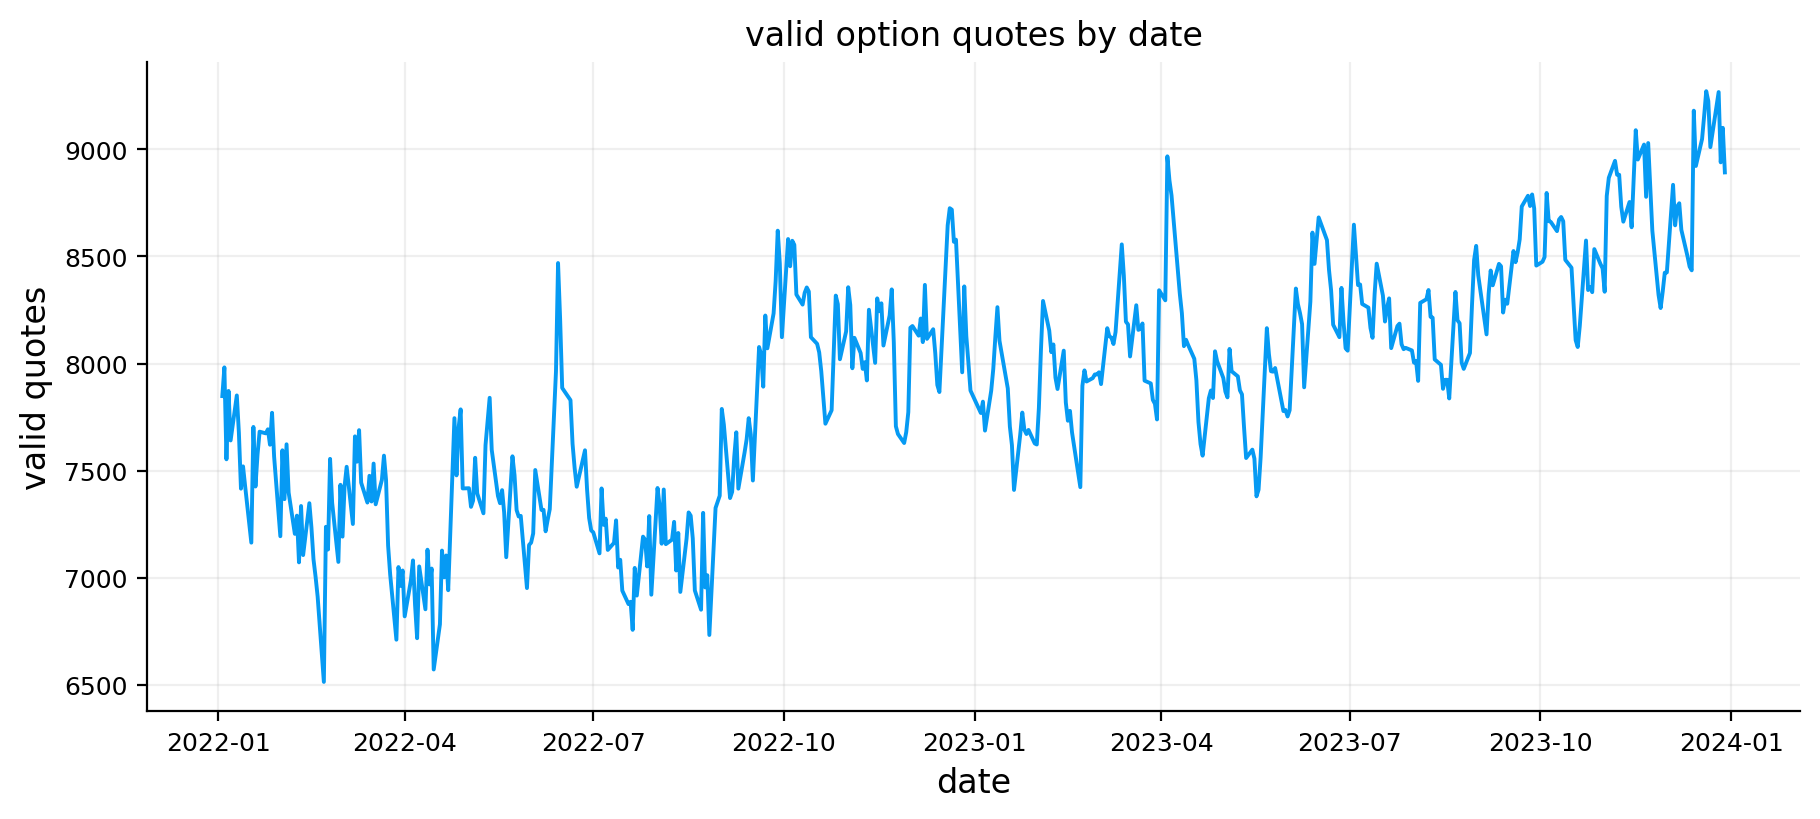

In [10]:
data_quality_summary = pd.DataFrame([{
    "number_of_dates": int(quote_panel["date"].nunique()),
    "number_of_expiries": int(quote_panel["expiry"].nunique()),
    "number_of_raw_quotes": int(len(q_long)),
    "number_of_valid_iv_quotes": int(quote_panel["iv_ok"].sum()),
    "median_relative_spread": float(np.nanmedian(quote_panel["relative_spread"])),
    "median_dte": float(np.nanmedian(quote_panel["dte_days"])),
    "median_vega": float(np.nanmedian(np.abs(quote_panel["vega"]))),
}])
display(data_quality_summary)

by_date_iv = quote_panel[quote_panel["iv_ok"]].groupby("date").size().rename("valid_quotes").reset_index()
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.plot(by_date_iv["date"], by_date_iv["valid_quotes"], lw=1.4)
ax.set_title("valid option quotes by date")
ax.set_xlabel("date")
ax.set_ylabel("valid quotes")
plt.tight_layout()
plt.show()

In [11]:
q_surface = surface_ready_quotes(
    quote_panel,
    min_iv=0.03,
    max_iv=2.50,
    min_tau=7.0 / ann_days,
    max_tau=180.0 / ann_days,
)
q_surface["total_var"] = q_surface["total_variance"]
q_surface["log_moneyness"] = q_surface["k"]

In [12]:
min_dte, max_dte, min_vega, max_rel_spread = 14.0, 150.0, 8.0, 0.45
max_abs_k, min_quotes_per_expiry, min_expiries_per_date = 0.32, 8, 5
def make_otm_quotes(q, min_vega_use=None, max_rel_spread_use=None, min_quotes_use=None):
    x = q.copy()
    rows = []
    vega_floor = min_vega if min_vega_use is None else float(min_vega_use)
    spread_cap = max_rel_spread if max_rel_spread_use is None else float(max_rel_spread_use)
    strike_floor = min_quotes_per_expiry if min_quotes_use is None else int(min_quotes_use)

    def cut(name, mask):
        nonlocal x
        before = len(x)
        x = x.loc[mask].copy()
        rows.append({"step": name, "rows": len(x), "removed": before - len(x)})

    rows.append({"step": "surface ready", "rows": len(x), "removed": 0})
    cut("positive quotes", (x["bid"] > 0) & (x["ask"] >= x["bid"]) & (x["mid"] > 0))
    cut("valid iv inputs", x["iv_ok"].fillna(False) & np.isfinite(x["forward"]) & np.isfinite(x["discount_factor"]) & (x["forward"] > 0) & (x["discount_factor"] > 0))
    cut("dte window", x["dte_days"].between(min_dte, max_dte))
    cut("k window", x["k"].between(-max_abs_k, max_abs_k))
    cut("vega and spread", (np.abs(x["vega"]) >= vega_floor) & x["relative_spread"].between(0.0, spread_cap))

    atm = 0.0125
    x["otm_type"] = np.where(x["k"] < -atm, "put", np.where(x["k"] > atm, "call", "either"))
    med_spread = float(np.nanmedian(x["relative_spread"])) if x["relative_spread"].notna().any() else 0.25
    x["q_score"] = x["relative_spread"].fillna(med_spread) + 0.02 * x["k"].abs()
    x["type_penalty"] = np.where((x["otm_type"] == "either") | (x["option_type"] == x["otm_type"]), 0.0, 1.0)
    before = len(x)
    x = x.sort_values(["date", "expiry", "strike", "type_penalty", "q_score"]).drop_duplicates(["date", "expiry", "strike"], keep="first").copy()
    rows.append({"step": "one otm leg per strike", "rows": len(x), "removed": before - len(x)})

    n = x.groupby(["date", "expiry"]).size().rename("n")
    keep = n[n >= strike_floor].index
    before = len(x)
    x = x.loc[x.set_index(["date", "expiry"]).index.isin(keep)].copy()
    rows.append({"step": "enough strikes", "rows": len(x), "removed": before - len(x)})

    m = x.groupby("date")["expiry"].nunique().rename("m")
    keep_dates = m[m >= min_expiries_per_date].index
    before = len(x)
    x = x[x["date"].isin(keep_dates)].copy()
    rows.append({"step": "enough expiries", "rows": len(x), "removed": before - len(x)})

    x = x.sort_values(["date", "expiry", "strike"]).reset_index(drop=True)
    x["quote_id"] = np.arange(len(x), dtype=int)
    x["contract_id"] = x["option_type"].astype(str) + "_" + pd.to_datetime(x["expiry"]).dt.strftime("%Y-%m-%d") + "_" + x["strike"].round(6).astype(str)
    return x, pd.DataFrame(rows)

In [13]:
min_vega_model, max_rel_spread_model, n_model_dates = 2.0, 0.65, 6
calibration_panel, rejection_summary = make_otm_quotes(q_surface)
model_panel, model_rejection_summary = make_otm_quotes(q_surface, min_vega_use=min_vega_model, max_rel_spread_use=max_rel_spread_model, min_quotes_use=7)
calibration_panel["contract_key"] = make_contract_key(calibration_panel)
model_panel["contract_key"] = make_contract_key(model_panel)
calibration_panel["contract_id"] = calibration_panel["contract_key"]
model_panel["contract_id"] = model_panel["contract_key"]
support0 = quote_support_by_date(calibration_panel, k_col="k", tau_col="tau")
by_date = calibration_panel.groupby("date").agg(
    quotes=("quote_id", "size"),
    expiries=("expiry", "nunique"),
    median_relative_spread=("relative_spread", "median"),
    median_iv=("iv_mid", "median"),
    k_min=("k", "min"),
    k_max=("k", "max"),
    near_atm_quotes=("k", lambda z: int(np.sum(np.abs(z) <= 0.035))),
    wing_quotes=("k", lambda z: int(np.sum(np.abs(z) >= 0.15))),
).reset_index()
model_by_date = model_panel.groupby("date").agg(
    model_quotes=("quote_id", "size"),
    model_expiries=("expiry", "nunique"),
    model_k_min=("k", "min"),
    model_k_max=("k", "max"),
    model_left_tail=("k", lambda z: int(np.sum(z <= -0.14))),
    model_right_tail=("k", lambda z: int(np.sum(z >= 0.10))),
    model_tail_count=("k", lambda z: int(np.sum(np.abs(z) >= 0.14))),
).reset_index()
surface_support_by_date = support0.merge(by_date, on="date", how="left", suffixes=("", "_detail"))
surface_support_by_date = surface_support_by_date.merge(model_by_date, on="date", how="left")
surface_support_by_date["k_width"] = surface_support_by_date["k_max_detail"] - surface_support_by_date["k_min_detail"]
surface_support_by_date["model_k_width"] = surface_support_by_date["model_k_max"] - surface_support_by_date["model_k_min"]
surface_support_by_date["score"] = (
    surface_support_by_date["quotes"].fillna(0)
    + 25.0 * surface_support_by_date["expiries"].fillna(0)
    + 1.5 * surface_support_by_date["near_atm_quotes"].fillna(0)
    + surface_support_by_date["wing_quotes"].fillna(0)
    + 0.6 * surface_support_by_date["model_tail_count"].fillna(0)
    + 150.0 * surface_support_by_date["model_k_width"].fillna(0)
    + 120.0 * surface_support_by_date["k_width"].fillna(0)
    - 80.0 * surface_support_by_date["median_relative_spread"].fillna(0.50)
)
good_dates = surface_support_by_date[
    (surface_support_by_date["quotes"] >= 120)
    & (surface_support_by_date["expiries"] >= min_expiries_per_date)
    & (surface_support_by_date["near_atm_quotes"] >= 18)
].copy()
if good_dates.empty:
    good_dates = surface_support_by_date.sort_values("score", ascending=False).head(20).copy()
tail_dates = good_dates[
    (good_dates["model_left_tail"].fillna(0) >= 8)
    & (good_dates["model_tail_count"].fillna(0) >= 16)
].copy()
main_pool = tail_dates if not tail_dates.empty else good_dates
recent_cut = main_pool["date"].quantile(0.65)
main_date = pd.Timestamp(main_pool[main_pool["date"] >= recent_cut].sort_values("score", ascending=False).iloc[0]["date"]).normalize()
date_panel_dates = good_dates.sort_values("score", ascending=False).head(n_model_dates)["date"].sort_values().to_numpy()
q0 = calibration_panel[calibration_panel["date"].eq(main_date)].copy()
q_model0 = model_panel[model_panel["date"].eq(main_date)].copy()
date_panel = calibration_panel[calibration_panel["date"].isin(date_panel_dates)].copy()
date_model_panel = model_panel[model_panel["date"].isin(date_panel_dates)].copy()
display(rejection_summary)
display(model_rejection_summary)
display(surface_support_by_date.sort_values("score", ascending=False).head(8)[["date", "quotes", "expiries", "near_atm_quotes", "wing_quotes", "model_left_tail", "model_right_tail", "model_tail_count", "model_k_min", "model_k_max", "median_relative_spread", "score"]])
print(f"main_date: {main_date.date()}; clean quotes: {len(q0):,}; model quotes: {len(q_model0):,}; expiries: {q0['expiry'].nunique():,}")

,step,rows,removed
0,surface ready,3989266,0
1,positive quotes,3989266,0
2,valid iv inputs,3989266,0
3,dte window,3060367,928899
4,k window,3019732,40635
5,vega and spread,3005563,14169
6,one otm leg per strike,1515066,1490497
7,enough strikes,1515066,0
8,enough expiries,1515066,0


,step,rows,removed
0,surface ready,3989266,0
1,positive quotes,3989266,0
2,valid iv inputs,3989266,0
3,dte window,3060367,928899
4,k window,3019732,40635
5,vega and spread,3018842,890
6,one otm leg per strike,1519842,1499000
7,enough strikes,1519842,0
8,enough expiries,1519842,0


,date,quotes,expiries,near_atm_quotes,wing_quotes,model_left_tail,model_right_tail,model_tail_count,model_k_min,model_k_max,median_relative_spread,score
498,2023-12-20,3873,29,1563,381,415,70,432,-0.319768,0.259187,0.031088,"7,734.766086"
499,2023-12-21,3867,29,1467,412,442,79,458,-0.315042,0.249627,0.025157,"7,629.748012"
497,2023-12-19,3835,29,1380,424,490,85,511,-0.318249,0.244649,0.019048,"7,511.058495"
500,2023-12-22,3756,28,1442,394,427,63,444,-0.316721,0.247947,0.022326,"7,428.315973"
494,2023-12-14,3633,27,1305,402,456,45,468,-0.319200,0.224761,0.032787,"7,092.546581"
496,2023-12-18,3582,28,1286,425,484,67,503,-0.319879,0.236780,0.022892,"7,086.266515"
501,2023-12-26,3600,27,1334,380,435,50,454,-0.319388,0.275328,0.021978,"7,083.405063"
495,2023-12-15,3534,27,1311,409,464,57,478,-0.319863,0.241519,0.033898,"7,018.177775"


main_date: 2023-12-20; clean quotes: 3,873; model quotes: 3,885; expiries: 29


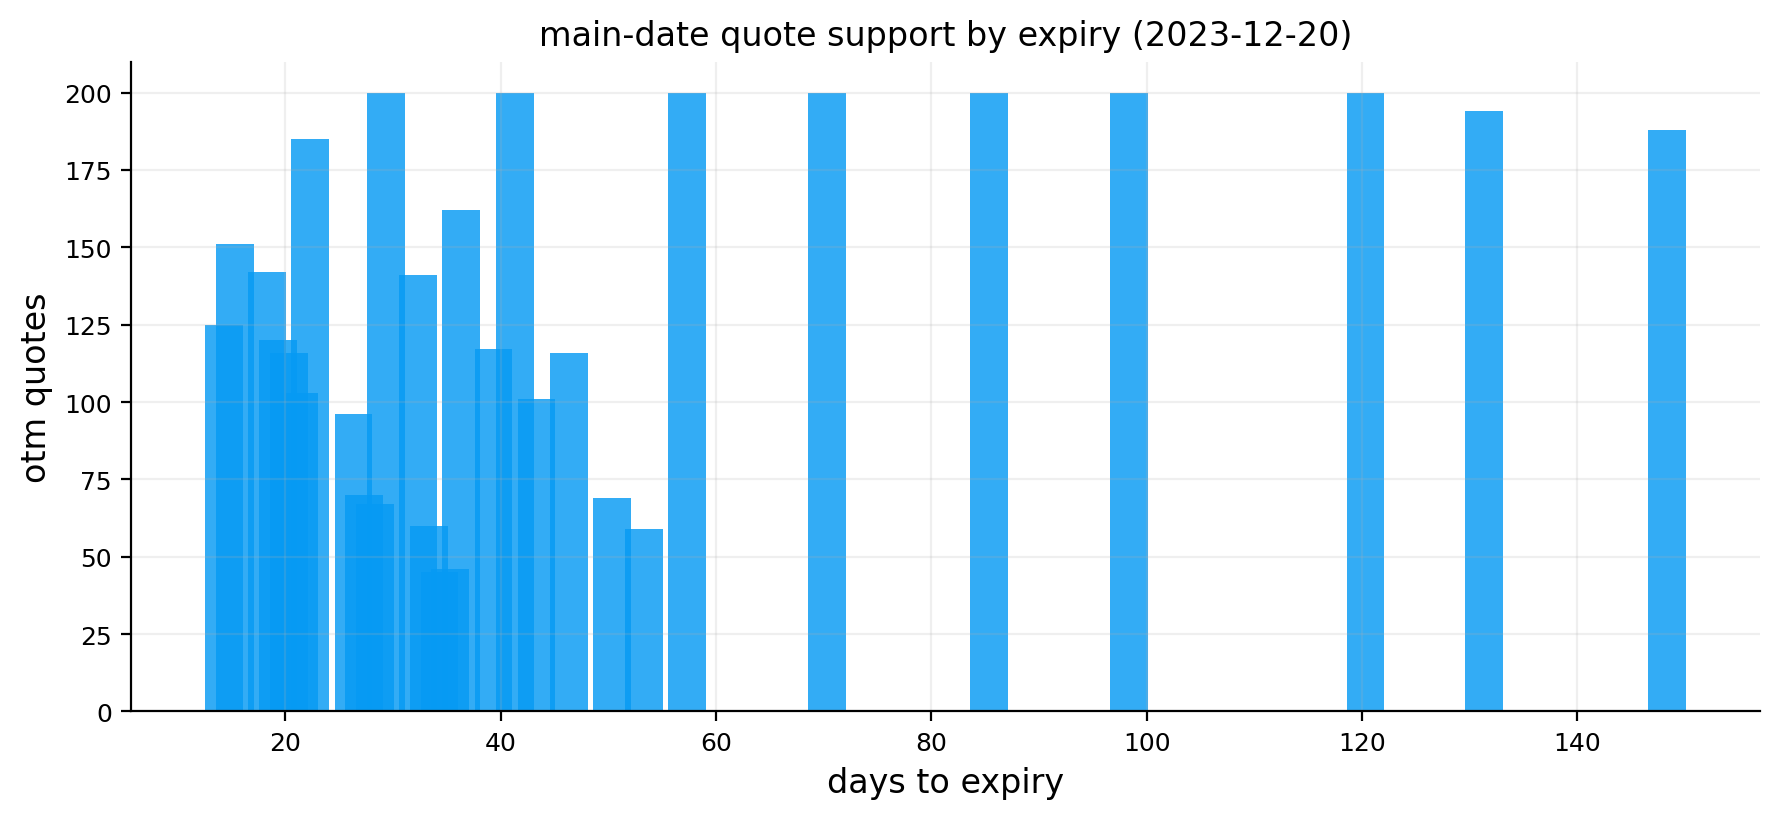

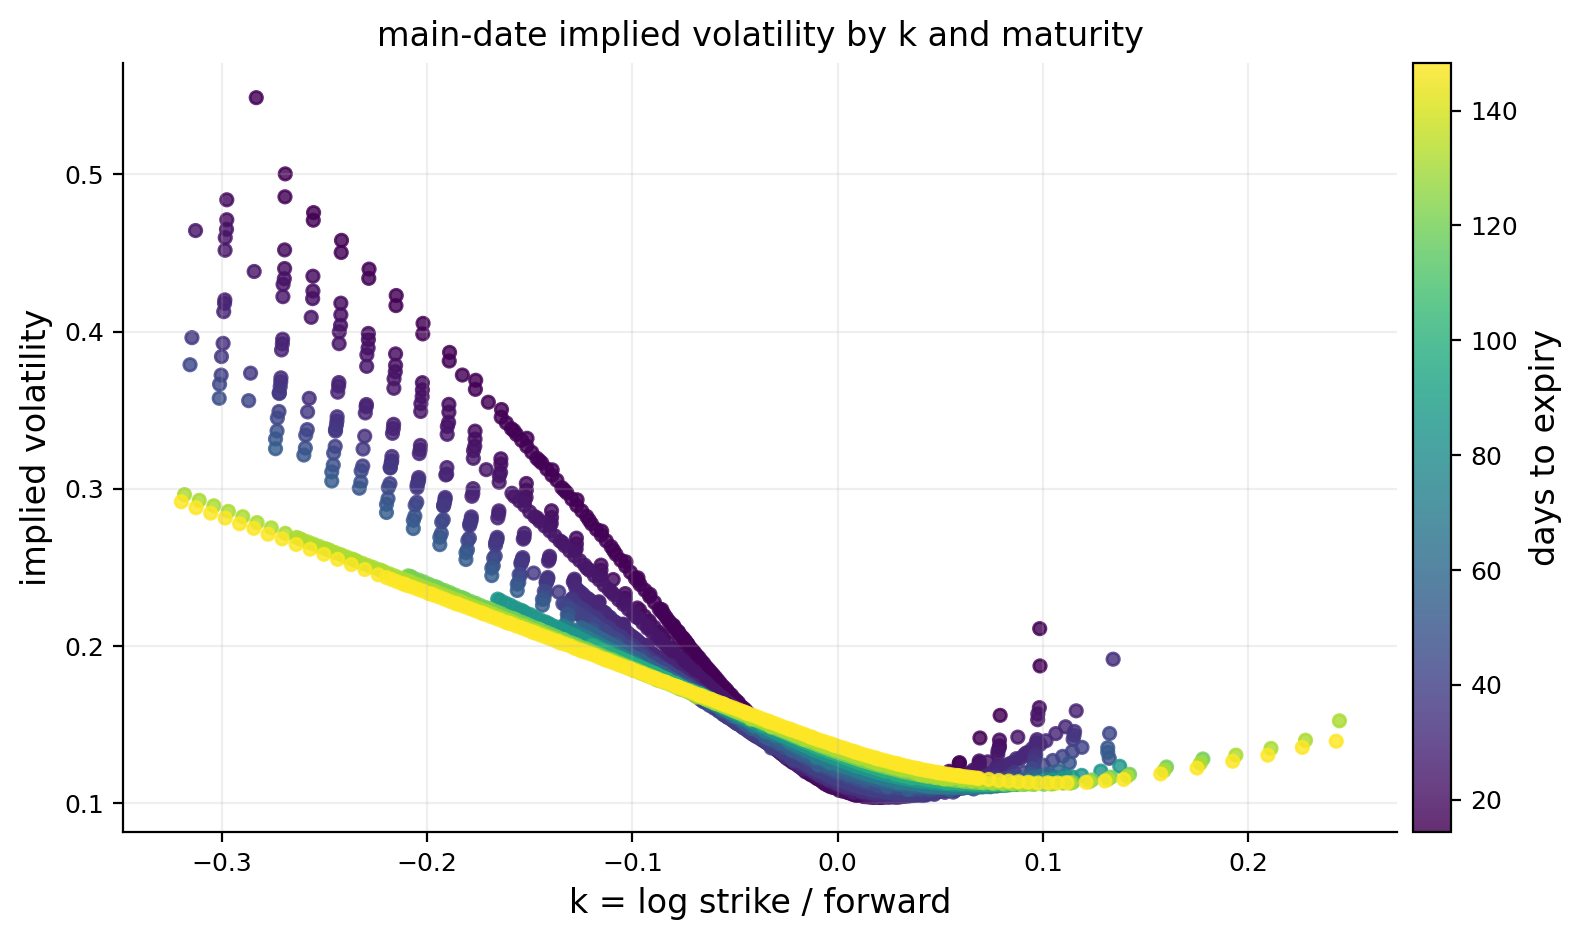

In [14]:
expiry_support = q0.groupby("expiry").agg(n=("quote_id", "size"), dte=("dte_days", "median")).sort_values("dte")
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(expiry_support["dte"], expiry_support["n"], width=3.5, alpha=0.82)
ax.set_title(f"main-date quote support by expiry ({main_date.date()})")
ax.set_xlabel("days to expiry")
ax.set_ylabel("otm quotes")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 4.8))
sc = ax.scatter(q0["k"], q0["iv_mid"], c=q0["dte_days"], s=20, alpha=0.82, cmap="viridis")
ax.set_title("main-date implied volatility by k and maturity")
ax.set_xlabel("k = log strike / forward")
ax.set_ylabel("implied volatility")
fig.colorbar(sc, ax=ax, pad=0.01, label="days to expiry")
plt.tight_layout()
plt.show()

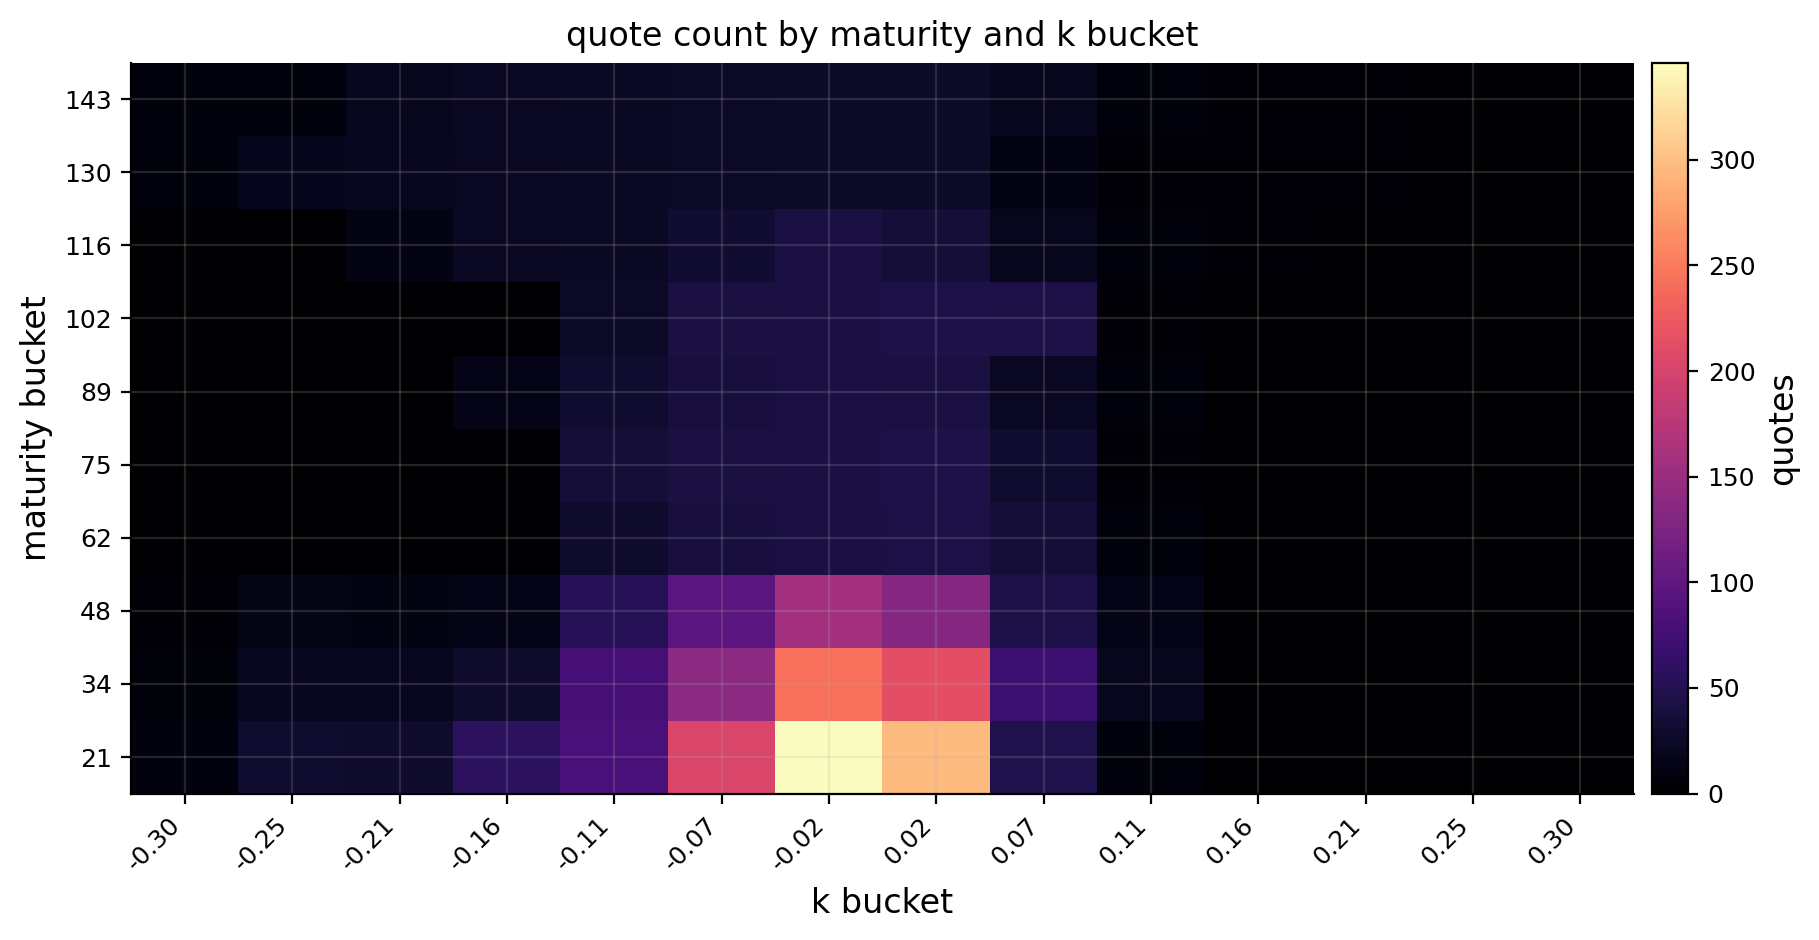

In [15]:
z = q0.copy()
z["k_bin"] = pd.cut(z["k"], np.linspace(-max_abs_k, max_abs_k, 15))
z["dte_bin"] = pd.cut(z["dte_days"], np.linspace(min_dte, max_dte, 11))
h = z.pivot_table(index="dte_bin", columns="k_bin", values="quote_id", aggfunc="count", observed=False)
fig, ax = plt.subplots(figsize=(9.8, 4.8))
im = ax.imshow(h.fillna(0).to_numpy(), aspect="auto", origin="lower", cmap="magma")
ax.set_title("quote count by maturity and k bucket")
ax.set_xlabel("k bucket")
ax.set_ylabel("maturity bucket")
ax.set_xticks(np.arange(h.shape[1]))
ax.set_xticklabels([f"{b.mid:.2f}" for b in h.columns], rotation=45, ha="right")
ax.set_yticks(np.arange(h.shape[0]))
ax.set_yticklabels([f"{b.mid:.0f}" for b in h.index])
fig.colorbar(im, ax=ax, pad=0.01, label="quotes")
plt.tight_layout()
plt.show()

In [16]:

def add_quote_sigma(q):
    x = q.copy()
    x["half_spread"] = 0.5 * (pd.to_numeric(x["ask"], errors="coerce") - pd.to_numeric(x["bid"], errors="coerce")).clip(lower=0.0)
    vega = np.abs(pd.to_numeric(x["vega"], errors="coerce"))
    x["iv_width"] = (pd.to_numeric(x["iv_ask"], errors="coerce") - pd.to_numeric(x["iv_bid"], errors="coerce")).where(lambda s: np.isfinite(s) & (s > 0))
    x["sigma_iv_direct"] = 0.5 * x["iv_width"]
    x["sigma_iv_px"] = x["half_spread"] / vega.replace(0, np.nan)
    eps_iv = pd.concat([x["sigma_iv_direct"], x["sigma_iv_px"]], axis=1).max(axis=1)
    med = float(np.nanmedian(eps_iv)) if np.isfinite(eps_iv).any() else 0.020
    x["eps_iv"] = eps_iv.fillna(med).clip(lower=0.0025, upper=0.40)
    x["total_var"] = x["iv_mid"] ** 2 * x["tau"]
    x["eps_w"] = (2.0 * x["iv_mid"].abs() * x["tau"] * x["eps_iv"]).clip(lower=1e-5)
    x["calib_scale_px"] = np.maximum(x["half_spread"], 0.25 * vega * x["eps_iv"]).clip(lower=0.02)
    x["eps_px"] = np.maximum(x["half_spread"], vega * x["eps_iv"]).clip(lower=0.02)
    x["expected_exit_half_spread"] = x.groupby(["date", "expiry"])["half_spread"].transform("median").fillna(x["half_spread"].median())
    x["trade_cost_px"] = x["half_spread"] + 0.5 * x["expected_exit_half_spread"]

    spread = x["relative_spread"].replace([np.inf, -np.inf], np.nan)
    spread_med = float(np.nanmedian(spread[(spread > 0) & np.isfinite(spread)])) if spread.notna().any() else 0.10
    spread = spread.fillna(spread_med).clip(lower=0.003, upper=1.0)
    w_spread = 1.0 / (spread.to_numpy(dtype=float) ** 2 + 0.03 ** 2)
    w_spread = w_spread / max(float(np.nanmedian(w_spread)), 1e-12)

    vega_med = float(np.nanmedian(vega[(vega > 0) & np.isfinite(vega)])) if np.isfinite(vega).any() else 1.0
    w_vega = np.clip((vega.to_numpy(dtype=float) / max(vega_med, 1e-12)) ** 0.40, 0.20, 3.0)
    eps = x["eps_iv"].to_numpy(dtype=float)
    eps_med = float(np.nanmedian(eps[np.isfinite(eps) & (eps > 0)])) if np.isfinite(eps).any() else 0.02
    w_eps = np.clip(eps / max(eps_med, 1e-12), 0.45, 4.0) ** -0.70
    w_k = np.exp(-np.maximum(np.abs(x["k"].to_numpy(dtype=float)) - 0.12, 0.0) / 0.35)
    n_exp = x.groupby(["date", "expiry"])["quote_id"].transform("count").to_numpy(dtype=float)
    w_tau = 1.0 / np.sqrt(np.maximum(n_exp, 1.0))
    w_tau = w_tau / max(float(np.nanmedian(w_tau)), 1e-12)
    wt = w_spread * w_vega * w_eps * w_k * w_tau
    wt = wt / max(float(np.nanmedian(wt[np.isfinite(wt)])), 1e-12)
    x["w_spread"] = w_spread
    x["w_vega"] = w_vega
    x["w_eps"] = w_eps
    x["w_k"] = w_k
    x["w_tau"] = w_tau
    x["weight"] = np.clip(wt, 0.05, 20.0)
    return x


In [17]:
calibration_panel = add_quote_sigma(calibration_panel)
model_panel = add_quote_sigma(model_panel)
q0 = calibration_panel[calibration_panel["date"].eq(main_date)].copy()
q_model0 = model_panel[model_panel["date"].eq(main_date)].copy()
date_panel = calibration_panel[calibration_panel["date"].isin(date_panel_dates)].copy()
date_model_panel = model_panel[model_panel["date"].isin(date_panel_dates)].copy()
uncertainty_by_maturity = q0.assign(dte_bucket=pd.cut(q0["dte_days"], bins=[0, 21, 45, 75, 110, 180])).groupby("dte_bucket", observed=False).agg(
    quotes=("quote_id", "size"),
    median_eps_iv=("eps_iv", "median"),
    median_eps_px=("eps_px", "median"),
    median_weight=("weight", "median"),
).reset_index()
display(uncertainty_by_maturity)

,dte_bucket,quotes,median_eps_iv,median_eps_px,median_weight
0,"(0, 21]",654,0.002500,0.439562,0.265759
1,"(21, 45]",1593,0.002500,0.786292,0.486536
2,"(45, 75]",644,0.002500,1.314566,0.755503
3,"(75, 110]",400,0.002500,1.737149,0.984168
4,"(110, 180]",582,0.002500,1.919746,0.980406


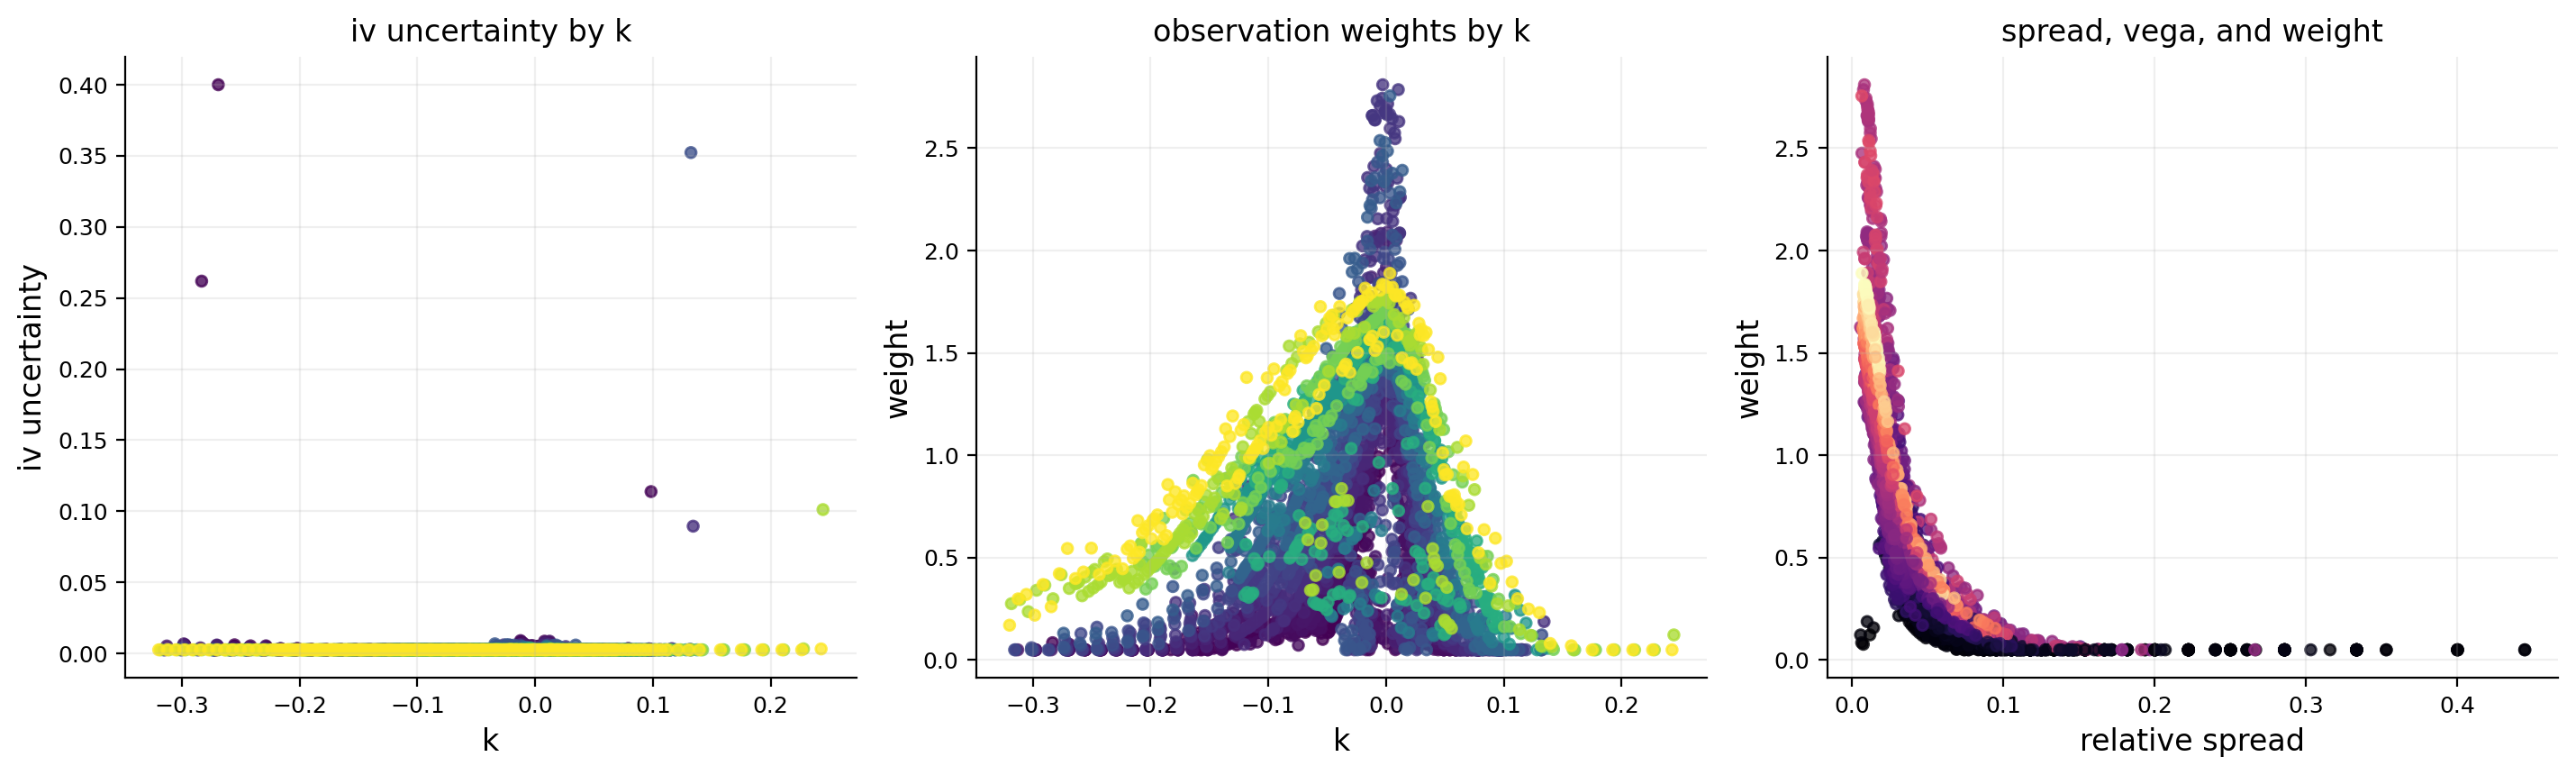

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.4))
axes[0].scatter(q0["k"], q0["eps_iv"], c=q0["dte_days"], cmap="viridis", s=18, alpha=0.78)
axes[0].set_title("iv uncertainty by k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("iv uncertainty")
axes[1].scatter(q0["k"], q0["weight"], c=q0["dte_days"], cmap="viridis", s=18, alpha=0.78)
axes[1].set_title("observation weights by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("weight")
axes[2].scatter(q0["relative_spread"], q0["weight"], c=np.abs(q0["vega"]), cmap="magma", s=18, alpha=0.78)
axes[2].set_title("spread, vega, and weight")
axes[2].set_xlabel("relative spread")
axes[2].set_ylabel("weight")
plt.tight_layout()
plt.show()

In [19]:
targets = pd.DataFrame([
    {"model": "svi", "target": "total variance", "scale": "eps_w"},
    {"model": "ssvi", "target": "total variance", "scale": "eps_w"},
    {"model": "sabr", "target": "implied volatility", "scale": "eps_iv"},
    {"model": "merton", "target": "otm price", "scale": "eps_px"},
    {"model": "heston", "target": "otm price", "scale": "eps_px"},
    {"model": "bates", "target": "otm price", "scale": "eps_px"},
])
display(targets)

,model,target,scale
0,svi,total variance,eps_w
1,ssvi,total variance,eps_w
2,sabr,implied volatility,eps_iv
3,merton,otm price,eps_px
4,heston,otm price,eps_px
5,bates,otm price,eps_px


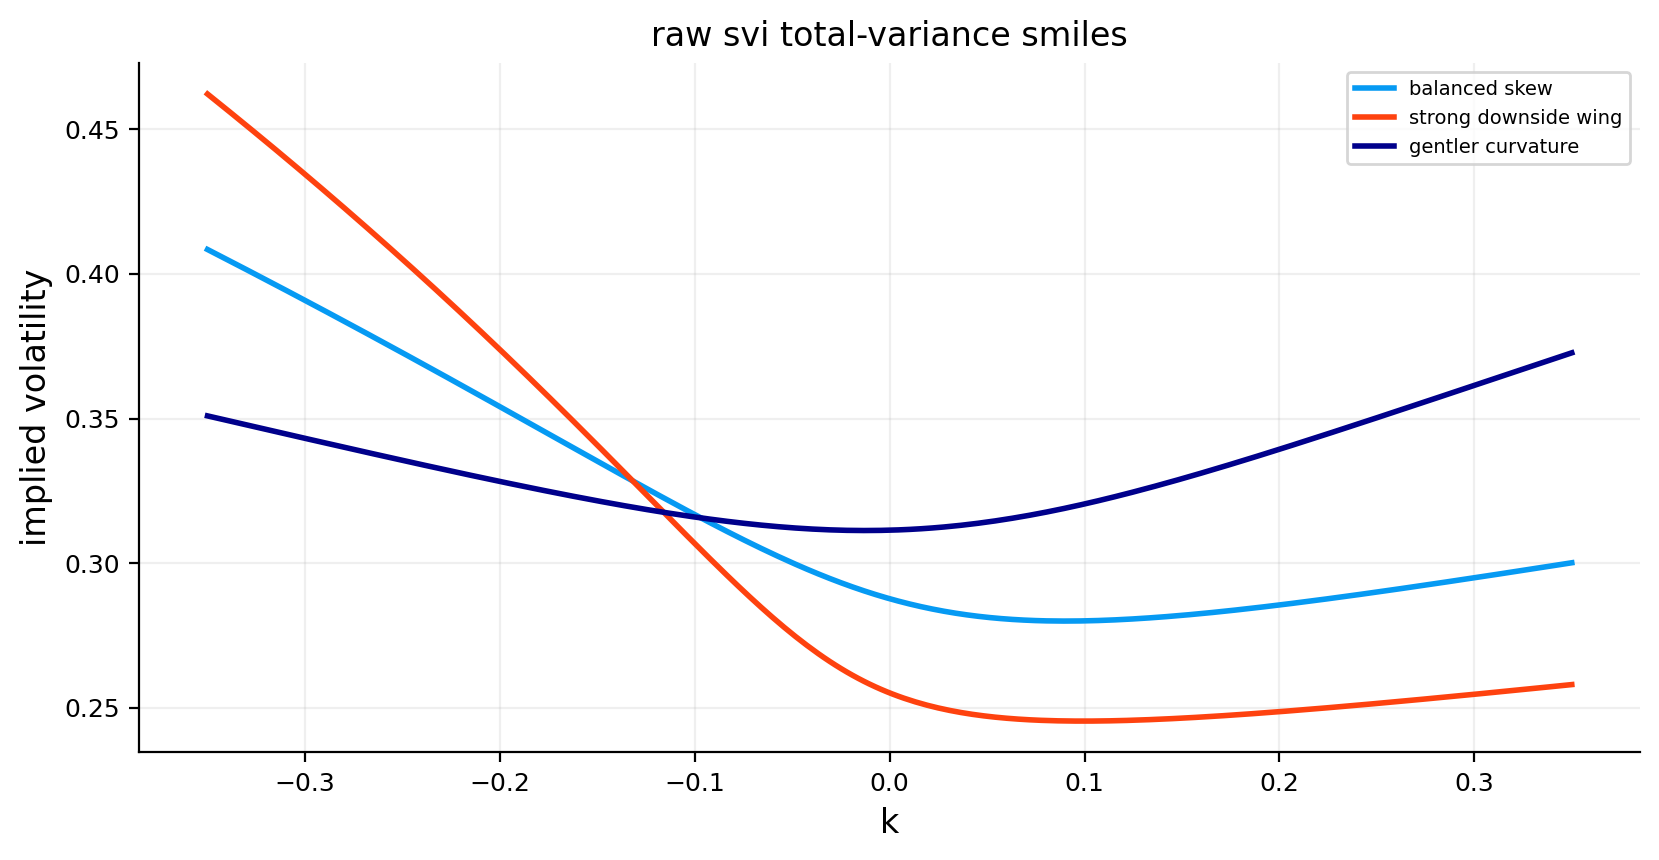

In [20]:
def svi_w_demo(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))


k_line = np.linspace(-0.35, 0.35, 240)
tau_demo = 60.0 / ann_days
p_demo = [
    (0.010, 0.030, -0.60, 0.000, 0.120, "balanced skew"),
    (0.008, 0.045, -0.85, -0.030, 0.080, "strong downside wing"),
    (0.012, 0.025, 0.20, 0.020, 0.160, "gentler curvature"),
]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
for a, b, rho, m, sigma, label in p_demo:
    ax.plot(k_line, np.sqrt(np.maximum(svi_w_demo(k_line, a, b, rho, m, sigma), 1e-8) / tau_demo), lw=2.0, label=label)
ax.set_title("raw svi total-variance smiles")
ax.set_xlabel("k")
ax.set_ylabel("implied volatility")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
@njit
def svi_w(k, a, b, rho, m, sigma):
    out = np.empty(k.size, dtype=np.float64)
    for i in range(k.size):
        x = k[i] - m
        out[i] = a + b * (rho * x + math.sqrt(x * x + sigma * sigma))
    return out


@njit
def svi_iv(k, tau, a, b, rho, m, sigma):
    w = svi_w(k, a, b, rho, m, sigma)
    out = np.empty(k.size, dtype=np.float64)
    for i in range(k.size):
        out[i] = math.sqrt(max(w[i], 1e-12) / max(tau[i], 1e-12))
    return out


t0 = tic()
_ = svi_w(np.array([0.0, 0.1]), 0.01, 0.04, -0.4, 0.0, 0.12)
svi_compile_time = toc("compile svi", t0, 2)

In [22]:
def wrmse(x, wt):
    x = np.asarray(x, dtype=float)
    wt = np.asarray(wt, dtype=float)
    ok = np.isfinite(x) & np.isfinite(wt) & (wt > 0)
    if ok.sum() == 0:
        return np.nan
    return float(np.sqrt(np.average(x[ok] ** 2, weights=wt[ok])))


def near_bound(p, lo, hi, tol=2e-3):
    p = np.asarray(p, dtype=float)
    lo = np.asarray(lo, dtype=float)
    hi = np.asarray(hi, dtype=float)
    scale = np.maximum(hi - lo, 1e-12)
    return bool(np.any((p - lo) / scale < tol) or np.any((hi - p) / scale < tol))

In [23]:
def svi_starts(q, p_prev=None):
    k = q["k"].to_numpy(dtype=float)
    w = q["total_var"].to_numpy(dtype=float)
    iv = q["iv_mid"].to_numpy(dtype=float)
    i0 = int(np.nanargmin(np.abs(k)))
    w0 = float(np.clip(w[i0], 1e-5, 2.0))
    slope = float(np.polyfit(k, w, 1)[0]) if len(q) >= 5 else 0.0
    starts = [
        np.array([0.35 * w0, max(0.02, 1.2 * abs(slope)), -0.50, 0.0, 0.10]),
        np.array([0.20 * w0, max(0.03, 0.8 * np.nanmedian(iv) ** 2), -0.75, float(k[i0]), 0.08]),
        np.array([0.55 * w0, max(0.01, 0.5 * abs(slope) + 0.015), -0.25, float(np.nanmedian(k)), 0.18]),
    ]
    if p_prev is not None and np.all(np.isfinite(p_prev)):
        starts.insert(0, np.asarray(p_prev, dtype=float))
    return starts


def fit_svi_slice(q, p_prev=None):
    z = q.sort_values("k").copy()
    k = z["k"].to_numpy(dtype=float)
    y = z["total_var"].to_numpy(dtype=float)
    eps = z["eps_w"].to_numpy(dtype=float)
    eps_med = float(np.nanmedian(eps[np.isfinite(eps) & (eps > 0)])) if np.isfinite(eps).any() else 1e-4
    eps = np.clip(eps, max(1e-5, 0.25 * eps_med), 0.25)
    root_wt = np.sqrt(z["weight"].to_numpy(dtype=float))
    lo = np.array([-0.20, 1e-5, -0.999, -0.80, 1e-4])
    hi = np.array([2.00, 5.00, 0.999, 0.80, 2.00])

    def err(p):
        w = np.asarray(svi_w(k, p[0], p[1], p[2], p[3], p[4]), dtype=float)
        r = root_wt * (w - y) / eps
        r = np.where((~np.isfinite(w)) | (w <= 1e-8), 1e3, r)
        k_grid = np.linspace(np.nanmin(k), np.nanmax(k), 25)
        w_grid = np.asarray(svi_w(k_grid, p[0], p[1], p[2], p[3], p[4]), dtype=float)
        pen = max(0.0, 1e-7 - float(np.nanmin(w_grid))) * 1e5
        return np.r_[r, pen]

    best = None
    for p0 in svi_starts(z, p_prev):
        t0 = tic()
        res = optimize.least_squares(
            err,
            np.clip(p0, lo + 1e-8, hi - 1e-8),
            bounds=(lo, hi),
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=180,
            xtol=1e-8,
            ftol=1e-8,
        )
        item = {"res": res, "cost": float(res.cost), "seconds": time.perf_counter() - t0}
        if best is None or item["cost"] < best["cost"]:
            best = item
    return best["res"].x, best["res"].success, best["seconds"], best["res"].nfev, lo, hi

In [24]:
def fit_svi(q):
    p_rows = []
    f_rows = []
    d_rows = []
    p_prev = None
    for expiry, g in q.groupby("expiry", sort=True):
        g = g.sort_values("k").copy()
        tau = float(g["tau"].median())
        dte = float(g["dte_days"].median())
        if len(g) < min_quotes_per_expiry:
            d_rows.append({"expiry": expiry, "tau": tau, "dte_days": dte, "success": False, "n_quotes": len(g), "reason": "too few quotes"})
            continue
        p, ok, seconds, nfev, lo, hi = fit_svi_slice(g, p_prev)
        p_prev = p if ok else p_prev
        w_hat = np.asarray(svi_w(g["k"].to_numpy(dtype=float), *p), dtype=float)
        iv_hat = np.sqrt(np.maximum(w_hat, 1e-12) / g["tau"].to_numpy(dtype=float))
        px_hat = black76_price(g["option_type"].to_numpy(), g["forward"], g["strike"], g["tau"], iv_hat, g["discount_factor"])
        e_iv = iv_hat - g["iv_mid"].to_numpy(dtype=float)
        e_w = w_hat - g["total_var"].to_numpy(dtype=float)
        wt = g["weight"].to_numpy(dtype=float)
        d_rows.append({
            "expiry": expiry,
            "tau": tau,
            "dte_days": dte,
            "success": bool(ok),
            "n_quotes": int(len(g)),
            "calibration_time": float(seconds),
            "objective_evaluations": int(nfev),
            "weighted_rmse_total_var": wrmse(e_w, wt),
            "weighted_rmse_iv": wrmse(e_iv, wt),
            "median_abs_iv_error": float(np.nanmedian(np.abs(e_iv))),
            "p90_abs_iv_error": float(np.nanquantile(np.abs(e_iv), 0.90)),
            "min_fitted_total_var": float(np.nanmin(w_hat)),
            "parameter_at_bound": near_bound(p, lo, hi),
            "wing_warning": bool(np.nanmin(w_hat) <= 1e-6),
            "reason": "ok" if ok else "optimizer failed",
        })
        p_rows.append({"expiry": expiry, "tau": tau, "dte_days": dte, "a": p[0], "b": p[1], "rho": p[2], "m": p[3], "sigma": p[4], "success": bool(ok)})
        z = g.copy()
        z["model"] = "svi"
        z["model_total_var"] = w_hat
        z["model_iv"] = iv_hat
        z["model_price"] = np.asarray(px_hat, dtype=float)
        z["iv_residual"] = z["model_iv"] - z["iv_mid"]
        z["price_residual"] = z["model_price"] - z["mid"]
        f_rows.append(z)
    fit = pd.concat(f_rows, ignore_index=True) if f_rows else pd.DataFrame()
    return pd.DataFrame(p_rows), fit, pd.DataFrame(d_rows)

In [25]:
t0 = tic()
svi_params, svi_fit, svi_diag = fit_svi(q0)
toc("calibrate raw svi", t0, len(q0))
display(svi_diag[["dte_days", "success", "n_quotes", "weighted_rmse_iv", "median_abs_iv_error", "p90_abs_iv_error", "parameter_at_bound"]].head(12))

,dte_days,success,n_quotes,weighted_rmse_iv,median_abs_iv_error,p90_abs_iv_error,parameter_at_bound
0,14.333333,True,125,0.001079,0.000591,0.002606,False
1,15.333333,True,151,0.003927,0.000319,0.001101,False
2,18.333333,True,142,0.000596,0.000377,0.001410,False
3,19.333333,True,120,0.000562,0.000390,0.001849,False
4,20.333333,True,116,0.000504,0.000356,0.001367,False
5,21.333333,True,103,0.000477,0.000404,0.001593,False
6,22.333333,True,185,0.000687,0.000453,0.001372,False
7,26.333333,True,96,0.000478,0.000394,0.001310,False
8,27.333333,True,70,0.000389,0.000364,0.000939,False
9,28.333333,True,67,0.000541,0.000480,0.001047,False


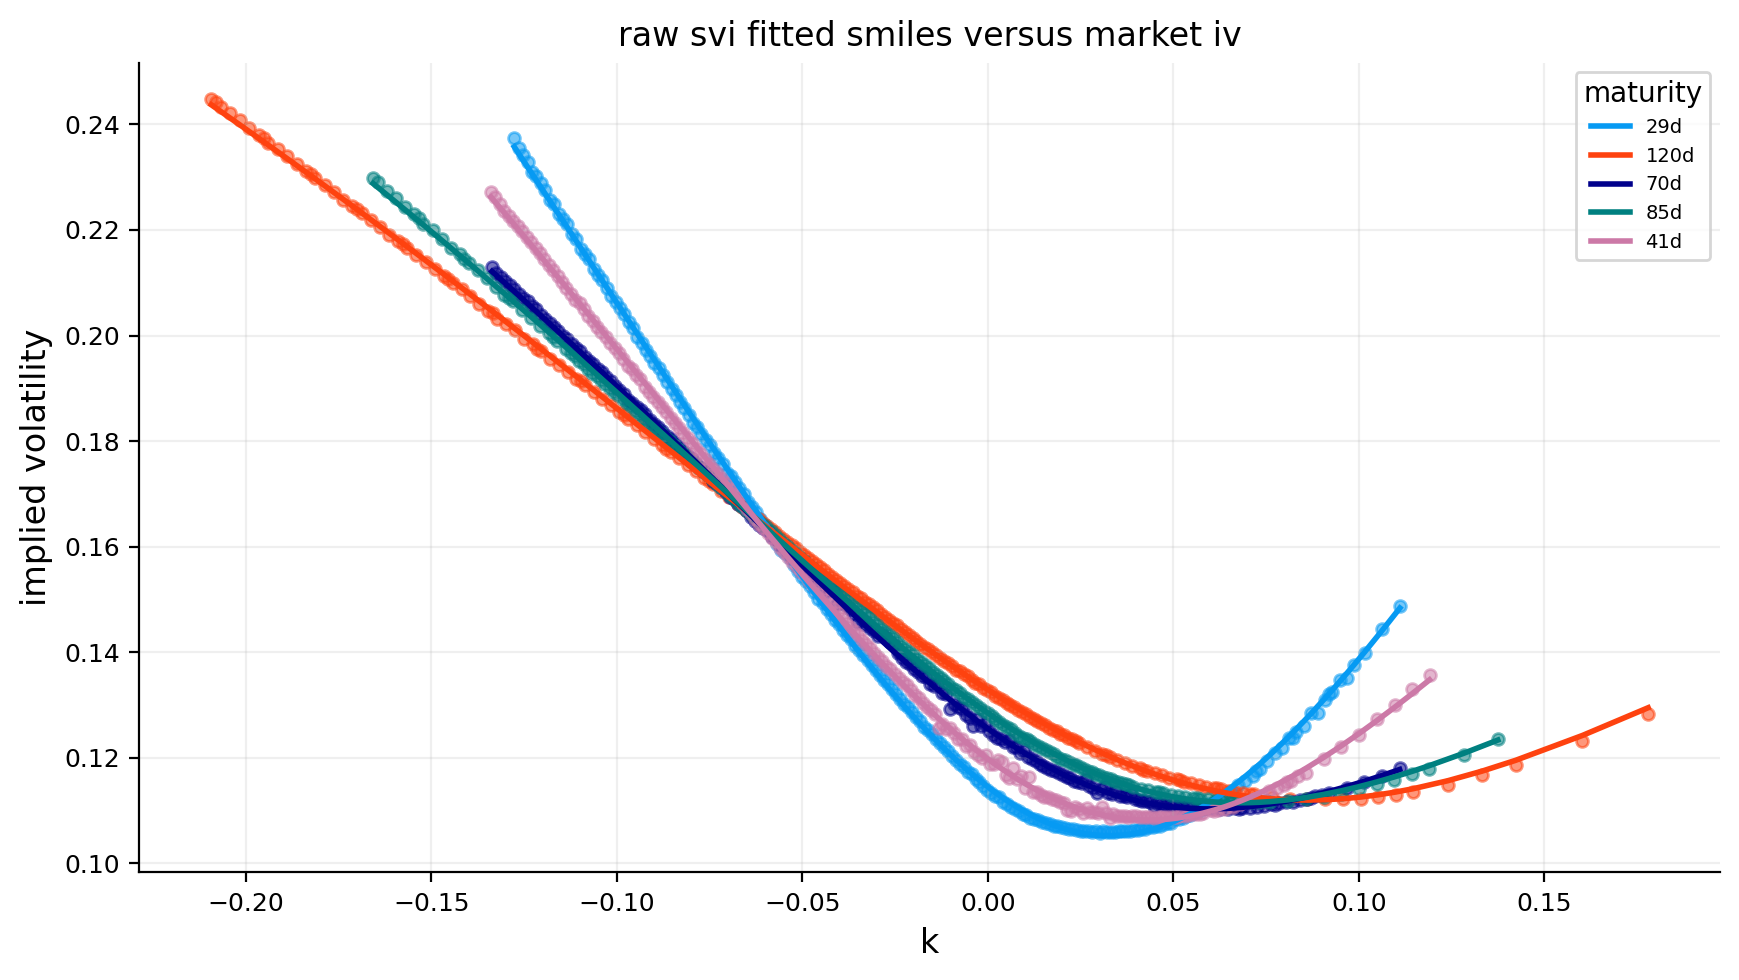

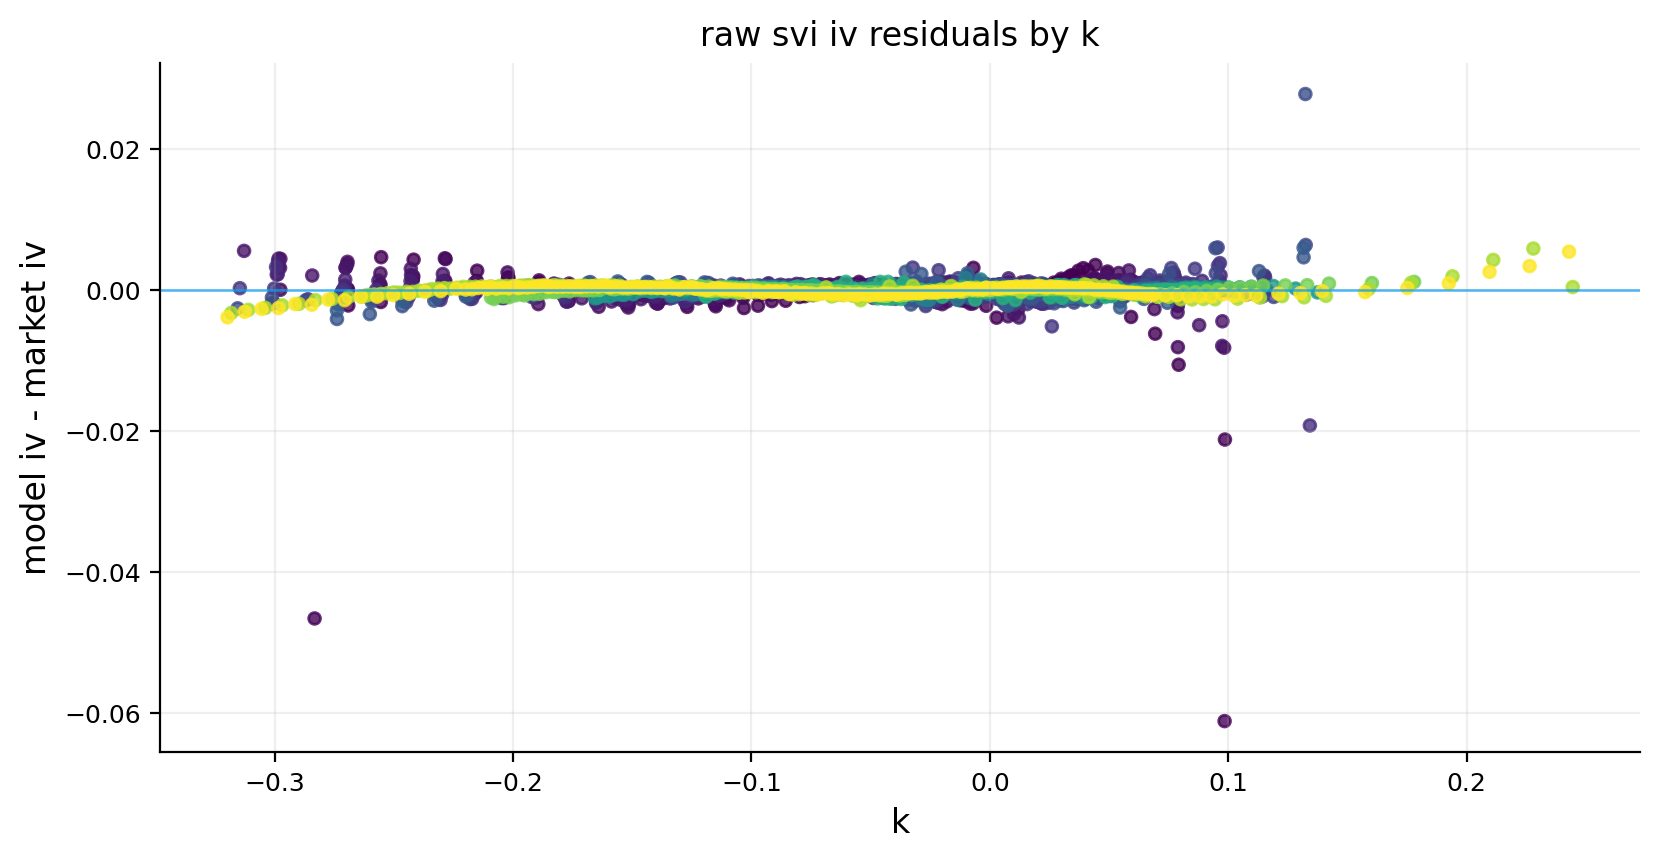

In [26]:
selected_expiries = svi_diag.sort_values("n_quotes", ascending=False).head(5)["expiry"].tolist()
fig, ax = plt.subplots(figsize=(8.8, 5.0))
for expiry in selected_expiries:
    g = svi_fit[svi_fit["expiry"].eq(expiry)].sort_values("k")
    if g.empty:
        continue
    ax.scatter(g["k"], g["iv_mid"], s=18, alpha=0.55)
    ax.plot(g["k"], g["model_iv"], lw=2.0, label=f"{g['dte_days'].median():.0f}d")
ax.set_title("raw svi fitted smiles versus market iv")
ax.set_xlabel("k")
ax.set_ylabel("implied volatility")
ax.legend(title="maturity")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.scatter(svi_fit["k"], svi_fit["iv_residual"], c=svi_fit["dte_days"], cmap="viridis", s=18, alpha=0.80)
ax.axhline(0.0, lw=0.9, alpha=0.70)
ax.set_title("raw svi iv residuals by k")
ax.set_xlabel("k")
ax.set_ylabel("model iv - market iv")
plt.tight_layout()
plt.show()

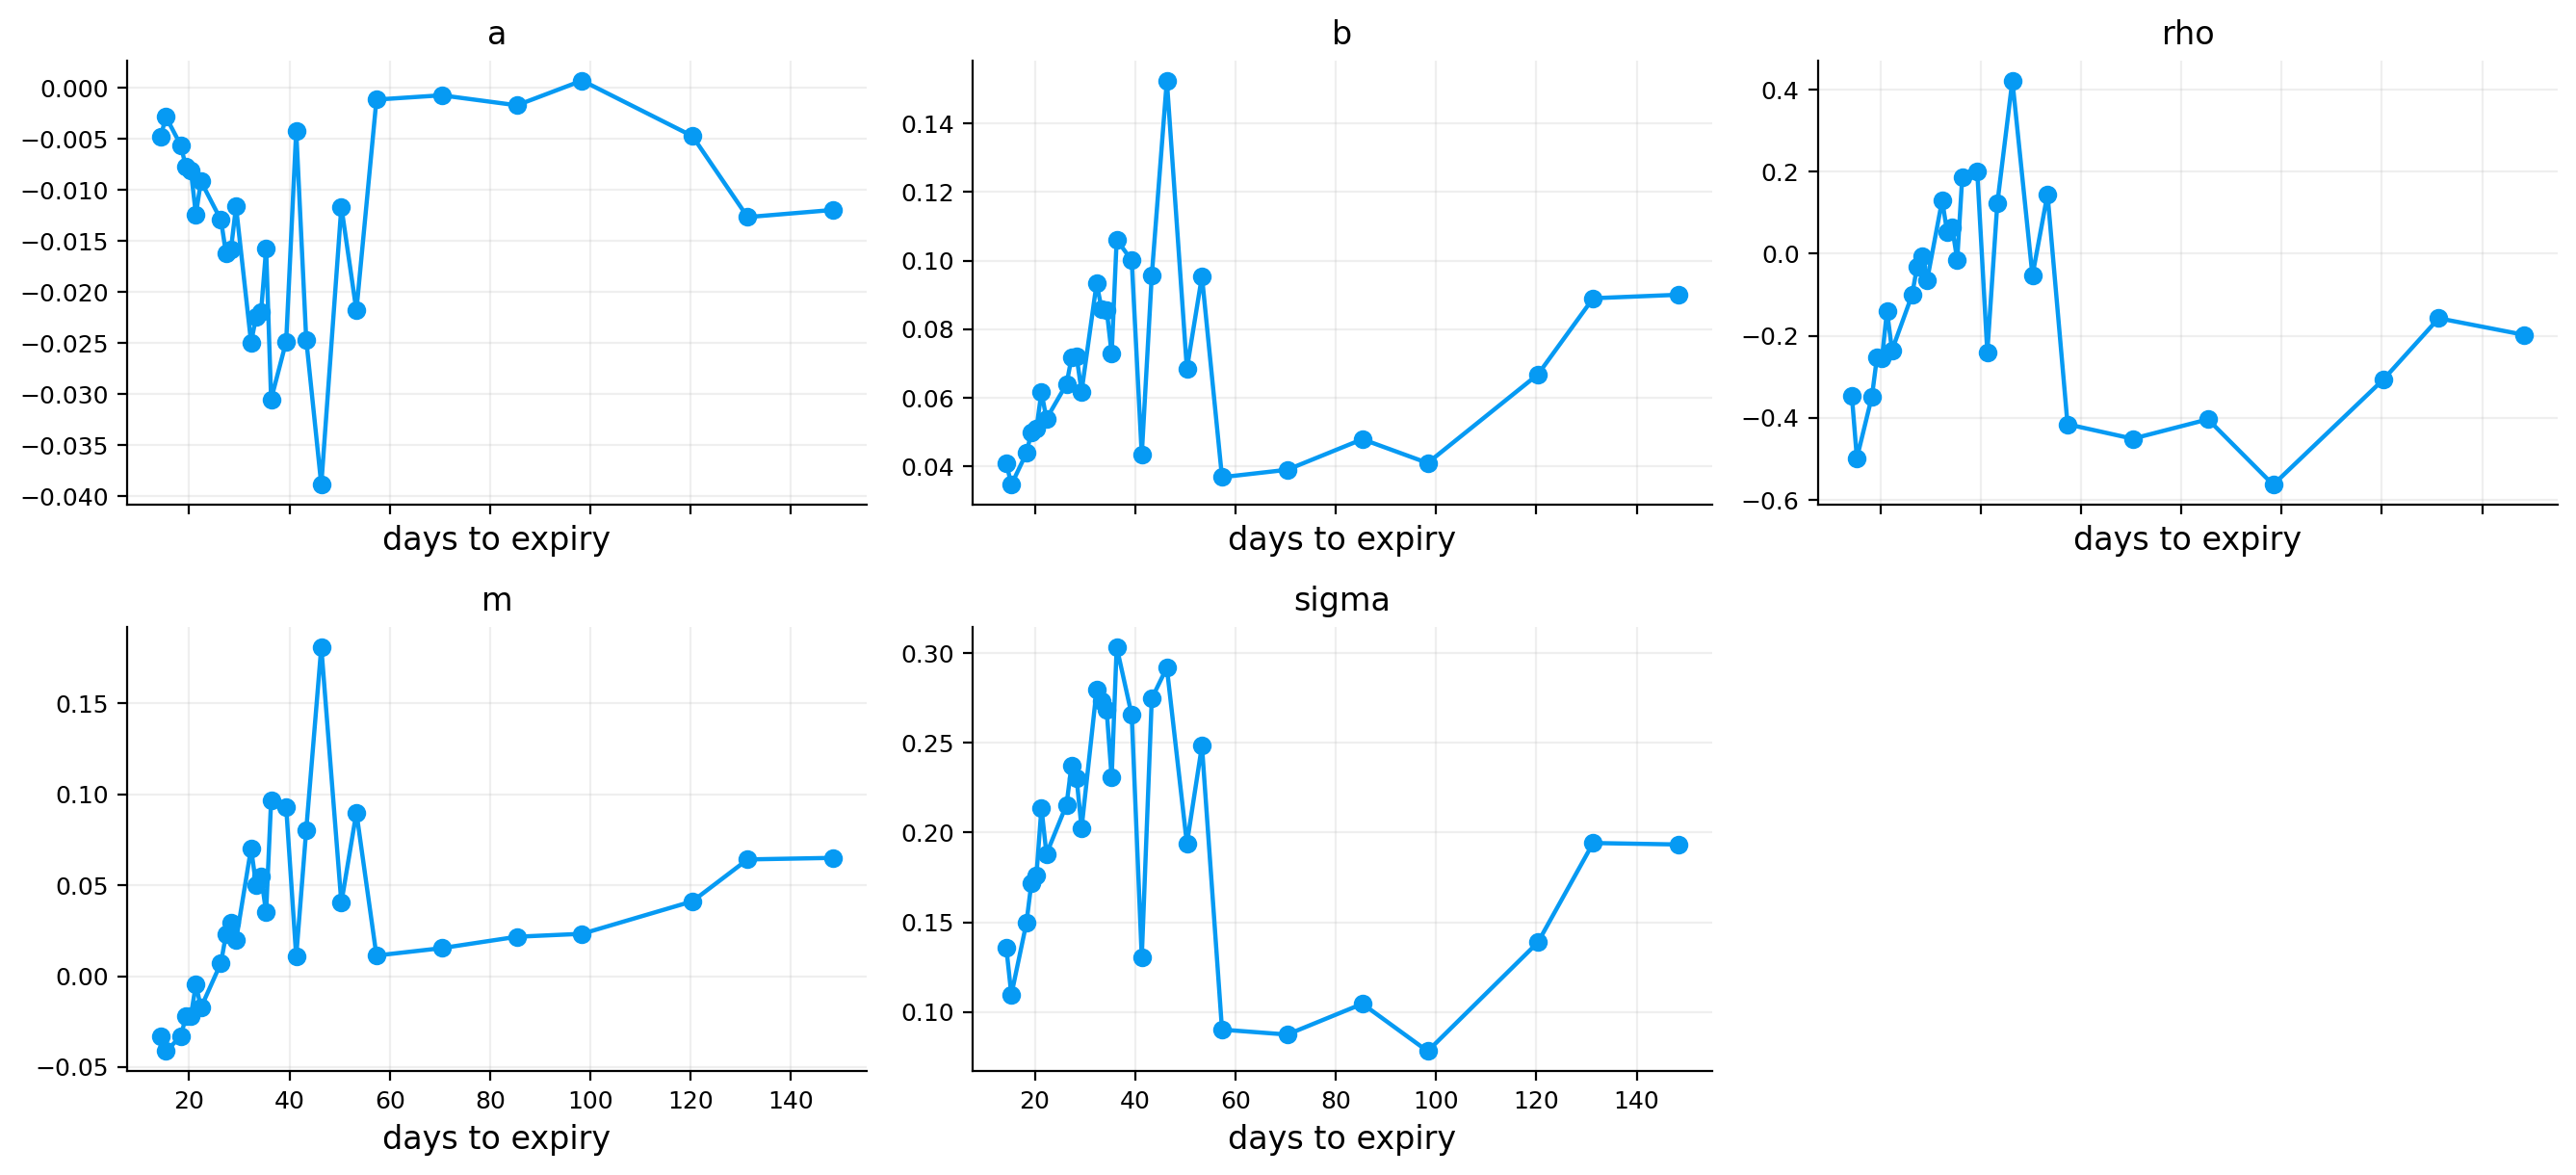

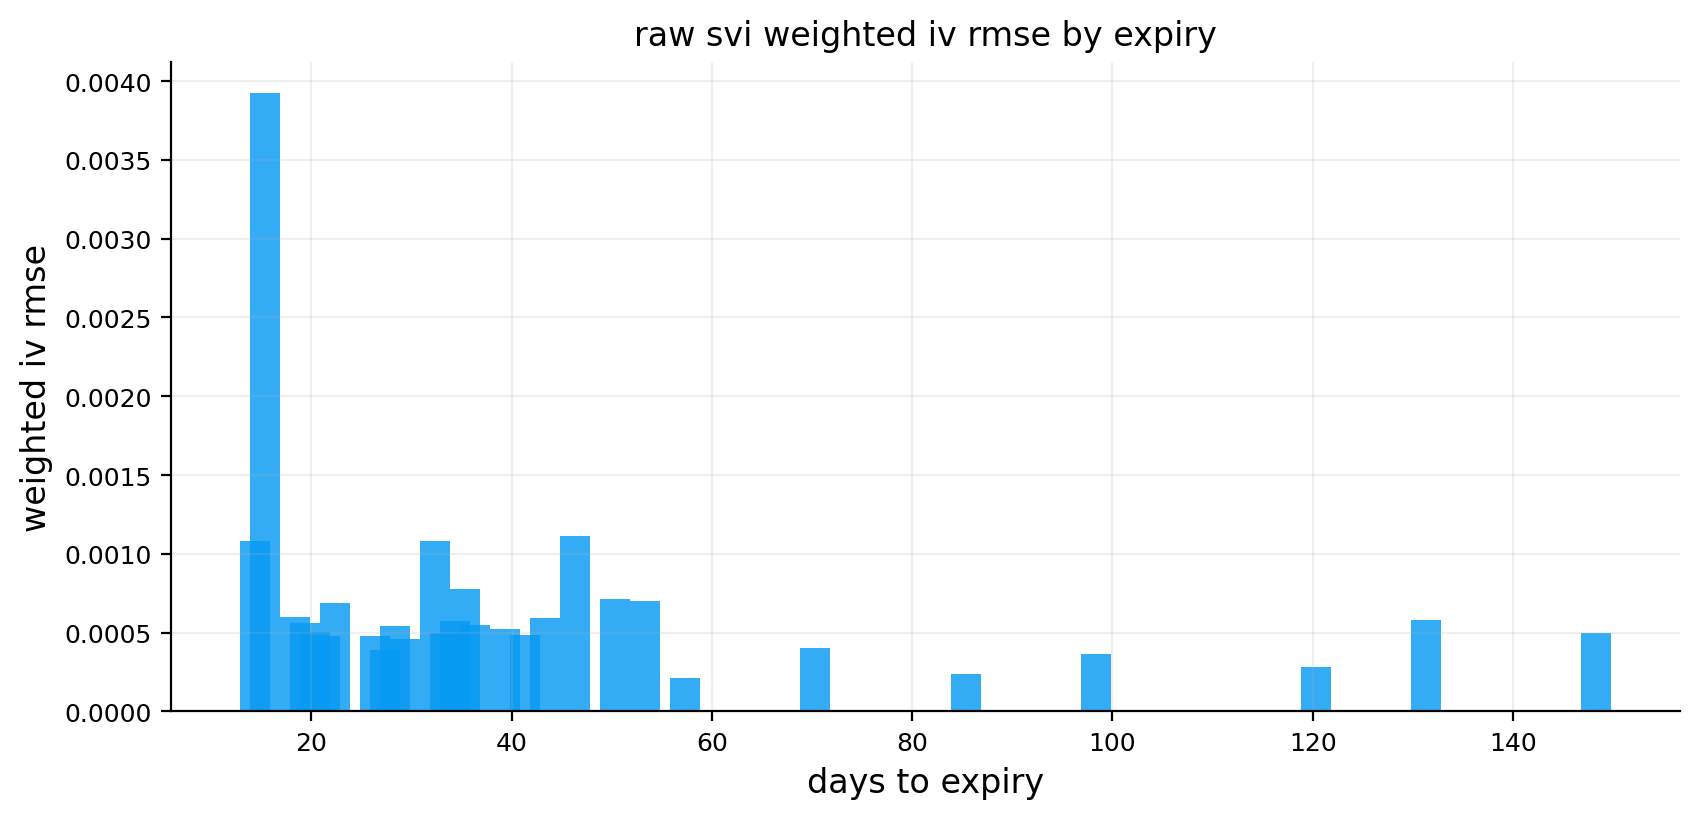

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(13.4, 6.2), sharex=True)
for ax, col in zip(axes.ravel(), ["a", "b", "rho", "m", "sigma"]):
    ax.plot(svi_params["dte_days"], svi_params[col], marker="o", lw=1.6)
    ax.set_title(col)
    ax.set_xlabel("days to expiry")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(svi_diag["dte_days"], svi_diag["weighted_rmse_iv"], width=3.0, alpha=0.82)
ax.set_title("raw svi weighted iv rmse by expiry")
ax.set_xlabel("days to expiry")
ax.set_ylabel("weighted iv rmse")
plt.tight_layout()
plt.show()

In [28]:
def theta_from_atm(q):
    rows = []
    for expiry, g in q.groupby("expiry", sort=True):
        near = g[np.abs(g["k"]) <= 0.045].copy()
        use = near if len(near) >= 3 else g.iloc[np.argsort(np.abs(g["k"].to_numpy(dtype=float)))[: min(5, len(g))]].copy()
        wt = np.maximum(use["weight"].to_numpy(dtype=float), 1e-8)
        theta = float(np.average(use["total_var"].to_numpy(dtype=float), weights=wt))
        rows.append({"expiry": expiry, "tau": float(g["tau"].median()), "dte_days": float(g["dte_days"].median()), "theta_ssvi": max(theta, 1e-8)})
    return pd.DataFrame(rows).sort_values("tau").reset_index(drop=True)


@njit
def ssvi_w(k, theta, rho, eta, gamma):
    out = np.empty(k.size, dtype=np.float64)
    for i in range(k.size):
        th = max(theta[i], 1e-12)
        phi = eta / (th ** gamma * (1.0 + th) ** (1.0 - gamma))
        x = phi * k[i]
        inside = (x + rho) * (x + rho) + 1.0 - rho * rho
        out[i] = 0.5 * th * (1.0 + rho * x + math.sqrt(max(inside, 1e-12)))
    return out


t0 = tic()
_ = ssvi_w(np.array([0.0, 0.1]), np.array([0.02, 0.03]), -0.5, 1.0, 0.5)
ssvi_compile_time = toc("compile ssvi", t0, 2)

In [29]:
def fit_ssvi(q):
    theta_curve = theta_from_atm(q)
    z = q.merge(theta_curve[["expiry", "theta_ssvi"]], on="expiry", how="left").copy()
    k = z["k"].to_numpy(dtype=float)
    theta = z["theta_ssvi"].to_numpy(dtype=float)
    y = z["total_var"].to_numpy(dtype=float)
    eps = z["eps_w"].to_numpy(dtype=float)
    eps_med = float(np.nanmedian(eps[np.isfinite(eps) & (eps > 0)])) if np.isfinite(eps).any() else 1e-4
    eps = np.clip(eps, max(1e-5, 0.25 * eps_med), 0.25)
    root_wt = np.sqrt(z["weight"].to_numpy(dtype=float))
    lo = np.array([-0.999, 0.001, 0.00])
    hi = np.array([0.999, 25.000, 1.00])

    def err(p):
        w = np.asarray(ssvi_w(k, theta, p[0], p[1], p[2]), dtype=float)
        r = root_wt * (w - y) / eps
        r = np.where((~np.isfinite(w)) | (w <= 1e-8), 1e3, r)
        return np.r_[r, max(0.0, 1e-8 - float(np.nanmin(w))) * 1e5]

    starts = [np.array([-0.55, 1.2, 0.50]), np.array([-0.75, 2.0, 0.35]), np.array([-0.35, 0.8, 0.70]), np.array([0.05, 1.0, 0.50])]
    best = None
    for p0 in starts:
        t0 = tic()
        res = optimize.least_squares(
            err,
            np.clip(p0, lo + 1e-8, hi - 1e-8),
            bounds=(lo, hi),
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=160,
            xtol=1e-8,
            ftol=1e-8,
        )
        item = {"res": res, "cost": float(res.cost), "seconds": time.perf_counter() - t0}
        if best is None or item["cost"] < best["cost"]:
            best = item
    return best["res"].x, theta_curve, best["res"].success, best["seconds"], best["res"].nfev, lo, hi

In [30]:
t0 = tic()
p_ssvi, theta_curve, ok_ssvi, seconds_ssvi, nfev_ssvi, lo_ssvi, hi_ssvi = fit_ssvi(q0)
toc("calibrate ssvi", t0, len(q0))
ssvi_params = pd.DataFrame([{"rho": p_ssvi[0], "eta": p_ssvi[1], "gamma": p_ssvi[2], "success": bool(ok_ssvi), "calibration_time": seconds_ssvi, "objective_evaluations": int(nfev_ssvi), "parameter_at_bound": near_bound(p_ssvi, lo_ssvi, hi_ssvi)}])
ssvi_fit = q0.merge(theta_curve[["expiry", "theta_ssvi"]], on="expiry", how="left").copy()
ssvi_fit["model"] = "ssvi"
ssvi_fit["model_total_var"] = ssvi_w(ssvi_fit["k"].to_numpy(dtype=float), ssvi_fit["theta_ssvi"].to_numpy(dtype=float), *p_ssvi)
ssvi_fit["model_iv"] = np.sqrt(np.maximum(ssvi_fit["model_total_var"], 1e-12) / ssvi_fit["tau"])
ssvi_fit["model_price"] = black76_price(ssvi_fit["option_type"].to_numpy(), ssvi_fit["forward"], ssvi_fit["strike"], ssvi_fit["tau"], ssvi_fit["model_iv"], ssvi_fit["discount_factor"])
ssvi_fit["iv_residual"] = ssvi_fit["model_iv"] - ssvi_fit["iv_mid"]
ssvi_fit["price_residual"] = ssvi_fit["model_price"] - ssvi_fit["mid"]
ssvi_by_expiry = ssvi_fit.groupby("expiry").apply(lambda g: pd.Series({"dte_days": float(g["dte_days"].median()), "n_quotes": int(len(g)), "weighted_rmse_iv": wrmse(g["iv_residual"], g["weight"]), "median_abs_iv_error": float(np.nanmedian(np.abs(g["iv_residual"])))})).reset_index()
ssvi_diag = pd.DataFrame([{
    "success": bool(ok_ssvi),
    "n_quotes": int(len(ssvi_fit)),
    "weighted_rmse_total_var": wrmse(ssvi_fit["model_total_var"] - ssvi_fit["total_var"], ssvi_fit["weight"]),
    "weighted_rmse_iv": wrmse(ssvi_fit["iv_residual"], ssvi_fit["weight"]),
    "median_abs_iv_error": float(np.nanmedian(np.abs(ssvi_fit["iv_residual"]))),
    "p90_abs_iv_error": float(np.nanquantile(np.abs(ssvi_fit["iv_residual"]), 0.90)),
    "smoothness_score": float(np.nanstd(np.diff(theta_curve["theta_ssvi"], n=2))) if len(theta_curve) >= 3 else np.nan,
    "calibration_time": float(seconds_ssvi),
    "objective_evaluations": int(nfev_ssvi),
    "parameter_at_bound": bool(ssvi_params.loc[0, "parameter_at_bound"]),
}])
display(ssvi_params)
display(ssvi_diag)

,rho,eta,gamma,success,calibration_time,objective_evaluations,parameter_at_bound
0,-0.497158,2.980003,0.309909,True,0.056061,9,False


,success,n_quotes,weighted_rmse_total_var,weighted_rmse_iv,median_abs_iv_error,p90_abs_iv_error,smoothness_score,calibration_time,objective_evaluations,parameter_at_bound
0,True,3873,0.000383,0.008318,0.003846,0.016519,0.000249,0.056061,9,False


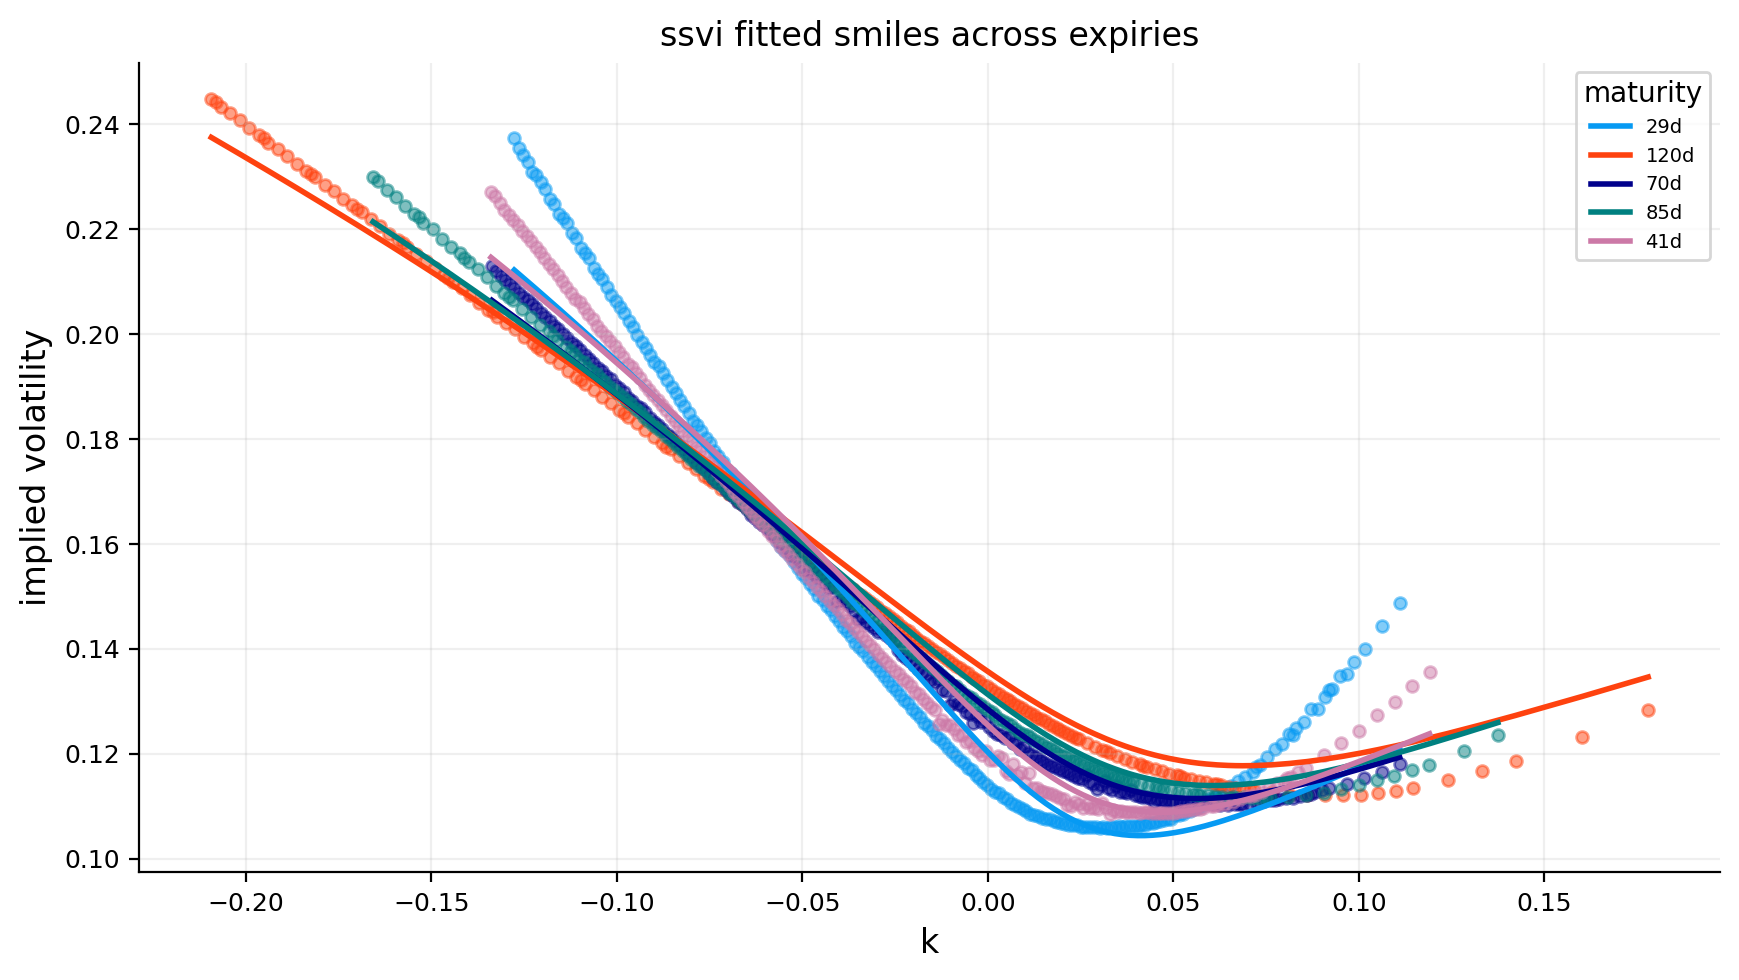

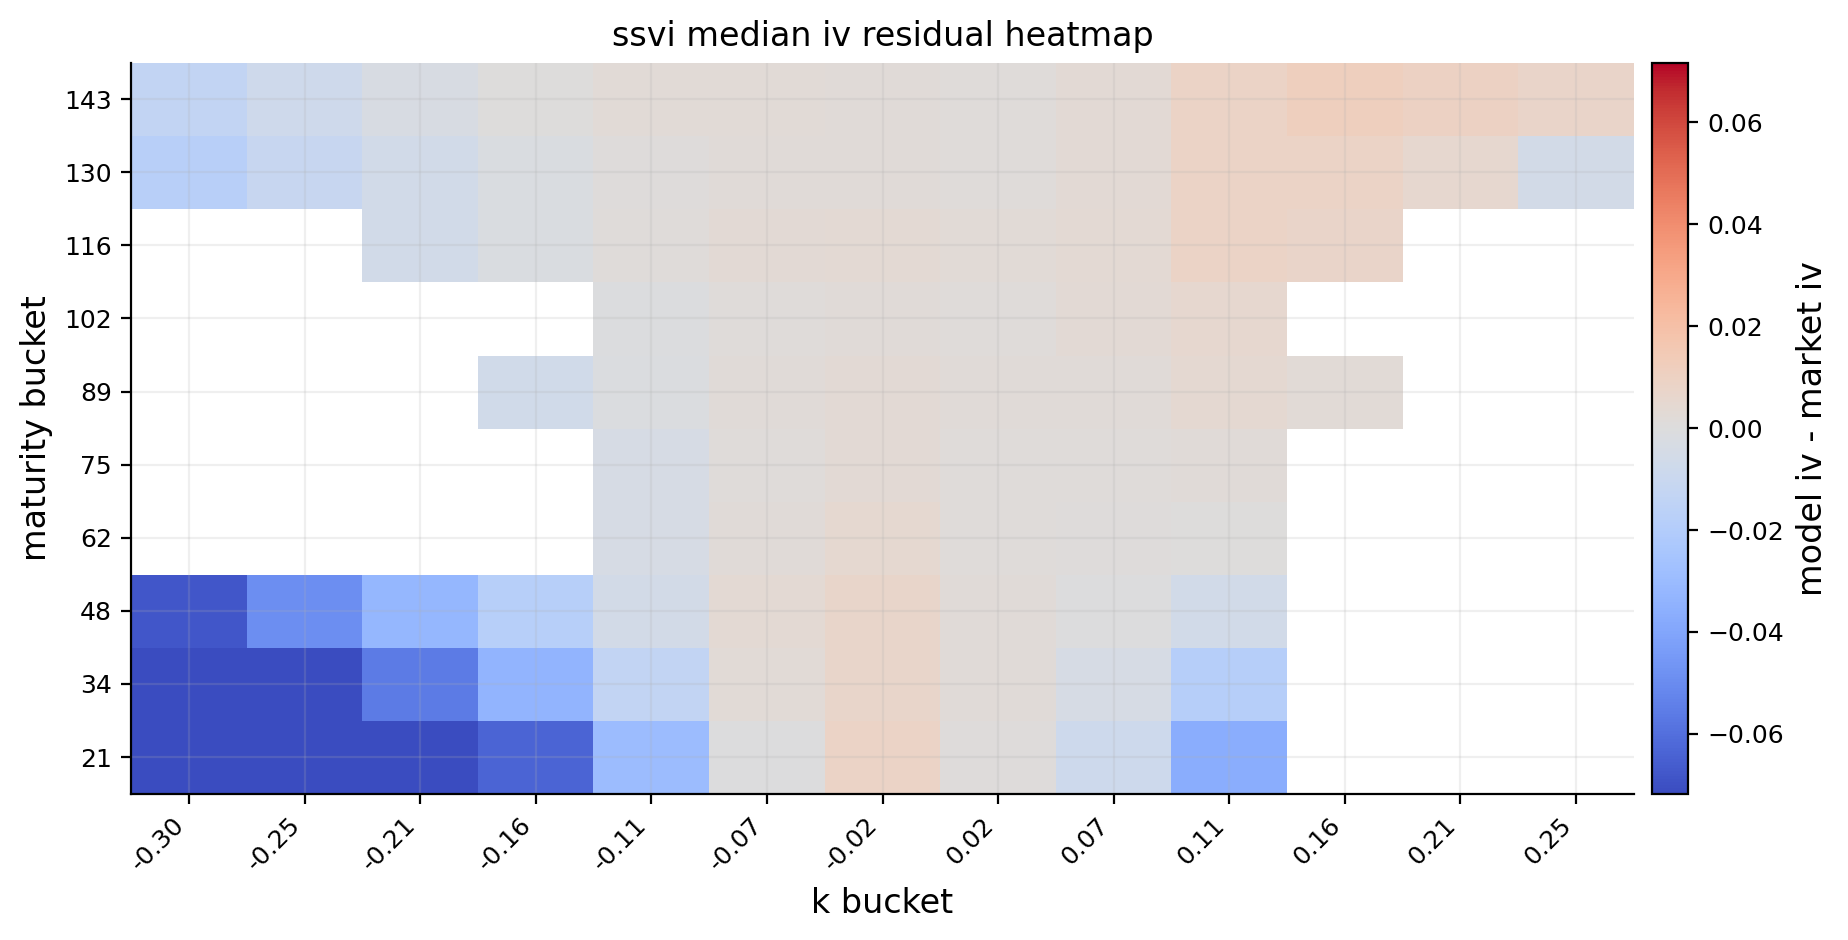

In [31]:
fig, ax = plt.subplots(figsize=(8.8, 5.0))
for expiry in selected_expiries:
    g = ssvi_fit[ssvi_fit["expiry"].eq(expiry)].sort_values("k")
    if g.empty:
        continue
    ax.scatter(g["k"], g["iv_mid"], s=18, alpha=0.50)
    ax.plot(g["k"], g["model_iv"], lw=2.0, label=f"{g['dte_days'].median():.0f}d")
ax.set_title("ssvi fitted smiles across expiries")
ax.set_xlabel("k")
ax.set_ylabel("implied volatility")
ax.legend(title="maturity")
plt.tight_layout()
plt.show()

z = ssvi_fit.copy()
z["k_bin"] = pd.cut(z["k"], np.linspace(-max_abs_k, max_abs_k, 15))
z["dte_bin"] = pd.cut(z["dte_days"], np.linspace(min_dte, max_dte, 11))
h = z.pivot_table(index="dte_bin", columns="k_bin", values="iv_residual", aggfunc="median", observed=False)
lim = float(np.nanquantile(np.abs(h.to_numpy(dtype=float)), 0.95)) if np.isfinite(h.to_numpy(dtype=float)).any() else 0.02
fig, ax = plt.subplots(figsize=(9.8, 4.8))
im = ax.imshow(h.to_numpy(dtype=float), aspect="auto", origin="lower", cmap="coolwarm", vmin=-lim, vmax=lim)
ax.set_title("ssvi median iv residual heatmap")
ax.set_xlabel("k bucket")
ax.set_ylabel("maturity bucket")
ax.set_xticks(np.arange(h.shape[1]))
ax.set_xticklabels([f"{b.mid:.2f}" for b in h.columns], rotation=45, ha="right")
ax.set_yticks(np.arange(h.shape[0]))
ax.set_yticklabels([f"{b.mid:.0f}" for b in h.index])
fig.colorbar(im, ax=ax, pad=0.01, label="model iv - market iv")
plt.tight_layout()
plt.show()

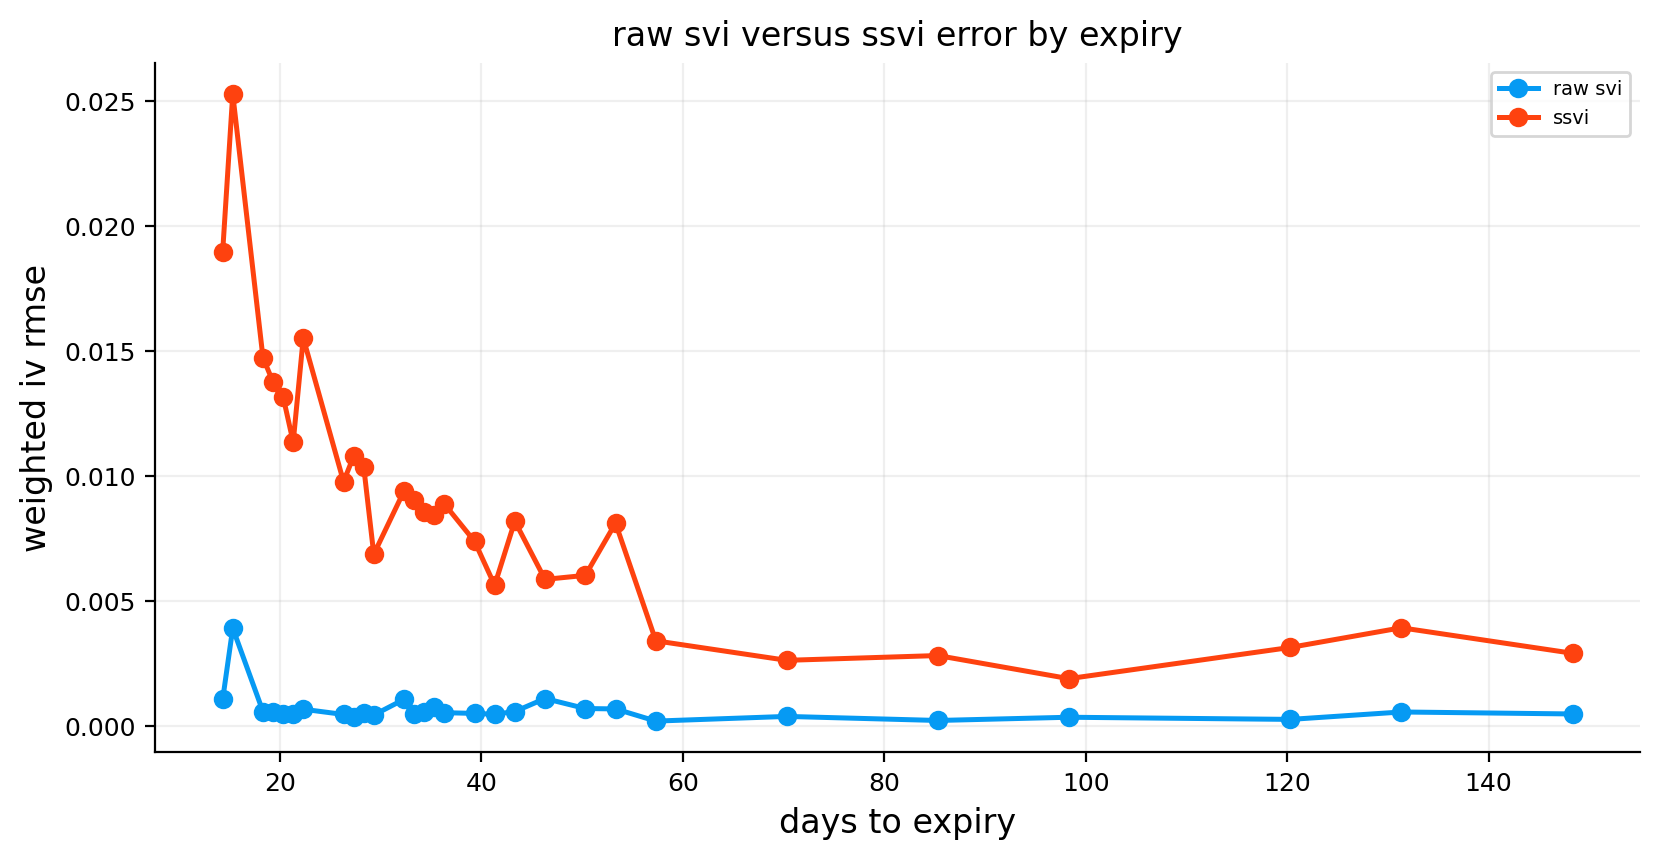

In [32]:
svi_ssvi = svi_diag[["expiry", "dte_days", "weighted_rmse_iv"]].rename(columns={"weighted_rmse_iv": "svi"}).merge(ssvi_by_expiry[["expiry", "weighted_rmse_iv"]].rename(columns={"weighted_rmse_iv": "ssvi"}), on="expiry", how="inner")
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.plot(svi_ssvi["dte_days"], svi_ssvi["svi"], marker="o", lw=1.8, label="raw svi")
ax.plot(svi_ssvi["dte_days"], svi_ssvi["ssvi"], marker="o", lw=1.8, label="ssvi")
ax.set_title("raw svi versus ssvi error by expiry")
ax.set_xlabel("days to expiry")
ax.set_ylabel("weighted iv rmse")
ax.legend()
plt.tight_layout()
plt.show()

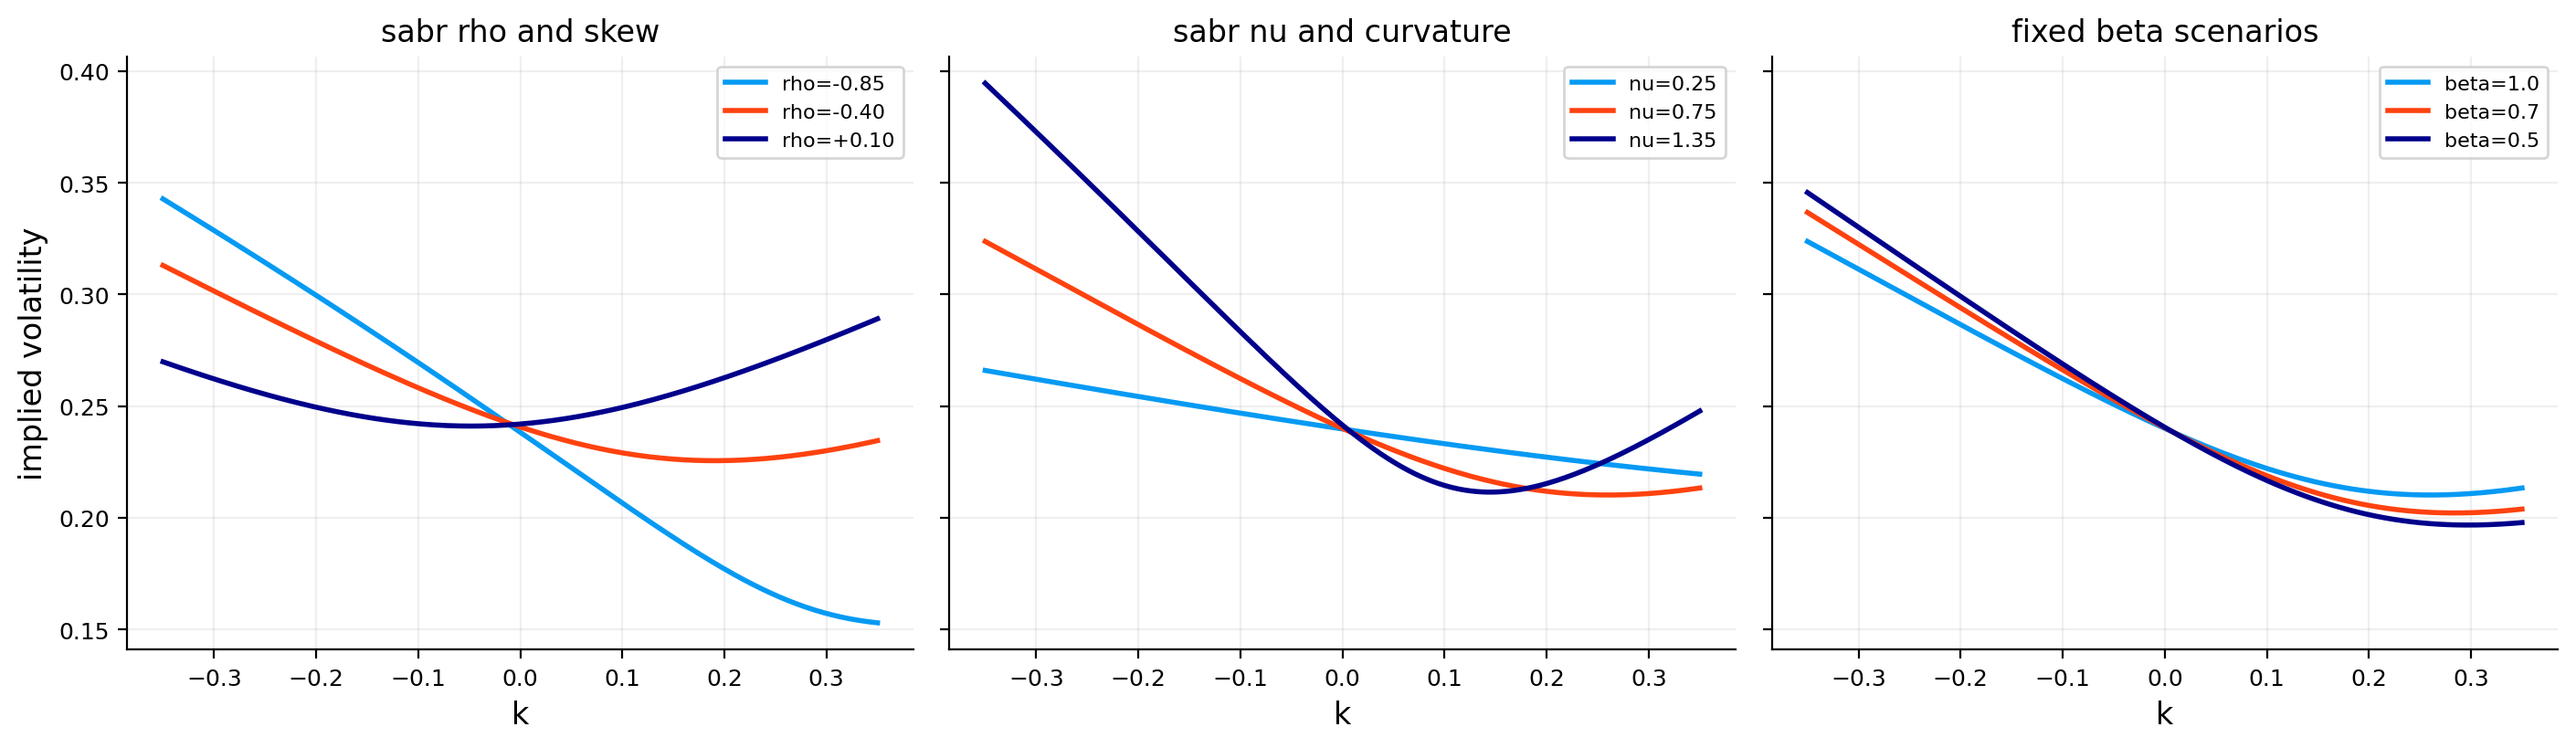

In [33]:
def sabr_iv_demo(f, k_strike, tau, alpha, beta, rho, nu):
    k_strike = np.asarray(k_strike, dtype=float)
    log_fk = np.log(np.clip(f / k_strike, 1e-12, None))
    fk_beta = (f * k_strike) ** ((1.0 - beta) / 2.0)
    z = (nu / max(alpha, 1e-12)) * fk_beta * log_fk
    xz = np.log((np.sqrt(1.0 - 2.0 * rho * z + z * z) + z - rho) / (1.0 - rho))
    z_xz = np.where(np.abs(z) < 1e-8, 1.0, z / xz)
    log_adj = 1.0 + ((1.0 - beta) ** 2 / 24.0) * log_fk ** 2 + ((1.0 - beta) ** 4 / 1920.0) * log_fk ** 4
    term = ((1.0 - beta) ** 2 / 24.0) * alpha ** 2 / np.maximum(fk_beta ** 2, 1e-12)
    term += 0.25 * rho * beta * nu * alpha / np.maximum(fk_beta, 1e-12)
    term += (2.0 - 3.0 * rho * rho) * nu * nu / 24.0
    return np.maximum(alpha / np.maximum(fk_beta * log_adj, 1e-12) * z_xz * (1.0 + term * tau), 1e-5)


f_demo = 100.0
strike_demo = f_demo * np.exp(k_line)
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.2), sharey=True)
for rho_value in [-0.85, -0.40, 0.10]:
    axes[0].plot(k_line, sabr_iv_demo(f_demo, strike_demo, tau_demo, 0.24, 1.0, rho_value, 0.75), lw=2.0, label=f"rho={rho_value:+.2f}")
for nu_value in [0.25, 0.75, 1.35]:
    axes[1].plot(k_line, sabr_iv_demo(f_demo, strike_demo, tau_demo, 0.24, 1.0, -0.55, nu_value), lw=2.0, label=f"nu={nu_value:.2f}")
for beta_value in [1.0, 0.7, 0.5]:
    axes[2].plot(k_line, sabr_iv_demo(f_demo, strike_demo, tau_demo, 0.24 * f_demo ** (1.0 - beta_value), beta_value, -0.55, 0.75), lw=2.0, label=f"beta={beta_value:.1f}")
axes[0].set_title("sabr rho and skew")
axes[1].set_title("sabr nu and curvature")
axes[2].set_title("fixed beta scenarios")
for ax in axes:
    ax.set_xlabel("k")
    ax.legend(fontsize=8)
axes[0].set_ylabel("implied volatility")
plt.tight_layout()
plt.show()

In [34]:
@njit
def sabr_iv_hagan(fwd, strike, tau, alpha, beta, rho, nu):
    n = strike.size
    out = np.empty(n, dtype=np.float64)
    for i in range(n):
        f = max(fwd[i], 1e-12)
        k = max(strike[i], 1e-12)
        t = max(tau[i], 1e-12)
        a = max(alpha, 1e-12)
        b = beta
        r = min(max(rho, -0.999999), 0.999999)
        v = max(nu, 1e-12)
        log_fk = math.log(f / k)
        if abs(log_fk) < 1e-7:
            f_beta = f ** (1.0 - b)
            term = ((1.0 - b) ** 2 / 24.0) * a * a / max(f_beta * f_beta, 1e-12)
            term += 0.25 * r * b * v * a / max(f_beta, 1e-12)
            term += (2.0 - 3.0 * r * r) * v * v / 24.0
            out[i] = max(a / max(f_beta, 1e-12) * (1.0 + term * t), 1e-8)
        else:
            fk_beta = (f * k) ** ((1.0 - b) / 2.0)
            z = (v / a) * fk_beta * log_fk
            root = math.sqrt(max(1.0 - 2.0 * r * z + z * z, 1e-12))
            xz = math.log(max((root + z - r) / (1.0 - r), 1e-12))
            z_xz = 1.0 if abs(z) < 1e-8 or abs(xz) < 1e-10 else z / xz
            log_adj = 1.0 + ((1.0 - b) ** 2 / 24.0) * log_fk * log_fk + ((1.0 - b) ** 4 / 1920.0) * log_fk ** 4
            term = ((1.0 - b) ** 2 / 24.0) * a * a / max(fk_beta * fk_beta, 1e-12)
            term += 0.25 * r * b * v * a / max(fk_beta, 1e-12)
            term += (2.0 - 3.0 * r * r) * v * v / 24.0
            out[i] = max((a / max(fk_beta * log_adj, 1e-12)) * z_xz * (1.0 + term * t), 1e-8)
    return out


t0 = tic()
_ = sabr_iv_hagan(np.array([100.0, 100.0]), np.array([95.0, 105.0]), np.array([0.2, 0.2]), 0.22, 1.0, -0.5, 0.8)
sabr_compile_time = toc("compile sabr", t0, 2)

In [35]:
def fit_sabr_slice(q, beta):
    z = q.sort_values("strike").copy()
    f = z["forward"].to_numpy(dtype=float)
    k_strike = z["strike"].to_numpy(dtype=float)
    tau = z["tau"].to_numpy(dtype=float)
    y = z["iv_mid"].to_numpy(dtype=float)
    eps = z["eps_iv"].to_numpy(dtype=float)
    eps_med = float(np.nanmedian(eps[np.isfinite(eps) & (eps > 0)])) if np.isfinite(eps).any() else 0.02
    eps = np.clip(eps, max(0.003, 0.25 * eps_med), 0.50)
    root_wt = np.sqrt(z["weight"].to_numpy(dtype=float))
    i0 = int(np.nanargmin(np.abs(z["k"].to_numpy(dtype=float))))
    atm_iv = float(y[i0])
    f_med = float(np.nanmedian(f))
    alpha0 = max(atm_iv * f_med ** (1.0 - beta), 1e-4)
    lo = np.array([1e-5, -0.999, 1e-4])
    hi = np.array([max(1.0, 8.0 * alpha0), 0.999, 6.0])

    def err(p):
        iv = np.asarray(sabr_iv_hagan(f, k_strike, tau, p[0], beta, p[1], p[2]), dtype=float)
        r = root_wt * (iv - y) / eps
        return np.where(np.isfinite(r), r, 1e3)

    starts = [np.array([alpha0, -0.55, 0.65]), np.array([0.80 * alpha0, -0.80, 1.20]), np.array([1.25 * alpha0, -0.25, 0.35]), np.array([alpha0, 0.05, 0.80])]
    best = None
    for p0 in starts:
        t0 = tic()
        res = optimize.least_squares(
            err,
            np.clip(p0, lo + 1e-8, hi - 1e-8),
            bounds=(lo, hi),
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=160,
            xtol=1e-8,
            ftol=1e-8,
        )
        item = {"res": res, "cost": float(res.cost), "seconds": time.perf_counter() - t0}
        if best is None or item["cost"] < best["cost"]:
            best = item
    return best["res"].x, best["res"].success, best["seconds"], best["res"].nfev, lo, hi


def fit_sabr(q, beta):
    p_rows = []
    f_rows = []
    d_rows = []
    for expiry, g in q.groupby("expiry", sort=True):
        if len(g) < min_quotes_per_expiry:
            continue
        p, ok, seconds, nfev, lo, hi = fit_sabr_slice(g, beta)
        iv_hat = sabr_iv_hagan(g["forward"].to_numpy(dtype=float), g["strike"].to_numpy(dtype=float), g["tau"].to_numpy(dtype=float), p[0], beta, p[1], p[2])
        px_hat = black76_price(g["option_type"].to_numpy(), g["forward"], g["strike"], g["tau"], iv_hat, g["discount_factor"])
        e_iv = iv_hat - g["iv_mid"].to_numpy(dtype=float)
        wt = g["weight"].to_numpy(dtype=float)
        d_rows.append({"beta": float(beta), "expiry": expiry, "dte_days": float(g["dte_days"].median()), "success": bool(ok), "n_quotes": int(len(g)), "weighted_rmse_iv": wrmse(e_iv, wt), "median_abs_iv_error": float(np.nanmedian(np.abs(e_iv))), "p90_abs_iv_error": float(np.nanquantile(np.abs(e_iv), 0.90)), "rho_bound_flag": bool(abs(p[1]) > 0.985), "nu_bound_flag": bool((p[2] - lo[2]) / (hi[2] - lo[2]) < 0.005 or (hi[2] - p[2]) / (hi[2] - lo[2]) < 0.005), "calibration_time": float(seconds), "objective_evaluations": int(nfev)})
        p_rows.append({"beta": float(beta), "expiry": expiry, "dte_days": float(g["dte_days"].median()), "alpha": p[0], "rho": p[1], "nu": p[2], "success": bool(ok)})
        z = g.copy()
        z["model"] = "sabr"
        z["beta"] = float(beta)
        z["model_iv"] = iv_hat
        z["model_price"] = np.asarray(px_hat, dtype=float)
        z["iv_residual"] = z["model_iv"] - z["iv_mid"]
        z["price_residual"] = z["model_price"] - z["mid"]
        f_rows.append(z)
    if not f_rows:
        return pd.DataFrame(p_rows), q.head(0).copy(), pd.DataFrame(d_rows)
    return pd.DataFrame(p_rows), pd.concat(f_rows, ignore_index=True), pd.DataFrame(d_rows)

In [36]:
t0 = tic()
sabr_runs = []
for beta in [1.0, 0.7, 0.5]:
    sabr_runs.append(fit_sabr(q0, beta))
sabr_params = pd.concat([x[0] for x in sabr_runs], ignore_index=True)
sabr_fit = pd.concat([x[1] for x in sabr_runs], ignore_index=True)
sabr_diag = pd.concat([x[2] for x in sabr_runs], ignore_index=True)
toc("calibrate sabr beta scenarios", t0, len(sabr_fit))
sabr_beta_compare = sabr_diag.groupby("beta").agg(
    success_rate=("success", "mean"),
    median_weighted_iv_rmse=("weighted_rmse_iv", "median"),
    median_abs_iv_error=("median_abs_iv_error", "median"),
    rho_bound_share=("rho_bound_flag", "mean"),
    nu_bound_share=("nu_bound_flag", "mean"),
    calibration_time=("calibration_time", "sum"),
).reset_index()
best_beta = float(sabr_beta_compare.sort_values(["median_weighted_iv_rmse", "rho_bound_share", "nu_bound_share"]).iloc[0]["beta"])
rmse_best = float(sabr_beta_compare["median_weighted_iv_rmse"].min())
rmse_beta_one = float(sabr_beta_compare.loc[sabr_beta_compare["beta"].eq(1.0), "median_weighted_iv_rmse"].iloc[0])
primary_beta = 1.0 if rmse_beta_one <= 1.08 * rmse_best else best_beta
sabr_fit_main = sabr_fit[sabr_fit["beta"].eq(primary_beta)].copy()
sabr_params_main = sabr_params[sabr_params["beta"].eq(primary_beta)].copy()
display(sabr_beta_compare)
print(f"primary_beta: {primary_beta:.1f}")

,beta,success_rate,median_weighted_iv_rmse,median_abs_iv_error,rho_bound_share,nu_bound_share,calibration_time
0,0.500000,1.000000,0.002032,0.001344,0.000000,0.000000,0.468387
1,0.700000,1.000000,0.002160,0.001381,0.000000,0.000000,0.450547
2,1.000000,1.000000,0.002356,0.001437,0.000000,0.000000,0.873524


primary_beta: 0.5


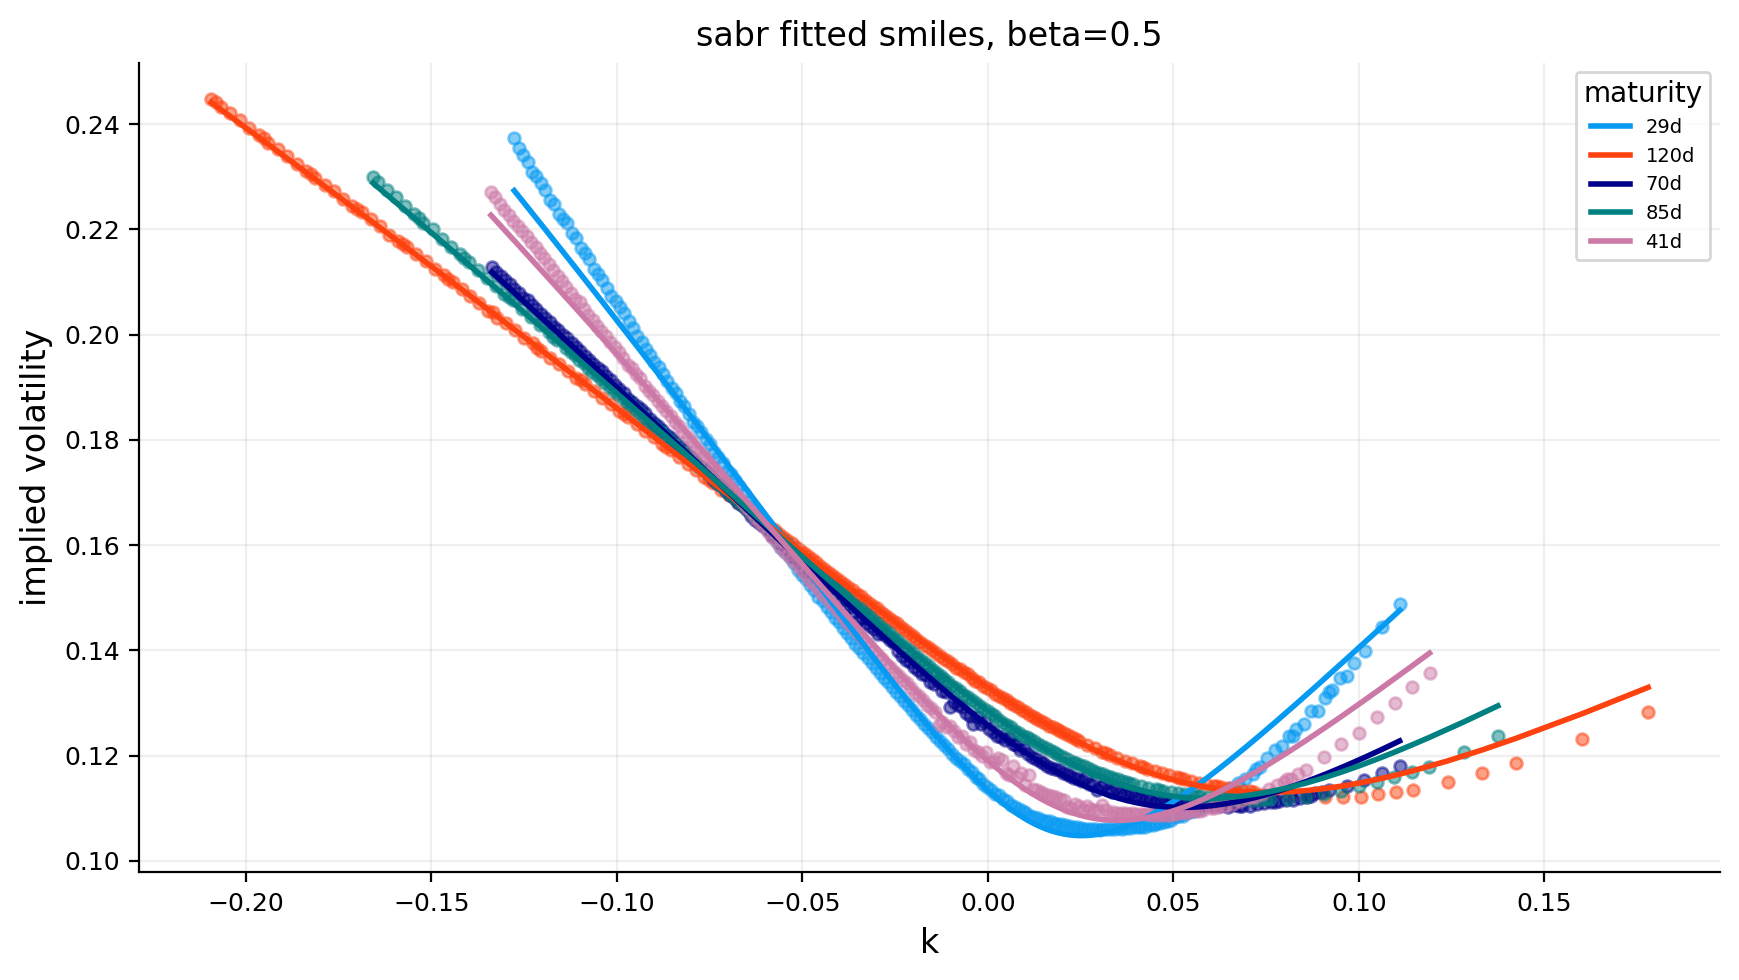

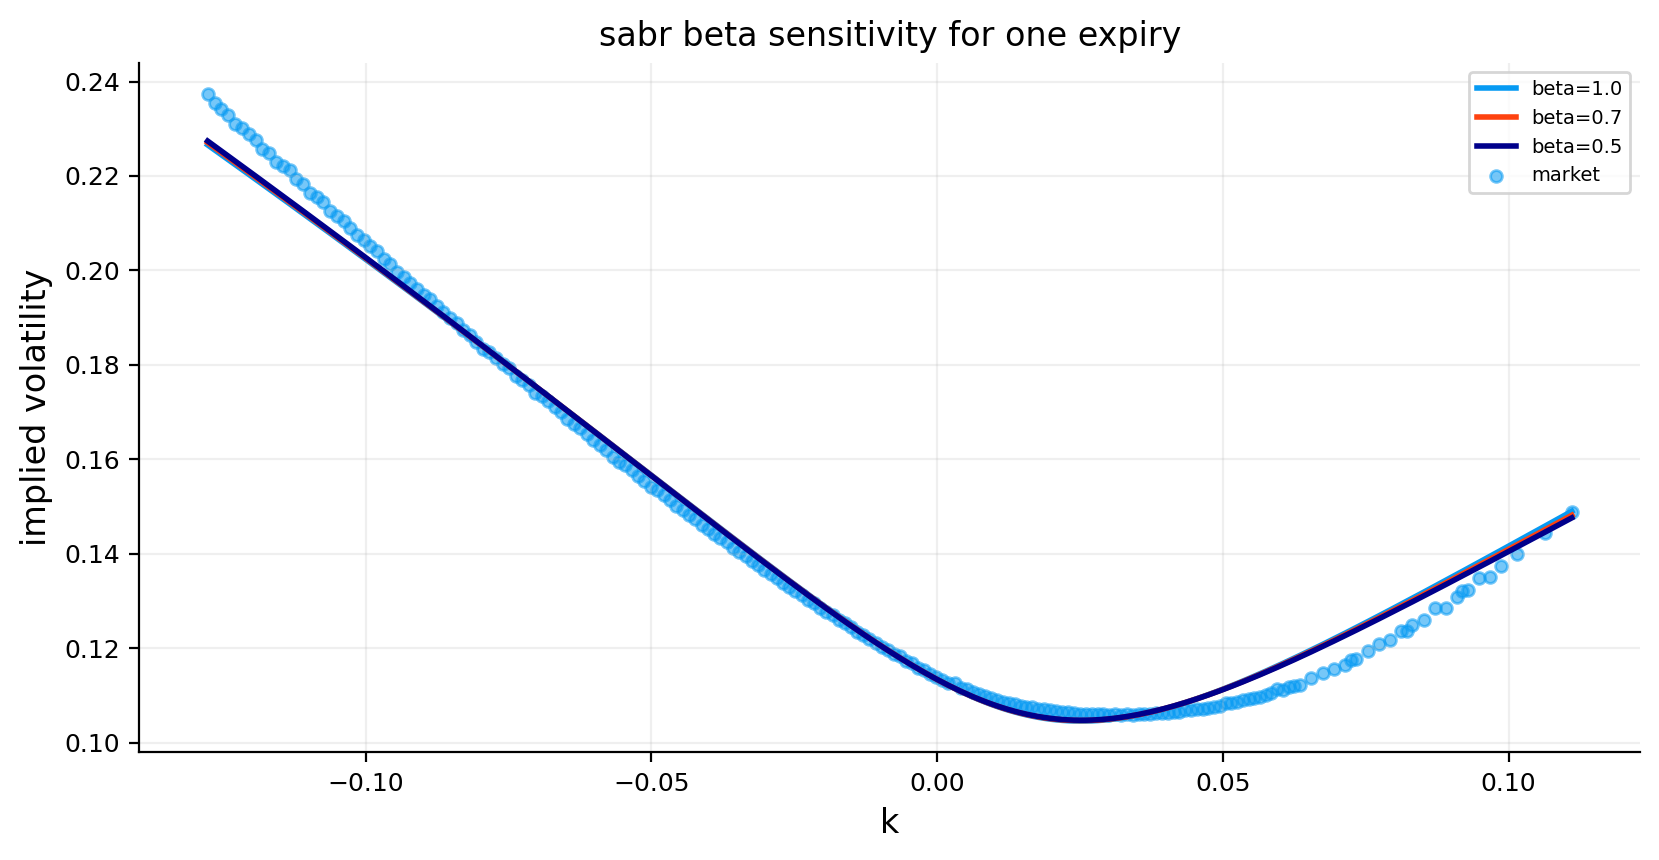

In [37]:
fig, ax = plt.subplots(figsize=(8.8, 5.0))
for expiry in selected_expiries:
    g = sabr_fit_main[sabr_fit_main["expiry"].eq(expiry)].sort_values("k")
    if g.empty:
        continue
    ax.scatter(g["k"], g["iv_mid"], s=18, alpha=0.50)
    ax.plot(g["k"], g["model_iv"], lw=2.0, label=f"{g['dte_days'].median():.0f}d")
ax.set_title(f"sabr fitted smiles, beta={primary_beta:.1f}")
ax.set_xlabel("k")
ax.set_ylabel("implied volatility")
ax.legend(title="maturity")
plt.tight_layout()
plt.show()

rep_expiry = selected_expiries[0]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
for beta in [1.0, 0.7, 0.5]:
    g = sabr_fit[(sabr_fit["expiry"].eq(rep_expiry)) & (sabr_fit["beta"].eq(beta))].sort_values("k")
    ax.plot(g["k"], g["model_iv"], lw=2.0, label=f"beta={beta:.1f}")
market = q0[q0["expiry"].eq(rep_expiry)].sort_values("k")
ax.scatter(market["k"], market["iv_mid"], s=18, alpha=0.55, label="market")
ax.set_title("sabr beta sensitivity for one expiry")
ax.set_xlabel("k")
ax.set_ylabel("implied volatility")
ax.legend()
plt.tight_layout()
plt.show()

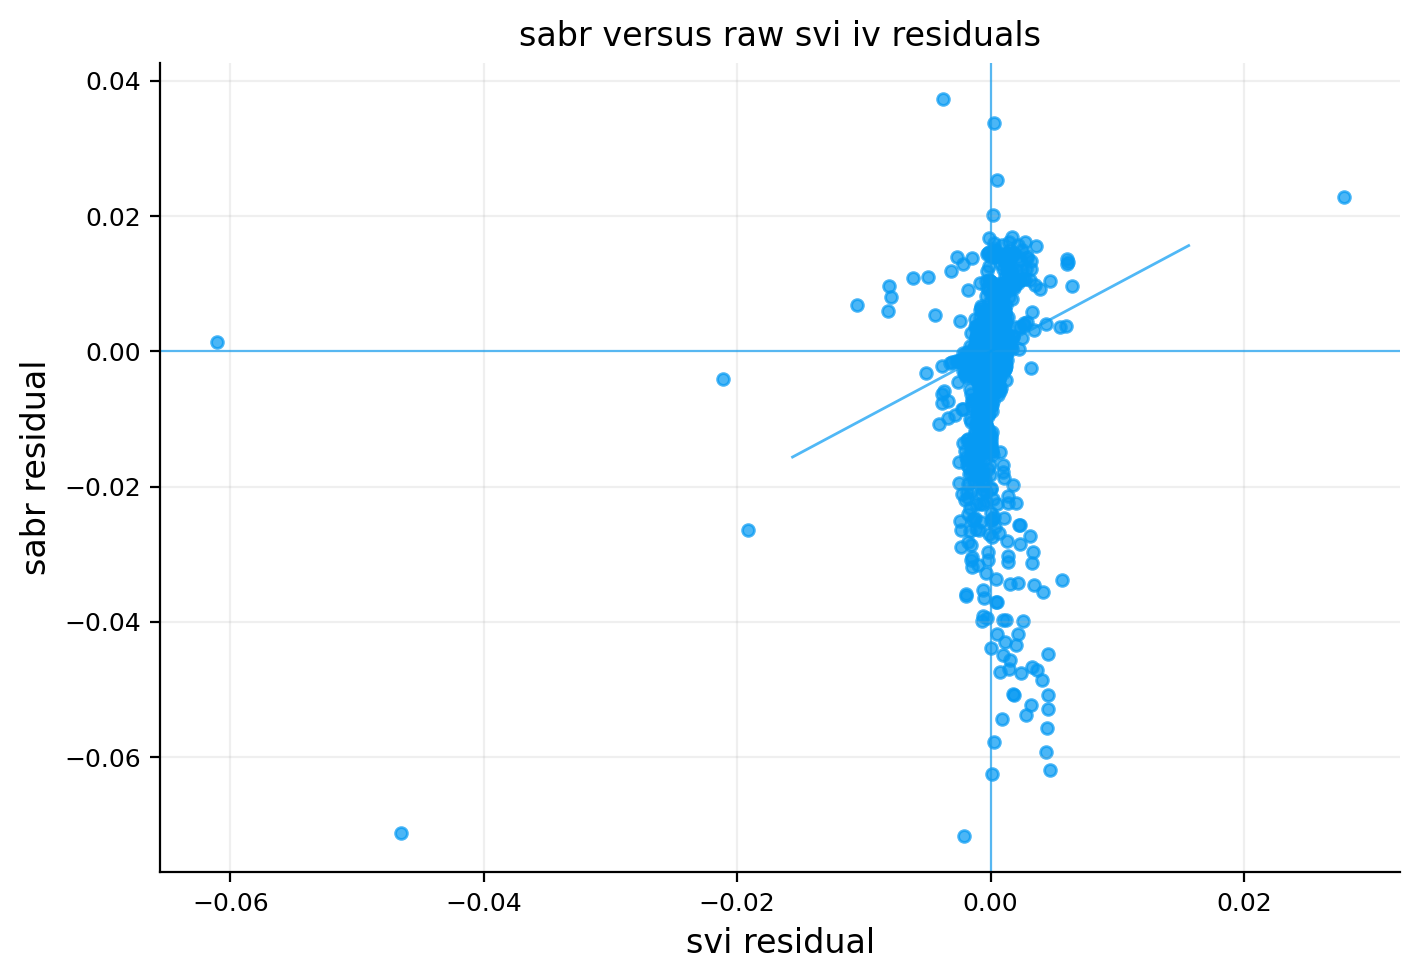

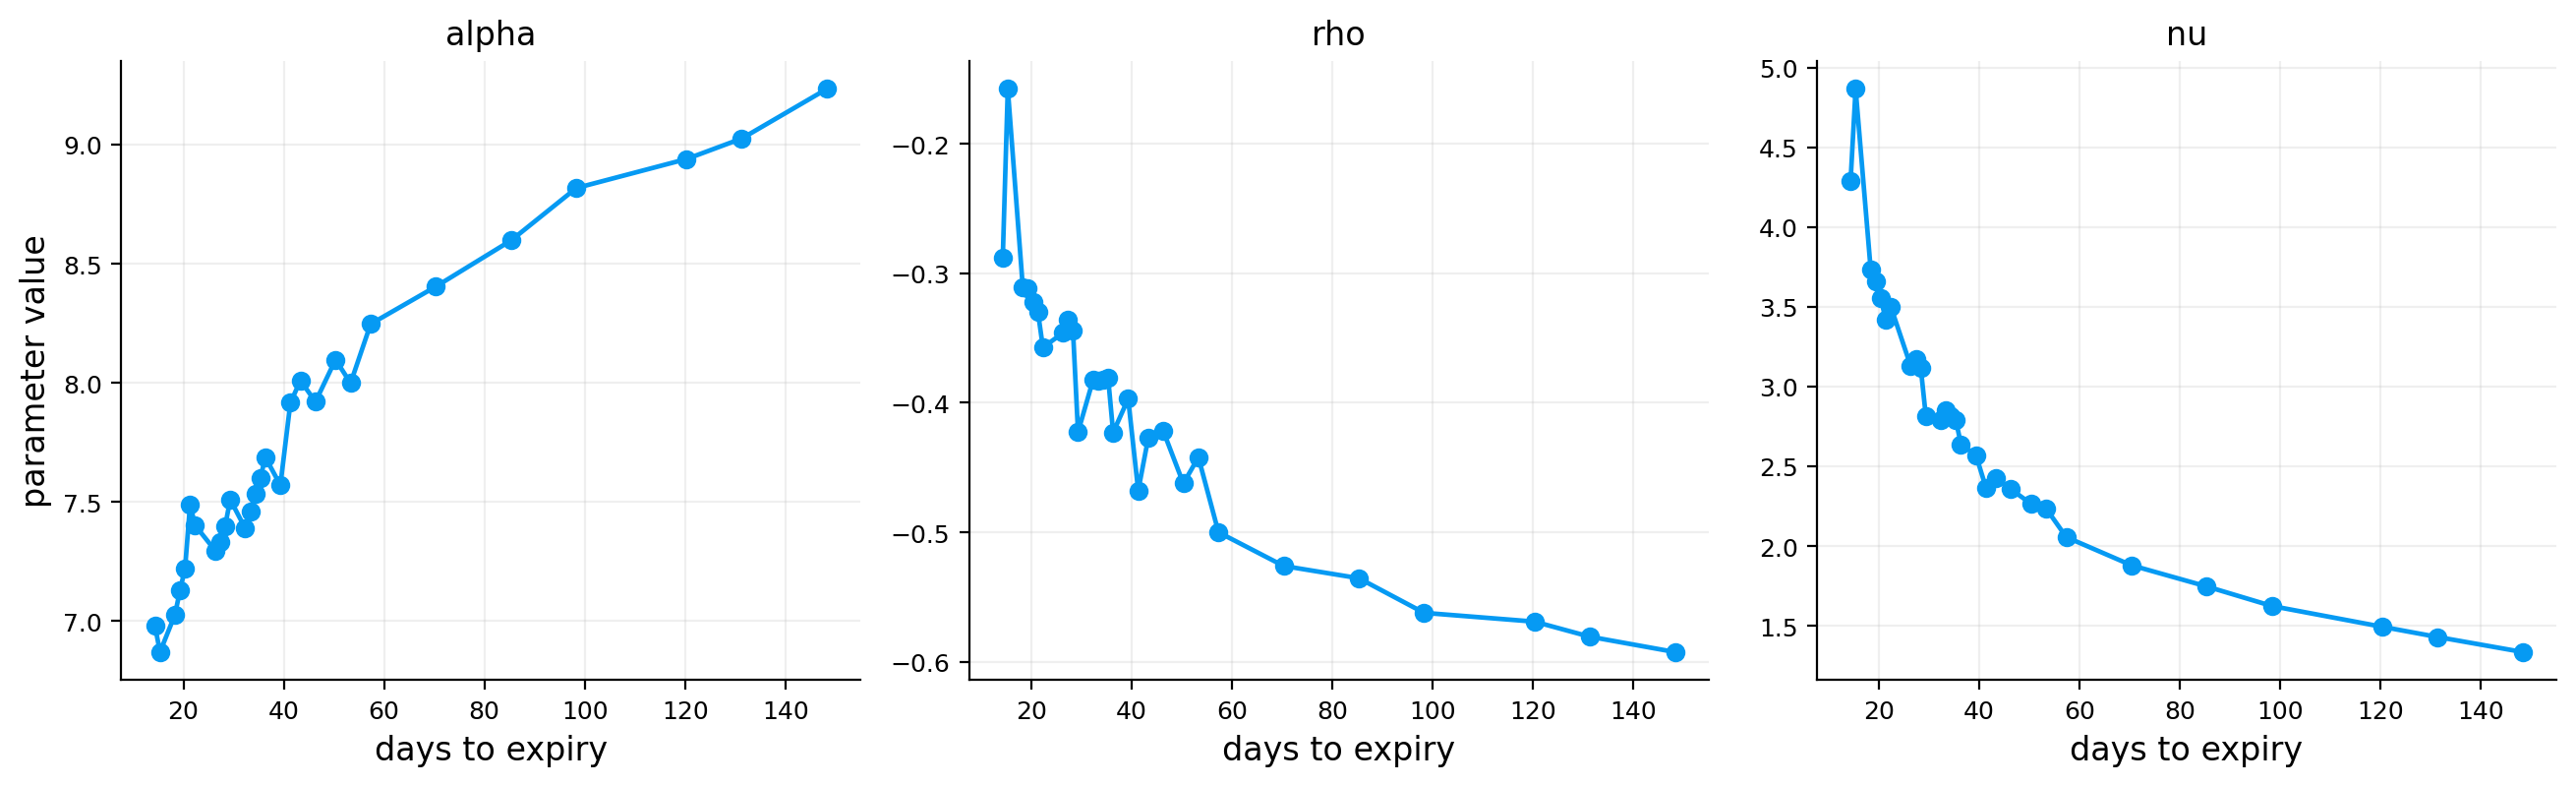

In [38]:
res_xy = svi_fit[["quote_id", "iv_residual"]].rename(columns={"iv_residual": "svi"}).merge(sabr_fit_main[["quote_id", "iv_residual"]].rename(columns={"iv_residual": "sabr"}), on="quote_id", how="inner")
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.scatter(res_xy["svi"], res_xy["sabr"], s=18, alpha=0.72)
lim = float(np.nanquantile(np.abs(res_xy[["svi", "sabr"]].to_numpy()), 0.98))
ax.plot([-lim, lim], [-lim, lim], lw=1.0, alpha=0.70)
ax.axhline(0.0, lw=0.8, alpha=0.65)
ax.axvline(0.0, lw=0.8, alpha=0.65)
ax.set_title("sabr versus raw svi iv residuals")
ax.set_xlabel("svi residual")
ax.set_ylabel("sabr residual")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.1), sharex=True)
for ax, col in zip(axes, ["alpha", "rho", "nu"]):
    ax.plot(sabr_params_main["dte_days"], sabr_params_main[col], marker="o", lw=1.7)
    ax.set_title(col)
    ax.set_xlabel("days to expiry")
axes[0].set_ylabel("parameter value")
plt.tight_layout()
plt.show()

In [39]:
target_dtes_px = np.array([21.0, 30.0, 45.0, 60.0, 90.0, 120.0])
target_dtes_mc = np.array([21.0, 30.0, 45.0, 60.0, 90.0])
k_targets_px = np.array([-0.22, -0.17, -0.12, -0.08, -0.04, 0.00, 0.04, 0.08, 0.12])
k_targets_trade = np.array([-0.18, -0.13, -0.09, -0.05, -0.02, 0.02, 0.05, 0.09, 0.13, 0.18])
k_targets_anchor = np.array([-0.20, -0.12, -0.06, 0.00, 0.06, 0.12, 0.20])


def nearest_expiry_table(q, dte_targets, max_expiries):
    base = q.groupby("expiry").agg(dte=("dte_days", "median"), n=("quote_id", "size")).reset_index()
    base = base[base["n"] >= 7].copy()
    chosen = []
    used = set()
    for target in dte_targets:
        z = base[~base["expiry"].isin(used)].copy()
        if z.empty:
            break
        z["dist"] = (z["dte"] - float(target)).abs()
        row = z.sort_values(["dist", "n"], ascending=[True, False]).iloc[0]
        chosen.append(row["expiry"])
        used.add(row["expiry"])
        if len(chosen) >= max_expiries:
            break
    return chosen


def bucket_ok(g, need_left=2, need_atm=2, need_right=2):
    left = int((g["k"] <= -0.12).sum())
    atm = int((g["k"].abs() <= 0.05).sum())
    right = int((g["k"] >= 0.08).sum())
    return left >= need_left and atm >= need_atm and right >= need_right


def choose_k_grid_quotes(q, dte_targets, k_targets, *, max_expiries=6, min_strikes=7, require_buckets=False, need_left=2, need_atm=2, need_right=2, min_vega_use=None, max_rel_spread_use=None, label="panel"):
    pieces = []
    vega_floor = min_vega if min_vega_use is None else float(min_vega_use)
    spread_cap = max_rel_spread if max_rel_spread_use is None else float(max_rel_spread_use)
    for expiry in nearest_expiry_table(q, dte_targets, max_expiries):
        g0 = q[q["expiry"].eq(expiry)].copy().sort_values("k")
        chosen = []
        used = set()
        for kt in k_targets:
            g = g0[~g0["quote_id"].isin(used)].copy()
            if g.empty:
                continue
            j = (g["k"] - float(kt)).abs().idxmin()
            chosen.append(g.loc[j])
            used.add(g.loc[j, "quote_id"])
        if not chosen:
            continue
        s = pd.DataFrame(chosen).drop_duplicates("quote_id")
        s = s[(s["relative_spread"] <= spread_cap) & (np.abs(s["vega"]) >= vega_floor) & (s["mid"] > 0)].copy()
        if require_buckets and not bucket_ok(s, need_left, need_atm, need_right):
            extras = []
            for mask, need in [
                (g0["k"] <= -0.12, need_left),
                (g0["k"].abs() <= 0.05, need_atm),
                (g0["k"] >= 0.08, need_right),
            ]:
                pool = g0[mask & ~g0["quote_id"].isin(s["quote_id"])].copy()
                pool = pool[(pool["relative_spread"] <= spread_cap) & (np.abs(pool["vega"]) >= vega_floor) & (pool["mid"] > 0)]
                pool = pool.sort_values(["relative_spread", "k"])
                extras.append(pool.head(max(0, need)))
            add = pd.concat(extras, ignore_index=False) if extras else g0.head(0)
            s = pd.concat([s, add], ignore_index=False).drop_duplicates("quote_id")
        if len(s) >= min_strikes and ((not require_buckets) or bucket_ok(s, need_left, need_atm, need_right)):
            pieces.append(s.sort_values("k"))
    out = pd.concat(pieces, ignore_index=True) if pieces else q.head(0).copy()
    out = out.sort_values(["expiry", "k"]).reset_index(drop=True)
    out.attrs["label"] = label
    return out


def panel_bucket_table(q, label):
    rows = []
    for expiry, g in q.groupby("expiry", sort=True):
        rows.append({
            "panel": label,
            "expiry": expiry,
            "dte_days": float(g["dte_days"].median()),
            "quotes": int(len(g)),
            "left_wing": int((g["k"] <= -0.12).sum()),
            "near_atm": int((g["k"].abs() <= 0.05).sum()),
            "right_wing": int((g["k"] >= 0.08).sum()),
            "tail_count": int((g["k"].abs() >= 0.14).sum()),
            "k_min": float(g["k"].min()),
            "k_max": float(g["k"].max()),
        })
    return pd.DataFrame(rows)


q_px = choose_k_grid_quotes(q_model0, target_dtes_px, k_targets_px, max_expiries=6, min_strikes=7, require_buckets=True, need_left=1, need_atm=2, need_right=1, min_vega_use=min_vega_model, max_rel_spread_use=max_rel_spread_model, label="q_px")
if q_px.empty:
    q_px = choose_k_grid_quotes(q_model0, target_dtes_px, k_targets_px, max_expiries=6, min_strikes=7, require_buckets=False, min_vega_use=min_vega_model, max_rel_spread_use=max_rel_spread_model, label="q_px")

q_mc = choose_k_grid_quotes(q_model0, target_dtes_mc, k_targets_px, max_expiries=5, min_strikes=7, require_buckets=True, need_left=1, need_atm=2, need_right=1, min_vega_use=min_vega_model, max_rel_spread_use=max_rel_spread_model, label="q_mc")
if q_mc.empty or q_mc.groupby("expiry").size().ge(7).sum() < 4:
    q_mc = choose_k_grid_quotes(q_model0, target_dtes_mc, k_targets_px, max_expiries=5, min_strikes=7, require_buckets=False, min_vega_use=min_vega_model, max_rel_spread_use=max_rel_spread_model, label="q_mc")
if q_mc.empty:
    q_mc = q_px.groupby("expiry", sort=True).head(9).reset_index(drop=True).copy()

q_benchmark = choose_k_grid_quotes(q_model0, target_dtes_px, k_targets_px, max_expiries=6, min_strikes=7, require_buckets=True, need_left=1, need_atm=2, need_right=1, min_vega_use=min_vega_model, max_rel_spread_use=max_rel_spread_model, label="q_benchmark")
if q_benchmark.empty:
    q_benchmark = q_px.copy()

if len(q_mc) > 34:
    q_mc = choose_k_grid_quotes(q_mc, target_dtes_mc, k_targets_px, max_expiries=5, min_strikes=7, require_buckets=False, min_vega_use=min_vega_model, max_rel_spread_use=max_rel_spread_model, label="q_mc").head(34).copy()

panel_summary = pd.concat([panel_bucket_table(q_px, "q_px"), panel_bucket_table(q_mc, "q_mc"), panel_bucket_table(q_benchmark, "q_benchmark")], ignore_index=True)
display(panel_summary)

,panel,expiry,dte_days,quotes,left_wing,near_atm,right_wing,tail_count,k_min,k_max
0,q_px,2024-01-11,21.333333,9,2,3,1,2,-0.216131,0.097527
1,q_px,2024-01-19,29.333333,9,3,3,1,0,-0.127620,0.111046
2,q_px,2024-02-05,46.333333,9,2,3,1,2,-0.219068,0.132330
3,q_px,2024-02-16,57.333333,9,3,3,1,0,-0.124996,0.107672
4,q_px,2024-03-15,85.333333,9,3,3,2,2,-0.165652,0.118920
5,q_px,2024-04-19,120.333333,9,3,3,2,2,-0.209262,0.123882
6,q_mc,2024-01-11,21.333333,9,2,3,1,2,-0.216131,0.097527
7,q_mc,2024-01-19,29.333333,9,3,3,1,0,-0.127620,0.111046
8,q_mc,2024-02-05,46.333333,9,2,3,1,2,-0.219068,0.132330
9,q_mc,2024-02-16,57.333333,7,3,3,0,0,-0.124996,0.040032


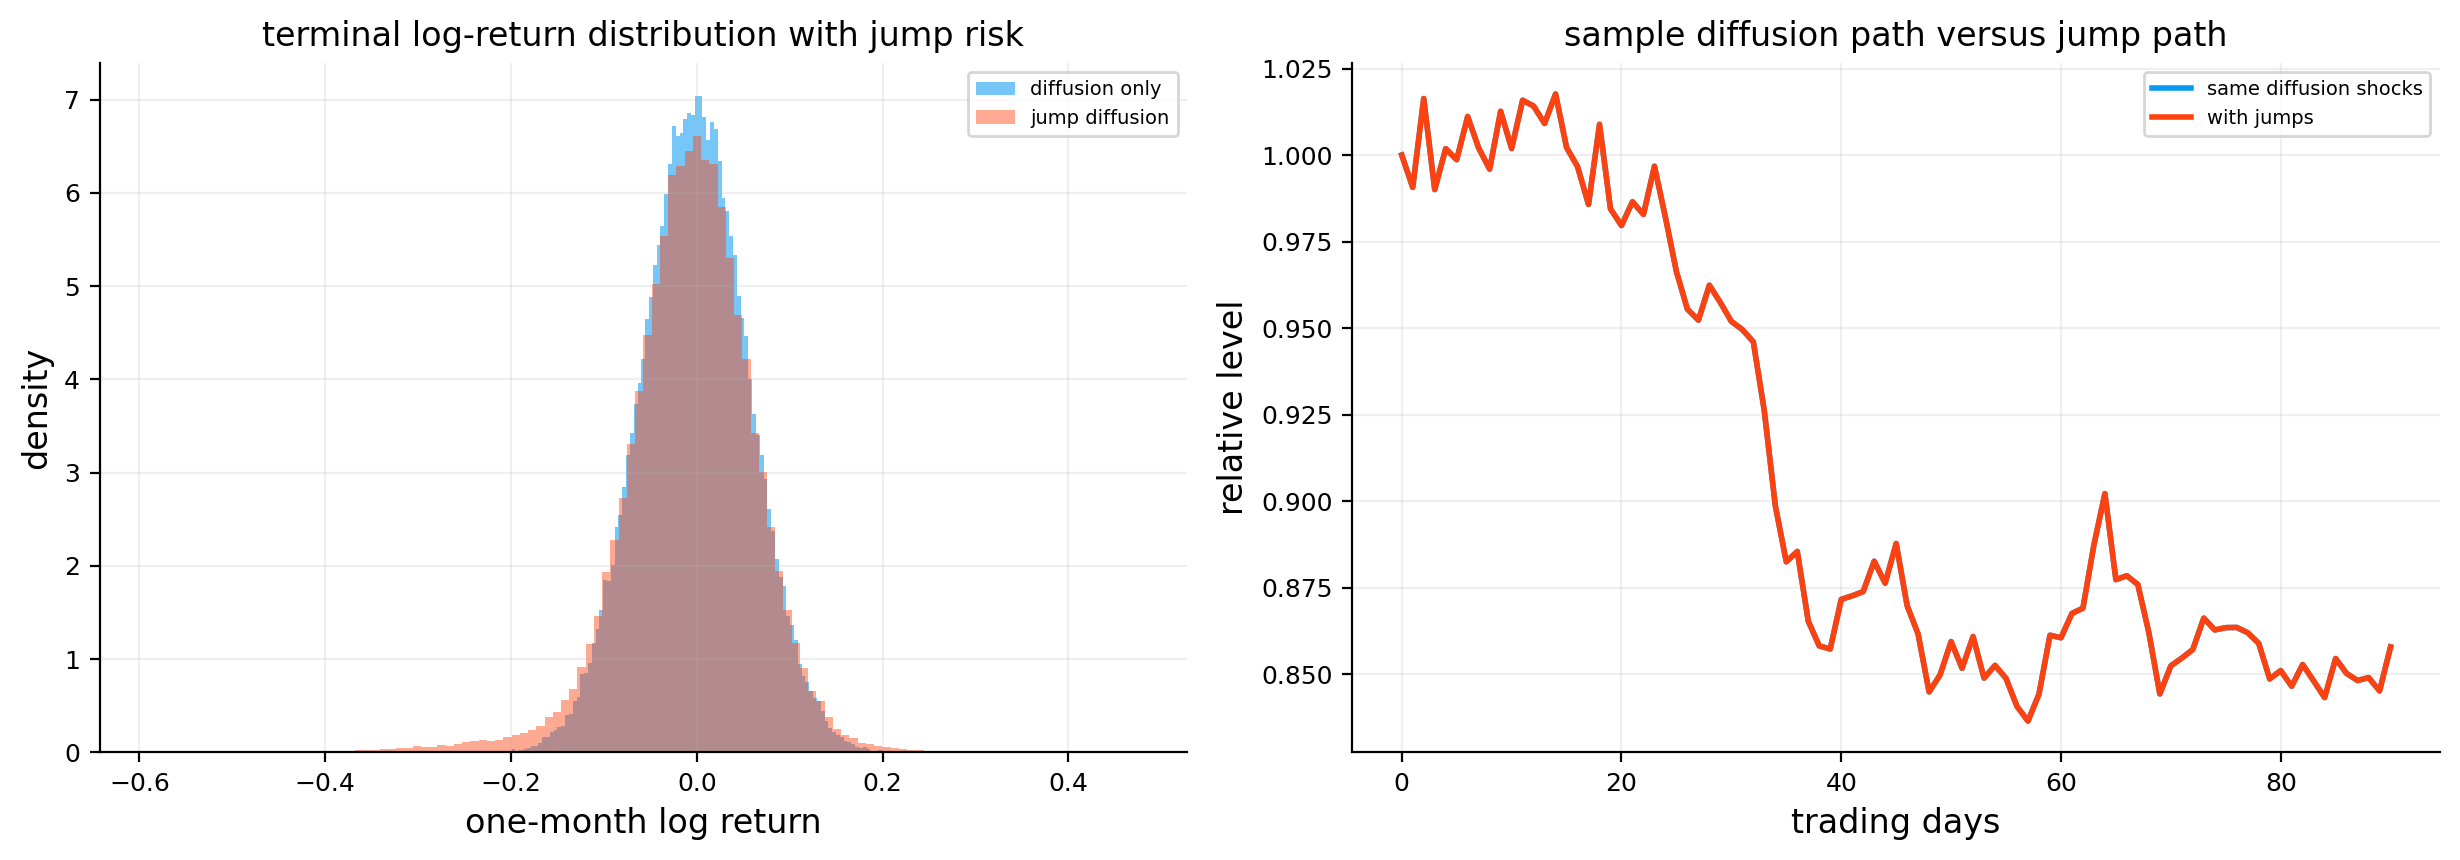

In [40]:
seed = 1107
rng = np.random.default_rng(seed)
n_demo = 120_000
sigma_demo = 0.20
lam_demo = 1.2
mu_j_demo = -0.055
sig_j_demo = 0.12
tau_j_demo = 30.0 / ann_days
r_no_jump = (-0.5 * sigma_demo ** 2 * tau_j_demo) + sigma_demo * np.sqrt(tau_j_demo) * rng.normal(size=n_demo)
n_jump = rng.poisson(lam_demo * tau_j_demo, size=n_demo)
r_jump = r_no_jump + n_jump * mu_j_demo + np.sqrt(n_jump) * sig_j_demo * rng.normal(size=n_demo)
z_path = rng.normal(size=90)
jump_flags = rng.uniform(size=90) < (lam_demo / 252.0)
jump_sizes = np.where(jump_flags, mu_j_demo + sig_j_demo * rng.normal(size=90), 0.0)
diff_path = np.r_[0.0, np.cumsum((-0.5 * sigma_demo ** 2 / 252.0) + sigma_demo / np.sqrt(252.0) * z_path)]
jump_path = np.r_[0.0, np.cumsum((-0.5 * sigma_demo ** 2 / 252.0) + sigma_demo / np.sqrt(252.0) * z_path + jump_sizes)]
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
axes[0].hist(r_no_jump, bins=120, density=True, alpha=0.55, label="diffusion only")
axes[0].hist(r_jump, bins=120, density=True, alpha=0.45, label="jump diffusion")
axes[0].set_title("terminal log-return distribution with jump risk")
axes[0].set_xlabel("one-month log return")
axes[0].set_ylabel("density")
axes[0].legend()
axes[1].plot(np.exp(diff_path), lw=2.0, label="same diffusion shocks")
axes[1].plot(np.exp(jump_path), lw=2.0, label="with jumps")
axes[1].scatter(np.where(jump_flags)[0] + 1, np.exp(jump_path[1:][jump_flags]), s=24, alpha=0.8)
axes[1].set_title("sample diffusion path versus jump path")
axes[1].set_xlabel("trading days")
axes[1].set_ylabel("relative level")
axes[1].legend()
plt.tight_layout()
plt.show()

In [41]:
@njit
def n_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


@njit
def black_px_nb(is_call, df, f_mean, strike, var):
    if var <= 1e-12:
        payoff = max(f_mean - strike, 0.0) if is_call else max(strike - f_mean, 0.0)
        return df * payoff
    sig = math.sqrt(var)
    d1 = (math.log(max(f_mean, 1e-300) / max(strike, 1e-300)) + 0.5 * var) / sig
    d2 = d1 - sig
    if is_call:
        return df * (f_mean * n_cdf(d1) - strike * n_cdf(d2))
    return df * (strike * n_cdf(-d2) - f_mean * n_cdf(-d1))


@njit
def merton_one(is_call, fwd, strike, tau, df, sigma, lam, mu_j, sig_j, max_jumps):
    jump_var = sig_j * sig_j
    kappa_j = math.exp(mu_j + 0.5 * jump_var) - 1.0
    mean_n = max(lam * tau, 0.0)
    wt = math.exp(-mean_n)
    px = 0.0
    for n in range(max_jumps + 1):
        var = sigma * sigma * tau + n * jump_var
        f_n = fwd * math.exp(-lam * kappa_j * tau + n * mu_j + 0.5 * n * jump_var)
        px += wt * black_px_nb(is_call, df, f_n, strike, var)
        if n < max_jumps:
            wt *= mean_n / (n + 1.0)
    return px


@njit(parallel=True)
def merton_px(is_call, fwd, strike, tau, df, sigma, lam, mu_j, sig_j, max_jumps):
    n = strike.size
    out = np.empty(n, dtype=np.float64)
    for i in prange(n):
        out[i] = merton_one(is_call[i], fwd[i], strike[i], tau[i], df[i], sigma, lam, mu_j, sig_j, max_jumps)
    return out


t0 = tic()
_ = merton_px(np.array([True, False]), np.array([100.0, 100.0]), np.array([105.0, 95.0]), np.array([0.2, 0.2]), np.array([0.99, 0.99]), 0.2, 0.8, -0.05, 0.12, 30)
merton_compile_time = toc("compile merton", t0, 2)

In [42]:
def iv_from_px(q, col):
    sigma = implied_vol_newton_bisection_python(
        q["option_type"].to_numpy(),
        q[col].to_numpy(dtype=float),
        q["forward"].to_numpy(dtype=float),
        q["strike"].to_numpy(dtype=float),
        q["tau"].to_numpy(dtype=float),
        q["discount_factor"].to_numpy(dtype=float),
        solver="lbr_lite",
        return_status=False,
    )
    return np.asarray(sigma, dtype=float)


def fit_merton(q):
    is_call = q["option_type"].eq("call").to_numpy(dtype=np.bool_)
    f = q["forward"].to_numpy(dtype=float)
    k_strike = q["strike"].to_numpy(dtype=float)
    tau = q["tau"].to_numpy(dtype=float)
    df = q["discount_factor"].to_numpy(dtype=float)
    y = q["mid"].to_numpy(dtype=float)
    eps = np.maximum(q["calib_scale_px"].to_numpy(dtype=float), 0.02)
    root_wt = np.sqrt(q["weight"].to_numpy(dtype=float))
    near_iv = pd.to_numeric(q.loc[q["k"].abs() <= 0.05, "iv_mid"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    all_iv = pd.to_numeric(q["iv_mid"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    atm_sigma = float(near_iv.median()) if len(near_iv) else float(all_iv.median()) if len(all_iv) else 0.20
    lo = np.array([0.03, 0.00, -0.50, 0.01])
    hi = np.array([1.20, 6.00, 0.25, 0.85])

    def err(p):
        px = merton_px(is_call, f, k_strike, tau, df, p[0], p[1], p[2], p[3], 45)
        r = root_wt * (px - y) / eps
        return np.where(np.isfinite(r), r, 1e3)

    starts = [np.array([atm_sigma, 0.40, -0.04, 0.10]), np.array([0.85 * atm_sigma, 1.25, -0.08, 0.16]), np.array([1.10 * atm_sigma, 0.15, -0.02, 0.06]), np.array([0.70 * atm_sigma, 2.50, -0.12, 0.22])]
    best = None
    for p0 in starts:
        t0 = tic()
        res = optimize.least_squares(
            err,
            np.minimum(np.maximum(np.nan_to_num(p0, nan=0.5 * (lo + hi), posinf=hi - 1e-5, neginf=lo + 1e-5), lo + 1e-6), hi - 1e-6),
            bounds=(lo, hi),
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=160,
            xtol=1e-7,
            ftol=1e-7,
        )
        item = {"res": res, "cost": float(res.cost), "seconds": time.perf_counter() - t0}
        if best is None or item["cost"] < best["cost"]:
            best = item
    return best["res"].x, best["res"].success, best["seconds"], best["res"].nfev, lo, hi

In [43]:

t0 = tic()
p_merton, ok_merton, seconds_merton, nfev_merton, lo_merton, hi_merton = fit_merton(q_px)
toc("calibrate merton", t0, len(q_px))
merton_fit = q_px.copy()
merton_fit["model"] = "merton"
merton_fit["model_price"] = merton_px(
    merton_fit["option_type"].eq("call").to_numpy(dtype=np.bool_),
    merton_fit["forward"].to_numpy(dtype=float),
    merton_fit["strike"].to_numpy(dtype=float),
    merton_fit["tau"].to_numpy(dtype=float),
    merton_fit["discount_factor"].to_numpy(dtype=float),
    p_merton[0], p_merton[1], p_merton[2], p_merton[3], 60,
)
merton_fit["model_iv"] = iv_from_px(merton_fit, "model_price")
merton_fit["iv_residual"] = merton_fit["model_iv"] - merton_fit["iv_mid"]
merton_fit["price_residual"] = merton_fit["model_price"] - merton_fit["mid"]
merton_tail_count = int((merton_fit["k"].abs() >= 0.14).sum())
merton_tail_ok = merton_tail_count >= 8
merton_params = pd.DataFrame([{"sigma": p_merton[0], "lambda_jump": p_merton[1], "mu_jump": p_merton[2], "sigma_jump": p_merton[3], "success": bool(ok_merton), "calibration_time": float(seconds_merton), "objective_evaluations": int(nfev_merton), "parameter_at_bound": near_bound(p_merton, lo_merton, hi_merton)}])
tail_merton = merton_fit["k"].abs() >= 0.14
merton_diag = pd.DataFrame([{
    "success": bool(ok_merton),
    "n_quotes": int(len(merton_fit)),
    "weighted_price_rmse": wrmse(merton_fit["price_residual"], merton_fit["weight"]),
    "weighted_iv_rmse": wrmse(merton_fit["iv_residual"], merton_fit["weight"]),
    "median_abs_iv_error": float(np.nanmedian(np.abs(merton_fit["iv_residual"]))),
    "p90_abs_iv_error": float(np.nanquantile(np.abs(merton_fit["iv_residual"]), 0.90)),
    "tail_count": merton_tail_count,
    "tail_diagnostic_valid": bool(merton_tail_ok),
    "tail_error": wrmse(merton_fit.loc[tail_merton, "iv_residual"], merton_fit.loc[tail_merton, "weight"]) if merton_tail_ok else np.nan,
    "jump_intensity": p_merton[1],
    "jump_mean": p_merton[2],
    "jump_volatility": p_merton[3],
    "parameter_at_bound": bool(merton_params.loc[0, "parameter_at_bound"]),
    "calibration_time": float(seconds_merton),
    "objective_evaluations": int(nfev_merton),
}])
display(merton_params)
display(merton_diag)


,sigma,lambda_jump,mu_jump,sigma_jump,success,calibration_time,objective_evaluations,parameter_at_bound
0,0.099075,0.386026,-0.146093,0.126411,True,0.051038,23,False


,success,n_quotes,weighted_price_rmse,weighted_iv_rmse,median_abs_iv_error,p90_abs_iv_error,tail_count,tail_diagnostic_valid,tail_error,jump_intensity,jump_mean,jump_volatility,parameter_at_bound,calibration_time,objective_evaluations
0,True,54,3.326638,0.009212,0.004419,0.032250,8,True,0.013282,0.386026,-0.146093,0.126411,False,0.051038,23


,model,tail_weighted_price_rmse
0,expiry atm black,16.581337
1,merton,3.252410


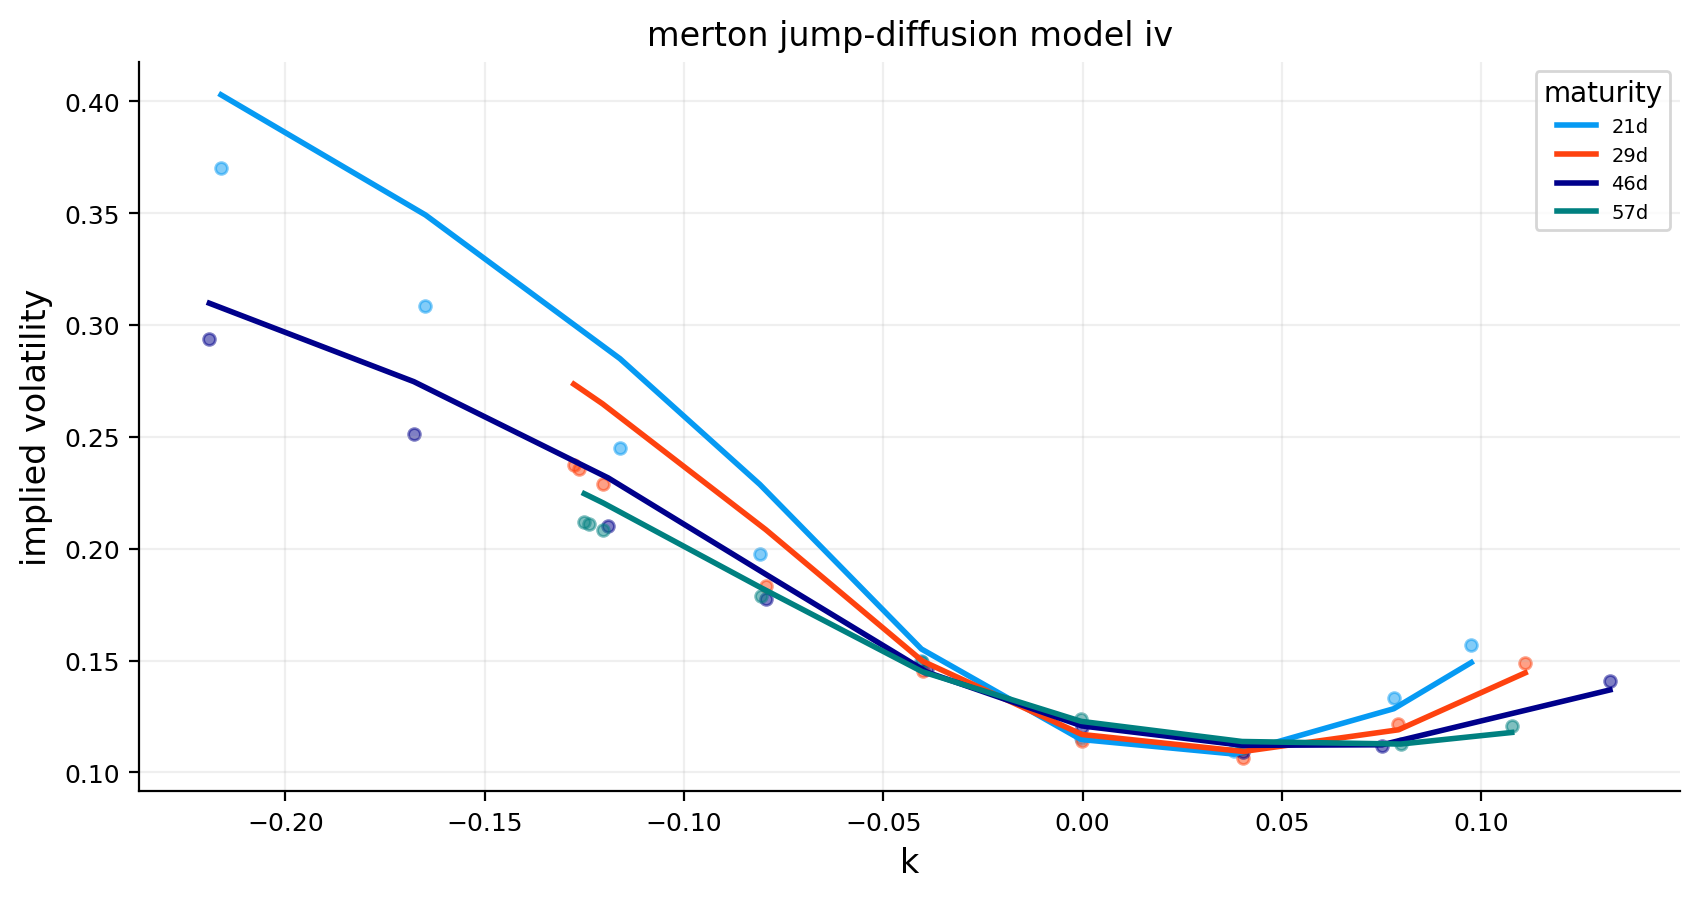

In [44]:

atm_by_expiry = q0[np.abs(q0["k"]) <= 0.05].groupby("expiry")["iv_mid"].median()
black0 = merton_fit.copy()
black0["atm_iv"] = black0["expiry"].map(atm_by_expiry).fillna(q0["iv_mid"].median())
black0["black_price"] = black76_price(black0["option_type"].to_numpy(), black0["forward"], black0["strike"], black0["tau"], black0["atm_iv"], black0["discount_factor"])
black0["black_residual"] = black0["black_price"] - black0["mid"]
if merton_tail_ok:
    tail_compare = pd.DataFrame([
        {"model": "expiry atm black", "tail_weighted_price_rmse": wrmse(black0.loc[tail_merton, "black_residual"], black0.loc[tail_merton, "weight"])},
        {"model": "merton", "tail_weighted_price_rmse": wrmse(merton_fit.loc[tail_merton, "price_residual"], merton_fit.loc[tail_merton, "weight"])},
    ])
else:
    tail_compare = pd.DataFrame([{"model": "merton", "tail_count": merton_tail_count, "tail_diagnostic_valid": False}])
display(tail_compare)

plot_expiries_merton = merton_fit.groupby("expiry").size().loc[lambda s: s >= 5].index
fig, ax = plt.subplots(figsize=(8.6, 4.6))
for expiry in plot_expiries_merton[:4]:
    g = merton_fit[merton_fit["expiry"].eq(expiry)].sort_values("k")
    ax.scatter(g["k"], g["iv_mid"], s=18, alpha=0.50)
    ax.plot(g["k"], g["model_iv"], lw=2.0, label=f"{g['dte_days'].median():.0f}d")
ax.set_title("merton jump-diffusion model iv")
ax.set_xlabel("k")
ax.set_ylabel("implied volatility")
ax.legend(title="maturity")
plt.tight_layout()
plt.show()


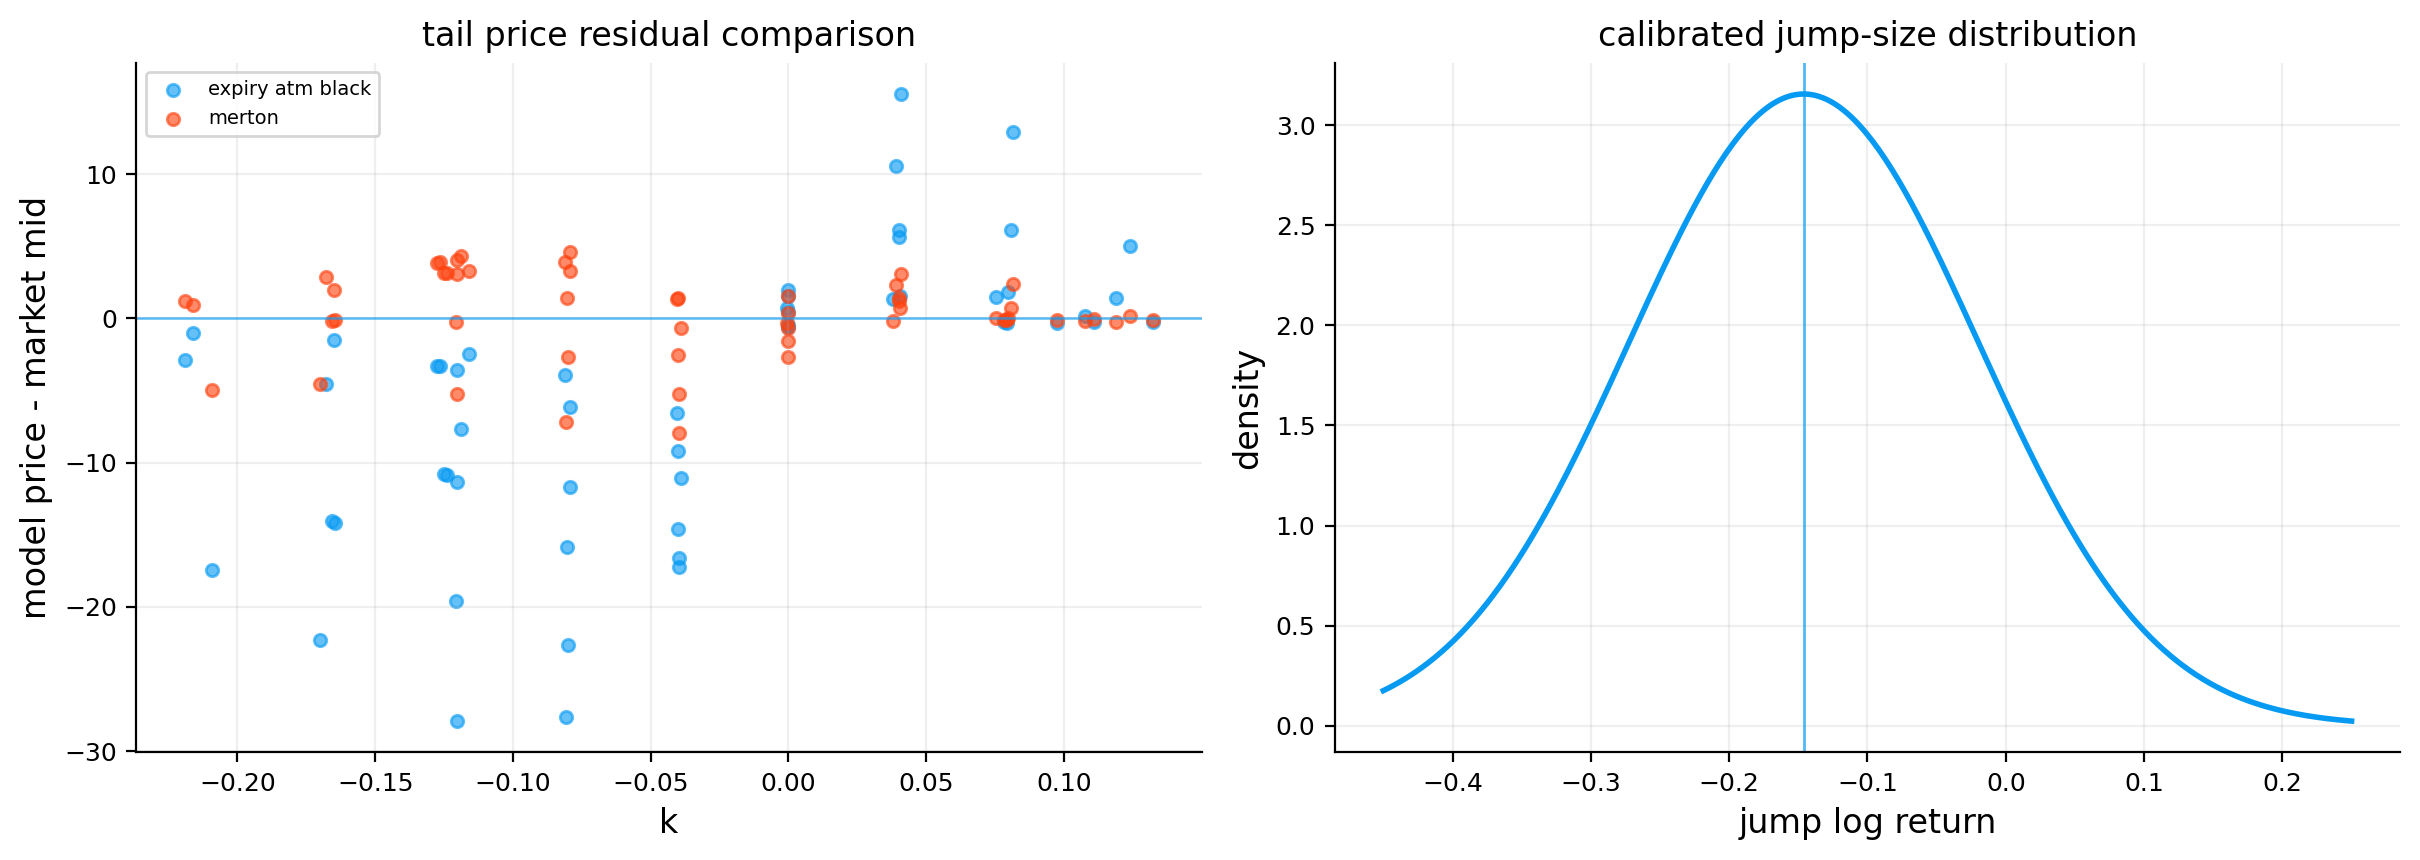

In [45]:

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4))
if merton_tail_ok:
    axes[0].scatter(black0["k"], black0["black_residual"], s=20, alpha=0.62, label="expiry atm black")
    axes[0].scatter(merton_fit["k"], merton_fit["price_residual"], s=20, alpha=0.62, label="merton")
    axes[0].axhline(0.0, lw=0.9, alpha=0.65)
    axes[0].set_title("tail price residual comparison")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("model price - market mid")
    axes[0].legend()
else:
    axes[0].axis("off")
    axes[0].table(cellText=tail_compare.fillna("").values, colLabels=tail_compare.columns, loc="center")
    axes[0].set_title("jump tail diagnostic skipped")
x_jump = np.linspace(-0.45, 0.25, 300)
y_jump = norm.pdf(x_jump, loc=p_merton[2], scale=p_merton[3])
axes[1].plot(x_jump, y_jump, lw=2.0)
axes[1].axvline(p_merton[2], lw=1.0, alpha=0.70)
axes[1].set_title("calibrated jump-size distribution")
axes[1].set_xlabel("jump log return")
axes[1].set_ylabel("density")
plt.tight_layout()
plt.show()


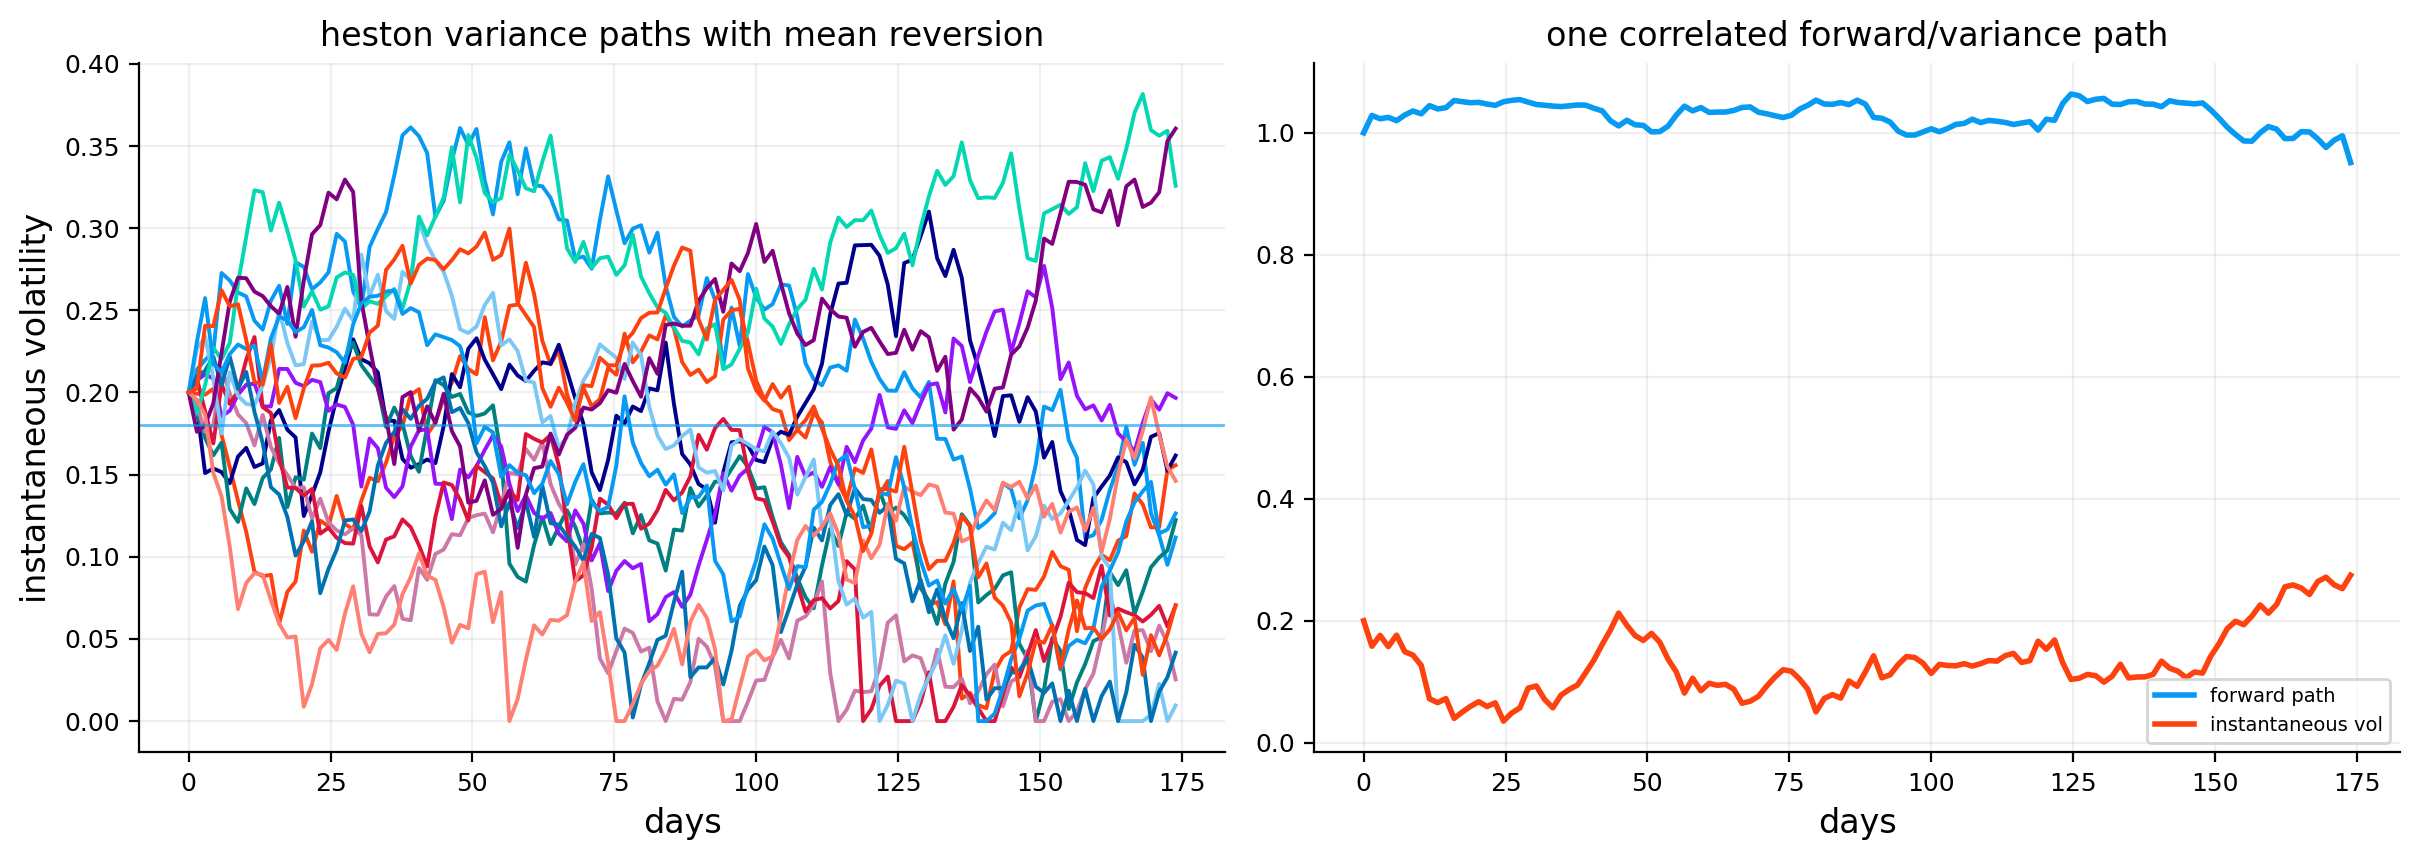

In [46]:
n_step_demo = 120
n_v_demo = 14
dt_demo = 1.0 / 252.0
t_demo = np.arange(n_step_demo + 1) * dt_demo
v_path = np.empty((n_step_demo + 1, n_v_demo))
v_path[0] = 0.20 ** 2
for i in range(n_step_demo):
    v_prev = np.maximum(v_path[i], 0.0)
    z_v = rng.normal(size=n_v_demo)
    v_path[i + 1] = v_path[i] + 3.0 * (0.18 ** 2 - v_prev) * dt_demo + 0.55 * np.sqrt(v_prev * dt_demo) * z_v
rho_demo = -0.70
z1 = rng.normal(size=n_step_demo)
z2 = rho_demo * z1 + np.sqrt(1.0 - rho_demo ** 2) * rng.normal(size=n_step_demo)
v_single = np.empty(n_step_demo + 1)
log_f_single = np.empty(n_step_demo + 1)
v_single[0] = 0.20 ** 2
log_f_single[0] = 0.0
for i in range(n_step_demo):
    vp = max(v_single[i], 0.0)
    log_f_single[i + 1] = log_f_single[i] - 0.5 * vp * dt_demo + np.sqrt(vp * dt_demo) * z1[i]
    v_single[i + 1] = v_single[i] + 3.0 * (0.18 ** 2 - vp) * dt_demo + 0.55 * np.sqrt(vp * dt_demo) * z2[i]
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4))
axes[0].plot(t_demo * ann_days, np.sqrt(np.maximum(v_path, 0.0)), lw=1.4)
axes[0].axhline(0.18, lw=1.0, alpha=0.65)
axes[0].set_title("heston variance paths with mean reversion")
axes[0].set_xlabel("days")
axes[0].set_ylabel("instantaneous volatility")
axes[1].plot(t_demo * ann_days, np.exp(log_f_single), lw=2.0, label="forward path")
axes[1].plot(t_demo * ann_days, np.sqrt(np.maximum(v_single, 0.0)), lw=2.0, label="instantaneous vol")
axes[1].set_title("one correlated forward/variance path")
axes[1].set_xlabel("days")
axes[1].legend()
plt.tight_layout()
plt.show()

In [47]:
mc_paths_opt, mc_paths_final, mc_steps_per_year = 1024, 8192, 52
def shocks(n_path, n_step, salt):
    n_half = max(int(n_path) // 2, 2)
    r = np.random.default_rng(seed + salt)
    z1 = r.normal(size=(n_half, n_step))
    z2 = r.normal(size=(n_half, n_step))
    return np.vstack([z1, -z1]).astype(np.float64), np.vstack([z2, -z2]).astype(np.float64)


n_step_mc = int(np.ceil(float(q_mc["tau"].max()) * mc_steps_per_year)) + 2
z_s_opt, z_v_opt = shocks(mc_paths_opt, n_step_mc, 31)
z_s_final, z_v_final = shocks(mc_paths_final, n_step_mc, 41)

In [48]:
@njit(parallel=True)
def heston_px_mc(is_call, fwd, strike, tau, df, v0, kappa, theta, xi, rho, steps_per_year, z_s, z_v):
    n_quote = strike.size
    n_path = z_s.shape[0]
    px = np.empty(n_quote, dtype=np.float64)
    se = np.empty(n_quote, dtype=np.float64)
    rho2 = math.sqrt(max(1.0 - rho * rho, 1e-12))
    for i in prange(n_quote):
        n_step = max(1, int(math.ceil(tau[i] * steps_per_year)))
        dt = tau[i] / n_step
        sqrt_dt = math.sqrt(dt)
        s1 = 0.0
        s2 = 0.0
        for p in range(n_path):
            log_f = math.log(max(fwd[i], 1e-300))
            v = max(v0, 1e-12)
            for j in range(n_step):
                vp = max(v, 0.0)
                dw_s = z_s[p, j]
                dw_v = rho * z_s[p, j] + rho2 * z_v[p, j]
                log_f += -0.5 * vp * dt + math.sqrt(vp) * sqrt_dt * dw_s
                v = v + kappa * (theta - vp) * dt + xi * math.sqrt(vp) * sqrt_dt * dw_v
            ft = math.exp(log_f)
            payoff = max(ft - strike[i], 0.0) if is_call[i] else max(strike[i] - ft, 0.0)
            s1 += payoff
            s2 += payoff * payoff
        mean = s1 / n_path
        var = max(s2 / n_path - mean * mean, 0.0)
        px[i] = df[i] * mean
        se[i] = df[i] * math.sqrt(var / n_path)
    return px, se


t0 = tic()
_ = heston_px_mc(np.array([True]), np.array([100.0]), np.array([100.0]), np.array([0.10]), np.array([0.99]), 0.04, 2.0, 0.04, 0.5, -0.6, mc_steps_per_year, z_s_opt[:8], z_v_opt[:8])
heston_compile_time = toc("compile heston mc", t0, 1)

In [49]:
def fit_heston(q):
    is_call = q["option_type"].eq("call").to_numpy(dtype=np.bool_)
    f = q["forward"].to_numpy(dtype=float)
    k_strike = q["strike"].to_numpy(dtype=float)
    tau = q["tau"].to_numpy(dtype=float)
    df = q["discount_factor"].to_numpy(dtype=float)
    y = q["mid"].to_numpy(dtype=float)
    eps = np.maximum(q["calib_scale_px"].to_numpy(dtype=float), 0.02)
    root_wt = np.sqrt(q["weight"].to_numpy(dtype=float))
    atm_vol = float(np.nanmedian(q.loc[q["k"].abs() <= 0.05, "iv_mid"]))
    if not np.isfinite(atm_vol):
        atm_vol = float(np.nanmedian(q["iv_mid"]))
    atm_var = float(np.clip(atm_vol ** 2, 0.005, 0.25))
    lo = np.array([0.0025, 0.15, 0.0025, 0.05, -0.95])
    hi = np.array([0.2500, 8.00, 0.2500, 2.50, 0.30])
    count = {"n": 0}

    def err(p):
        count["n"] += 1
        px, _ = heston_px_mc(is_call, f, k_strike, tau, df, p[0], p[1], p[2], p[3], p[4], mc_steps_per_year, z_s_opt, z_v_opt)
        r = root_wt * (px - y) / eps
        return np.where(np.isfinite(r), r, 1e3)

    starts = [np.array([atm_var, 2.0, atm_var, 0.55, -0.65])]
    best = None
    for p0 in starts:
        t0 = tic()
        res = optimize.least_squares(
            err,
            np.minimum(np.maximum(np.nan_to_num(p0, nan=0.5 * (lo + hi), posinf=hi - 1e-5, neginf=lo + 1e-5), lo + 1e-6), hi - 1e-6),
            bounds=(lo, hi),
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=70,
            xtol=2e-6,
            ftol=2e-6,
        )
        item = {"res": res, "cost": float(res.cost), "seconds": time.perf_counter() - t0}
        if best is None or item["cost"] < best["cost"]:
            best = item
    return best["res"].x, best["res"].success, best["seconds"], count["n"], lo, hi

In [50]:
t0 = tic()
p_heston, ok_heston, seconds_heston, evals_heston, lo_heston, hi_heston = fit_heston(q_mc)
toc("calibrate heston mc", t0, len(q_mc))
px_heston, se_heston = heston_px_mc(
    q_mc["option_type"].eq("call").to_numpy(dtype=np.bool_),
    q_mc["forward"].to_numpy(dtype=float),
    q_mc["strike"].to_numpy(dtype=float),
    q_mc["tau"].to_numpy(dtype=float),
    q_mc["discount_factor"].to_numpy(dtype=float),
    p_heston[0], p_heston[1], p_heston[2], p_heston[3], p_heston[4],
    mc_steps_per_year, z_s_final, z_v_final,
)
heston_fit = q_mc.copy()
heston_fit["model"] = "heston"
heston_fit["model_price"] = px_heston
heston_fit["mc_standard_error"] = se_heston
heston_fit["model_iv"] = iv_from_px(heston_fit, "model_price")
heston_fit["iv_residual"] = heston_fit["model_iv"] - heston_fit["iv_mid"]
heston_fit["price_residual"] = heston_fit["model_price"] - heston_fit["mid"]
heston_params = pd.DataFrame([{"v0": p_heston[0], "kappa": p_heston[1], "theta": p_heston[2], "xi": p_heston[3], "rho": p_heston[4], "success": bool(ok_heston), "feller_ratio": float(2.0 * p_heston[1] * p_heston[2] / max(p_heston[3] ** 2, 1e-12)), "calibration_time": float(seconds_heston), "objective_evaluations": int(evals_heston), "parameter_at_bound": near_bound(p_heston, lo_heston, hi_heston)}])
heston_diag = pd.DataFrame([{
    "success": bool(ok_heston),
    "n_quotes": int(len(heston_fit)),
    "weighted_price_rmse": wrmse(heston_fit["price_residual"], heston_fit["weight"]),
    "weighted_iv_rmse": wrmse(heston_fit["iv_residual"], heston_fit["weight"]),
    "median_abs_iv_error": float(np.nanmedian(np.abs(heston_fit["iv_residual"]))),
    "p90_abs_iv_error": float(np.nanquantile(np.abs(heston_fit["iv_residual"]), 0.90)),
    "median_mc_standard_error": float(np.nanmedian(heston_fit["mc_standard_error"])),
    "feller_ratio": float(heston_params.loc[0, "feller_ratio"]),
    "feller_warning": bool(heston_params.loc[0, "feller_ratio"] < 1.0),
    "parameter_at_bound": bool(heston_params.loc[0, "parameter_at_bound"]),
    "calibration_time": float(seconds_heston),
    "objective_evaluations": int(evals_heston),
    "pricing_time": np.nan,
}])
heston_mc_error = heston_fit[["quote_id", "expiry", "strike", "k", "dte_days", "model_price", "mc_standard_error", "price_residual"]].copy()
display(heston_params)
display(heston_diag)

,v0,kappa,theta,xi,rho,success,feller_ratio,calibration_time,objective_evaluations,parameter_at_bound
0,0.011693,1.980971,0.083590,1.249512,-0.628617,True,0.212121,3.417353,177,False


,success,n_quotes,weighted_price_rmse,weighted_iv_rmse,median_abs_iv_error,p90_abs_iv_error,median_mc_standard_error,feller_ratio,feller_warning,parameter_at_bound,calibration_time,objective_evaluations,pricing_time
0,True,34,3.863250,0.014869,0.009626,0.039230,0.454690,0.212121,True,False,3.417353,177,NaN


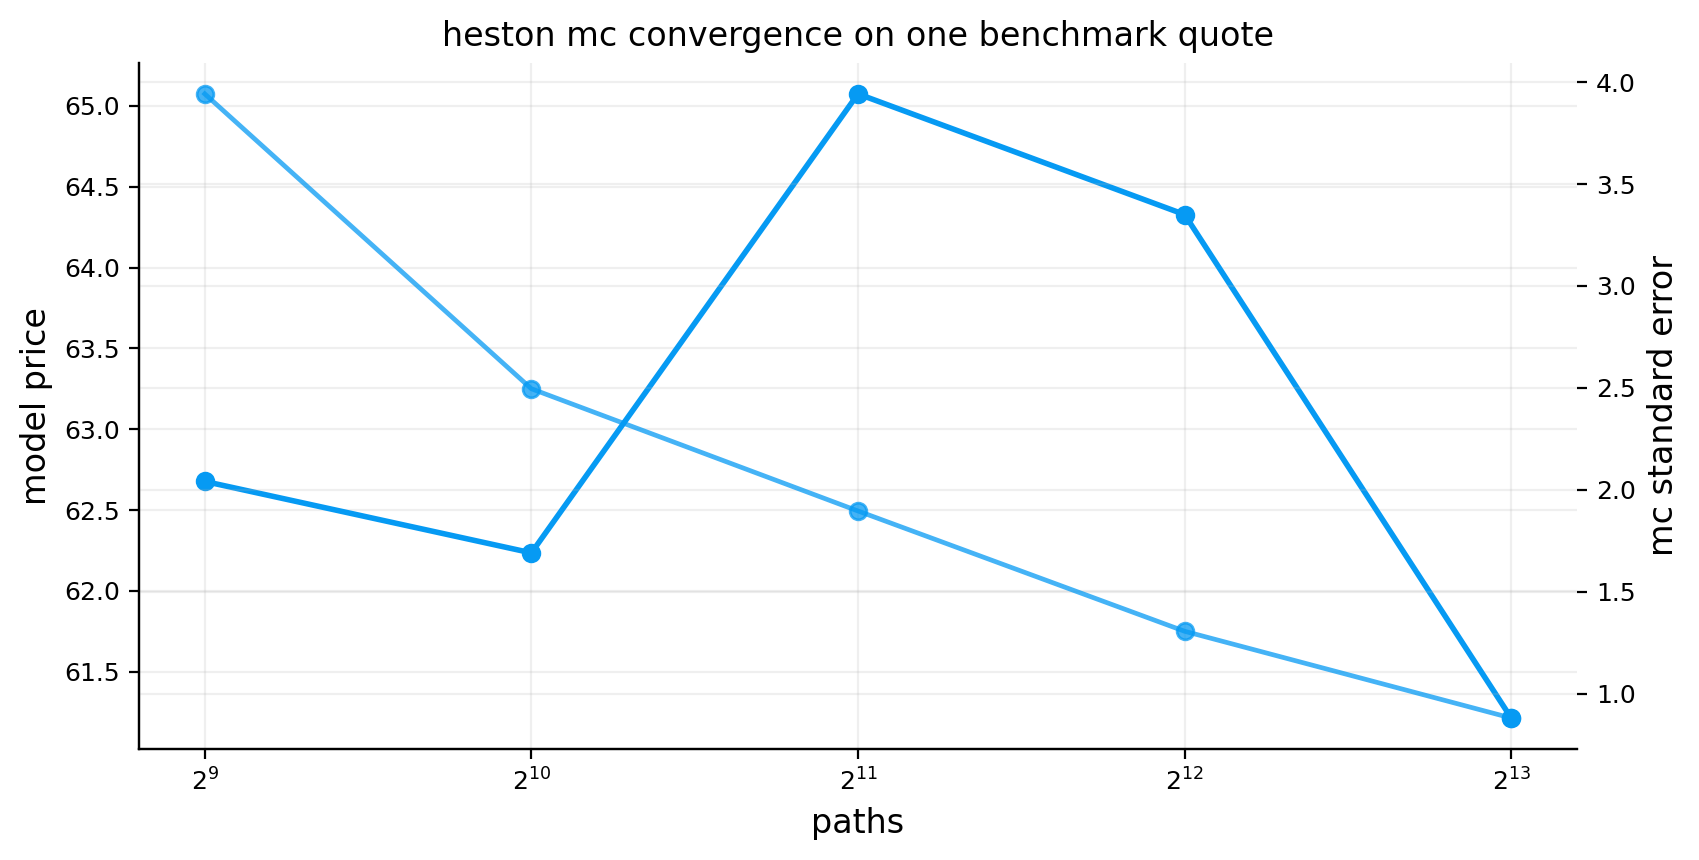

In [51]:
paths_grid = np.array([512, 1024, 2048, 4096, 8192])
q_conv = heston_fit.iloc[[int(np.argmin(np.abs(heston_fit["k"].to_numpy(dtype=float))) )]].copy()
heston_conv = []
for n_path in paths_grid:
    zc_s, zc_v = shocks(int(n_path), n_step_mc, int(500 + n_path))
    px_c, se_c = heston_px_mc(
        q_conv["option_type"].eq("call").to_numpy(dtype=np.bool_),
        q_conv["forward"].to_numpy(dtype=float),
        q_conv["strike"].to_numpy(dtype=float),
        q_conv["tau"].to_numpy(dtype=float),
        q_conv["discount_factor"].to_numpy(dtype=float),
        p_heston[0], p_heston[1], p_heston[2], p_heston[3], p_heston[4],
        mc_steps_per_year, zc_s, zc_v,
    )
    heston_conv.append({"paths": int(n_path), "price": float(px_c[0]), "mc_standard_error": float(se_c[0])})
heston_convergence = pd.DataFrame(heston_conv)
fig, ax1 = plt.subplots(figsize=(8.6, 4.4))
ax1.plot(heston_convergence["paths"], heston_convergence["price"], marker="o", lw=2.0)
ax1.set_xscale("log", base=2)
ax1.set_title("heston mc convergence on one benchmark quote")
ax1.set_xlabel("paths")
ax1.set_ylabel("model price")
ax2 = ax1.twinx()
ax2.plot(heston_convergence["paths"], heston_convergence["mc_standard_error"], marker="o", lw=1.7, alpha=0.75)
ax2.set_ylabel("mc standard error")
plt.tight_layout()
plt.show()

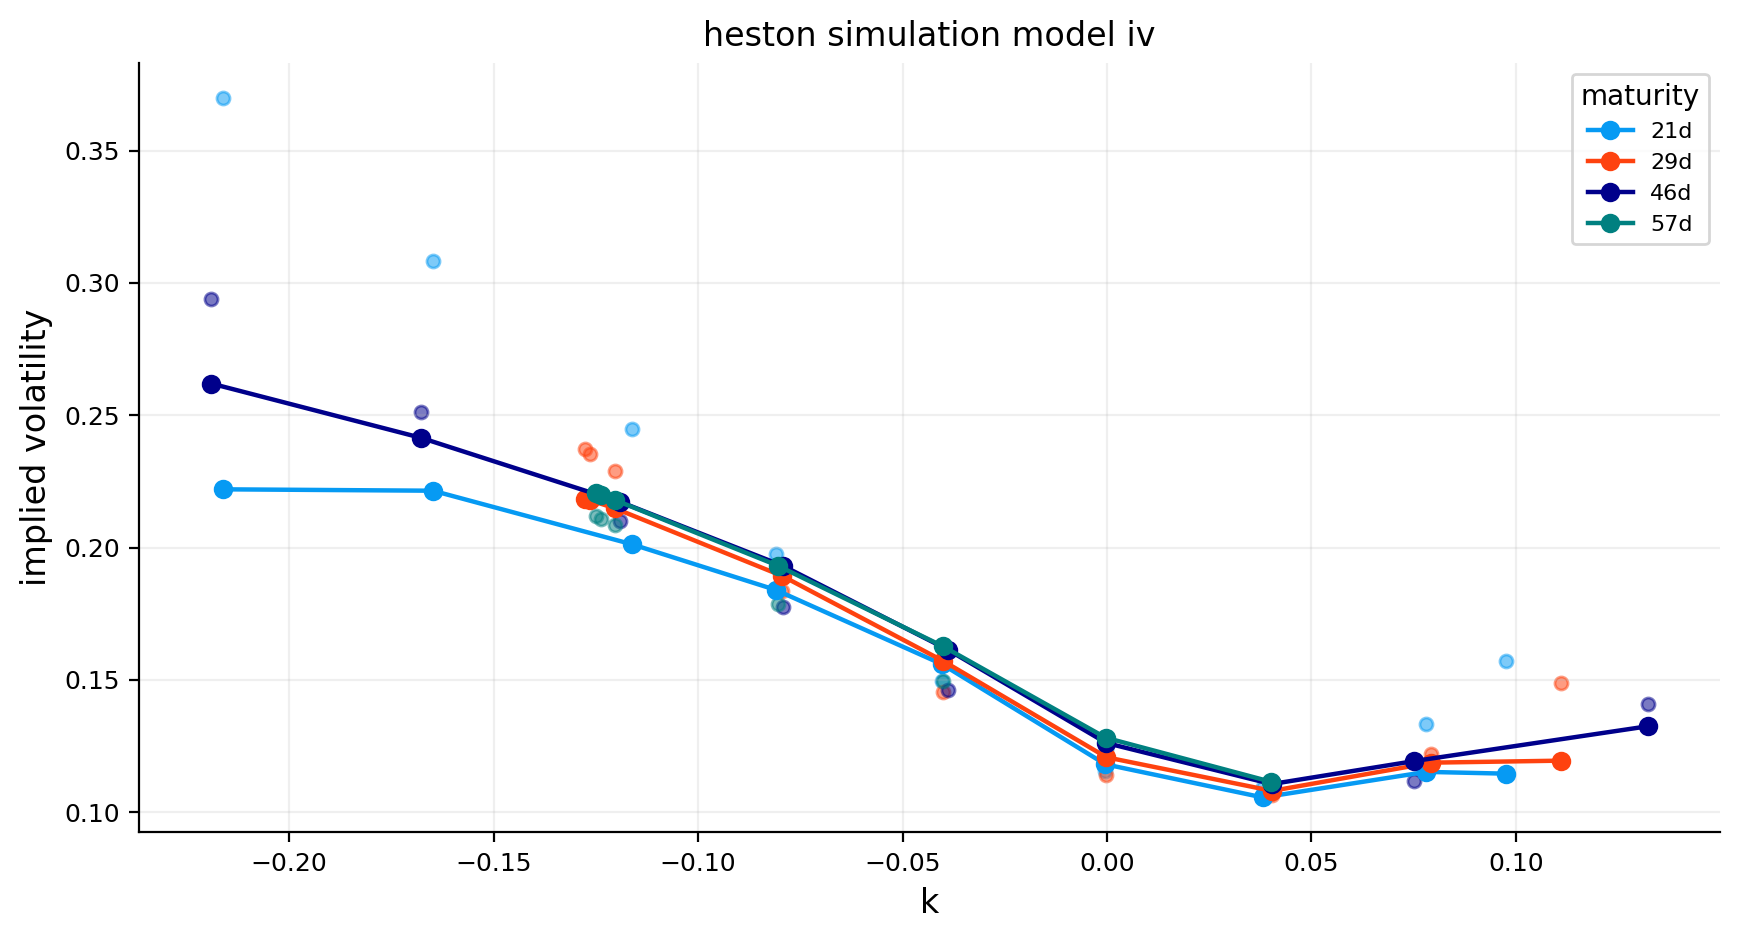

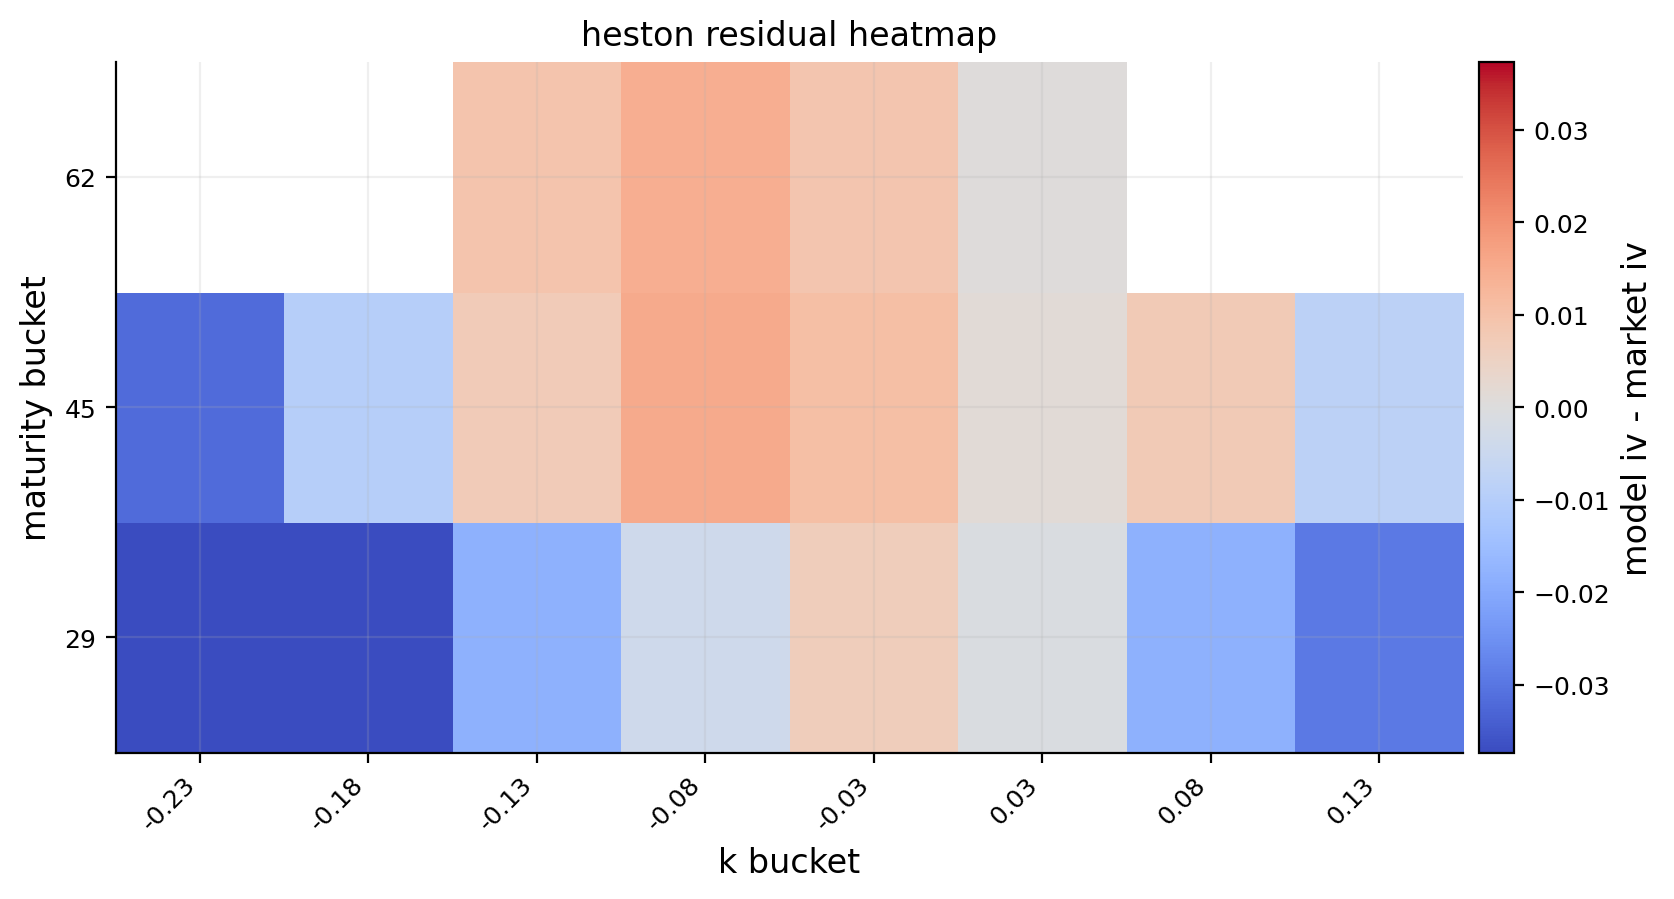

In [52]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
for expiry in heston_fit["expiry"].drop_duplicates().head(5):
    g = heston_fit[heston_fit["expiry"].eq(expiry)].sort_values("k")
    if len(g) < 3:
        continue
    ax.scatter(g["k"], g["iv_mid"], s=22, alpha=0.52)
    ax.plot(g["k"], g["model_iv"], marker="o", lw=1.6, label=f"{g['dte_days'].median():.0f}d")
ax.set_title("heston simulation model iv")
ax.set_xlabel("k")
ax.set_ylabel("implied volatility")
ax.legend(title="maturity", fontsize=8)
plt.tight_layout()
plt.show()

z = heston_fit.copy()
z["k_bin"] = pd.cut(z["k"], np.linspace(-0.26, 0.26, 11))
z["dte_bin"] = pd.cut(z["dte_days"], np.linspace(21.0, 135.0, 8))
h = z.pivot_table(index="dte_bin", columns="k_bin", values="iv_residual", aggfunc="median", observed=False)
lim = float(np.nanquantile(np.abs(h.to_numpy(dtype=float)), 0.90)) if np.isfinite(h.to_numpy(dtype=float)).any() else 0.03
fig, ax = plt.subplots(figsize=(8.8, 4.6))
im = ax.imshow(h.to_numpy(dtype=float), origin="lower", aspect="auto", cmap="coolwarm", vmin=-lim, vmax=lim)
ax.set_title("heston residual heatmap")
ax.set_xlabel("k bucket")
ax.set_ylabel("maturity bucket")
ax.set_xticks(np.arange(h.shape[1]))
ax.set_xticklabels([f"{b.mid:.2f}" for b in h.columns], rotation=45, ha="right")
ax.set_yticks(np.arange(h.shape[0]))
ax.set_yticklabels([f"{b.mid:.0f}" for b in h.index])
fig.colorbar(im, ax=ax, pad=0.01, label="model iv - market iv")
plt.tight_layout()
plt.show()

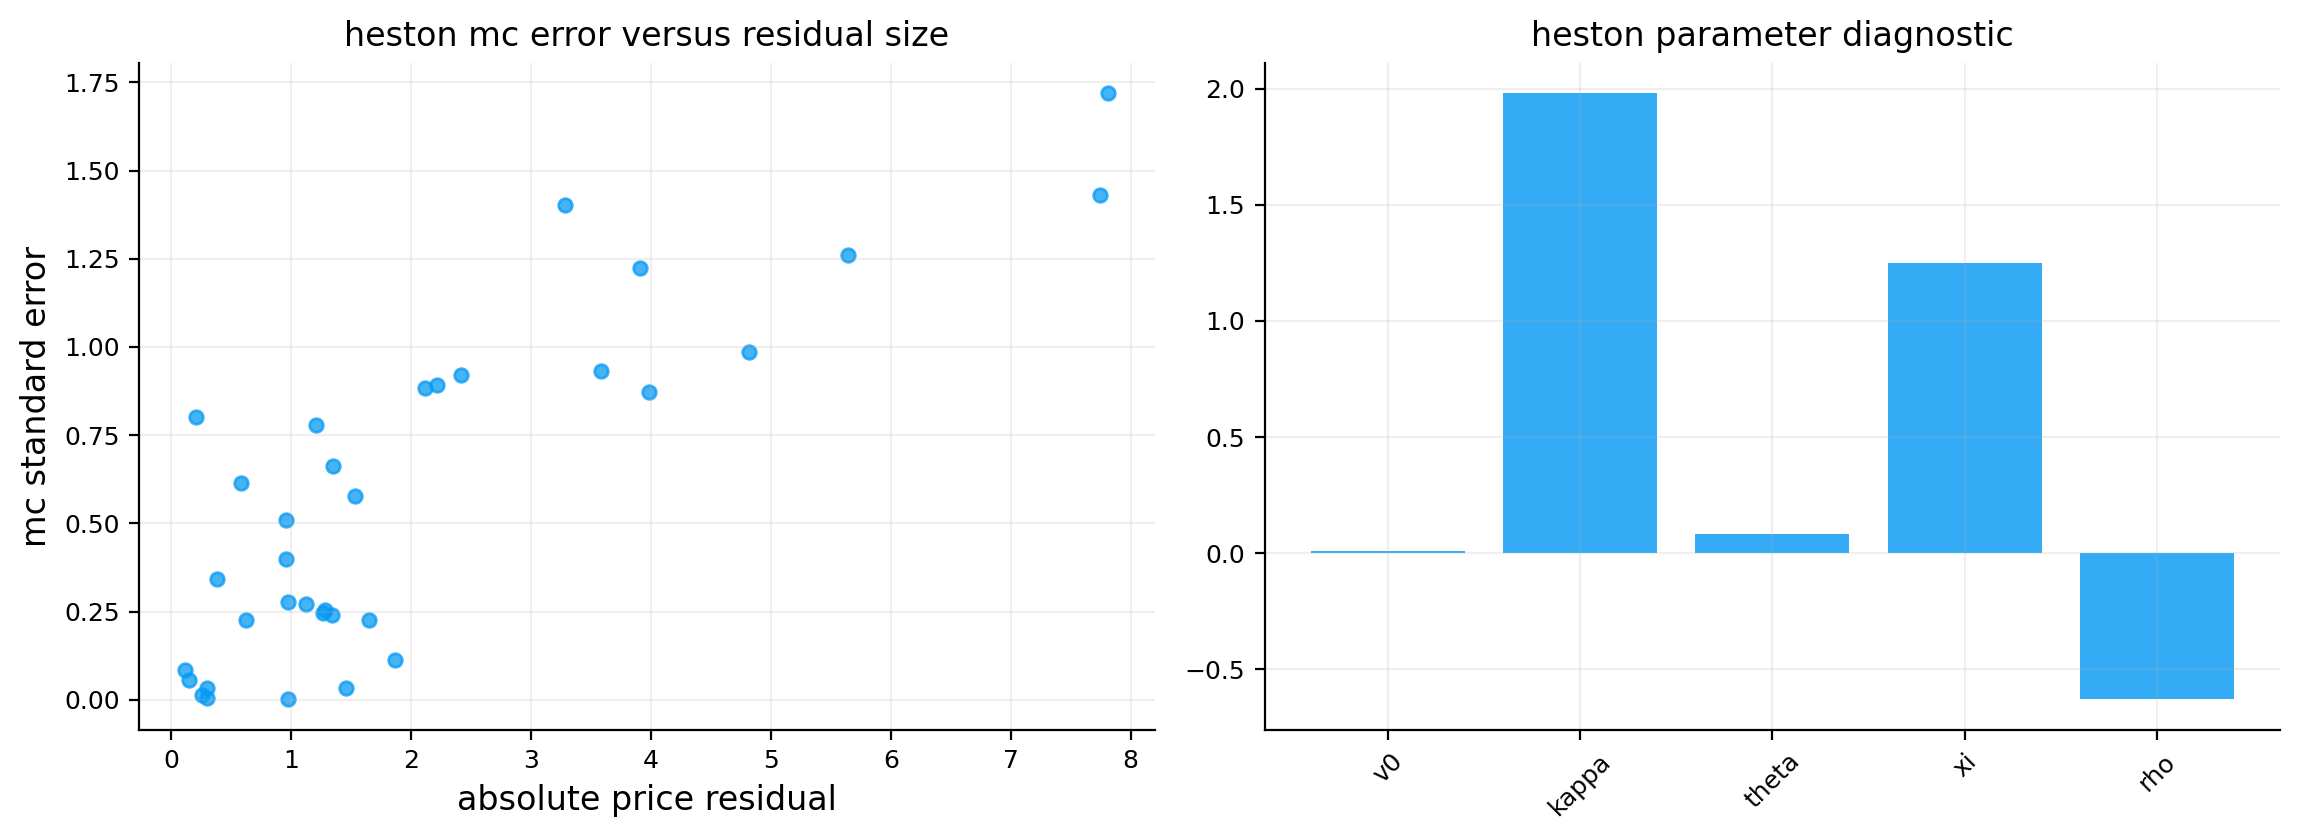

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))
axes[0].scatter(np.abs(heston_fit["price_residual"]), heston_fit["mc_standard_error"], s=24, alpha=0.75)
axes[0].set_title("heston mc error versus residual size")
axes[0].set_xlabel("absolute price residual")
axes[0].set_ylabel("mc standard error")
p_plot = heston_params[["v0", "kappa", "theta", "xi", "rho"]].iloc[0]
axes[1].bar(p_plot.index, p_plot.values, alpha=0.82)
axes[1].set_title("heston parameter diagnostic")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [54]:
def bates_shocks(n_path, n_step, salt):
    n_half = max(int(n_path) // 2, 2)
    r = np.random.default_rng(seed + salt)
    z1 = r.normal(size=(n_half, n_step))
    z2 = r.normal(size=(n_half, n_step))
    zj = r.normal(size=(n_half, n_step))
    uj = r.uniform(size=(n_half, n_step))
    return np.vstack([z1, -z1]).astype(np.float64), np.vstack([z2, -z2]).astype(np.float64), np.vstack([zj, -zj]).astype(np.float64), np.vstack([uj, uj]).astype(np.float64)


zb_s_opt, zb_v_opt, zb_j_opt, ub_j_opt = bates_shocks(mc_paths_opt, n_step_mc, 51)
zb_s_final, zb_v_final, zb_j_final, ub_j_final = bates_shocks(mc_paths_final, n_step_mc, 61)

In [55]:
@njit(parallel=True)
def bates_px_mc(is_call, fwd, strike, tau, df, v0, kappa, theta, xi, rho, lam, mu_j, sig_j, steps_per_year, z_s, z_v, z_j, u_j):
    n_quote = strike.size
    n_path = z_s.shape[0]
    px = np.empty(n_quote, dtype=np.float64)
    se = np.empty(n_quote, dtype=np.float64)
    rho2 = math.sqrt(max(1.0 - rho * rho, 1e-12))
    kappa_j = math.exp(mu_j + 0.5 * sig_j * sig_j) - 1.0
    for i in prange(n_quote):
        n_step = max(1, int(math.ceil(tau[i] * steps_per_year)))
        dt = tau[i] / n_step
        sqrt_dt = math.sqrt(dt)
        jump_prob = min(max(lam * dt, 0.0), 0.35)
        s1 = 0.0
        s2 = 0.0
        for p in range(n_path):
            log_f = math.log(max(fwd[i], 1e-300))
            v = max(v0, 1e-12)
            for j in range(n_step):
                vp = max(v, 0.0)
                dw_s = z_s[p, j]
                dw_v = rho * z_s[p, j] + rho2 * z_v[p, j]
                jump = 0.0
                if u_j[p, j] < jump_prob:
                    jump = mu_j + sig_j * z_j[p, j]
                log_f += (-0.5 * vp - lam * kappa_j) * dt + math.sqrt(vp) * sqrt_dt * dw_s + jump
                v = v + kappa * (theta - vp) * dt + xi * math.sqrt(vp) * sqrt_dt * dw_v
            ft = math.exp(log_f)
            payoff = max(ft - strike[i], 0.0) if is_call[i] else max(strike[i] - ft, 0.0)
            s1 += payoff
            s2 += payoff * payoff
        mean = s1 / n_path
        var = max(s2 / n_path - mean * mean, 0.0)
        px[i] = df[i] * mean
        se[i] = df[i] * math.sqrt(var / n_path)
    return px, se


t0 = tic()
_ = bates_px_mc(np.array([True]), np.array([100.0]), np.array([100.0]), np.array([0.10]), np.array([0.99]), 0.04, 2.0, 0.04, 0.5, -0.6, 0.5, -0.04, 0.10, mc_steps_per_year, zb_s_opt[:8], zb_v_opt[:8], zb_j_opt[:8], ub_j_opt[:8])
bates_compile_time = toc("compile bates mc", t0, 1)

In [56]:
def fit_bates(q):
    is_call = q["option_type"].eq("call").to_numpy(dtype=np.bool_)
    f = q["forward"].to_numpy(dtype=float)
    k_strike = q["strike"].to_numpy(dtype=float)
    tau = q["tau"].to_numpy(dtype=float)
    df = q["discount_factor"].to_numpy(dtype=float)
    y = q["mid"].to_numpy(dtype=float)
    eps = np.maximum(q["calib_scale_px"].to_numpy(dtype=float), 0.02)
    root_wt = np.sqrt(q["weight"].to_numpy(dtype=float))
    h0 = p_heston.copy()
    m0 = p_merton.copy()
    lo = np.array([0.0025, 0.15, 0.0025, 0.05, -0.95, 0.00, -0.50, 0.01])
    hi = np.array([0.2500, 8.00, 0.2500, 2.50, 0.30, 6.00, 0.25, 0.85])
    count = {"n": 0}

    def err(p):
        count["n"] += 1
        px, _ = bates_px_mc(is_call, f, k_strike, tau, df, p[0], p[1], p[2], p[3], p[4], p[5], p[6], p[7], mc_steps_per_year, zb_s_opt, zb_v_opt, zb_j_opt, ub_j_opt)
        r = root_wt * (px - y) / eps
        reg = np.array([
            0.15 * (p[0] - h0[0]) / max(h0[0], 0.02),
            0.10 * (p[3] - h0[3]) / max(h0[3], 0.20),
            0.12 * (p[5] - m0[1]) / max(abs(m0[1]) + 0.50, 0.50),
            0.12 * (p[6] - m0[2]) / 0.25,
            0.12 * (p[7] - m0[3]) / 0.25,
        ])
        return np.r_[np.where(np.isfinite(r), r, 1e3), reg]

    starts = [
        np.r_[h0, m0[1], m0[2], m0[3]],
    ]
    best = None
    for p0 in starts:
        t0 = tic()
        res = optimize.least_squares(
            err,
            np.minimum(np.maximum(np.nan_to_num(p0, nan=0.5 * (lo + hi), posinf=hi - 1e-5, neginf=lo + 1e-5), lo + 1e-6), hi - 1e-6),
            bounds=(lo, hi),
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=70,
            xtol=2e-6,
            ftol=2e-6,
        )
        item = {"res": res, "cost": float(res.cost), "seconds": time.perf_counter() - t0}
        if best is None or item["cost"] < best["cost"]:
            best = item
    return best["res"].x, best["res"].success, best["seconds"], count["n"], lo, hi

In [57]:
t0 = tic()
p_bates, ok_bates, seconds_bates, evals_bates, lo_bates, hi_bates = fit_bates(q_mc)
toc("calibrate bates mc", t0, len(q_mc))
px_bates, se_bates = bates_px_mc(
    q_mc["option_type"].eq("call").to_numpy(dtype=np.bool_),
    q_mc["forward"].to_numpy(dtype=float),
    q_mc["strike"].to_numpy(dtype=float),
    q_mc["tau"].to_numpy(dtype=float),
    q_mc["discount_factor"].to_numpy(dtype=float),
    p_bates[0], p_bates[1], p_bates[2], p_bates[3], p_bates[4], p_bates[5], p_bates[6], p_bates[7],
    mc_steps_per_year, zb_s_final, zb_v_final, zb_j_final, ub_j_final,
)
bates_fit = q_mc.copy()
bates_fit["model"] = "bates"
bates_fit["model_price"] = px_bates
bates_fit["mc_standard_error"] = se_bates
bates_fit["model_iv"] = iv_from_px(bates_fit, "model_price")
bates_fit["iv_residual"] = bates_fit["model_iv"] - bates_fit["iv_mid"]
bates_fit["price_residual"] = bates_fit["model_price"] - bates_fit["mid"]
bates_params = pd.DataFrame([{"v0": p_bates[0], "kappa": p_bates[1], "theta": p_bates[2], "xi": p_bates[3], "rho": p_bates[4], "lambda_jump": p_bates[5], "mu_jump": p_bates[6], "sigma_jump": p_bates[7], "success": bool(ok_bates), "calibration_time": float(seconds_bates), "objective_evaluations": int(evals_bates), "parameter_at_bound": near_bound(p_bates, lo_bates, hi_bates)}])
bates_diag = pd.DataFrame([{
    "success": bool(ok_bates),
    "n_quotes": int(len(bates_fit)),
    "weighted_price_rmse": wrmse(bates_fit["price_residual"], bates_fit["weight"]),
    "weighted_iv_rmse": wrmse(bates_fit["iv_residual"], bates_fit["weight"]),
    "median_abs_iv_error": float(np.nanmedian(np.abs(bates_fit["iv_residual"]))),
    "p90_abs_iv_error": float(np.nanquantile(np.abs(bates_fit["iv_residual"]), 0.90)),
    "tail_count": int((bates_fit["k"].abs() >= 0.14).sum()),
    "tail_diagnostic_valid": bool(int((bates_fit["k"].abs() >= 0.14).sum()) >= 8),
    "tail_error": wrmse(bates_fit.loc[bates_fit["k"].abs() >= 0.14, "iv_residual"], bates_fit.loc[bates_fit["k"].abs() >= 0.14, "weight"]) if int((bates_fit["k"].abs() >= 0.14).sum()) >= 8 else np.nan,
    "short_maturity_error": wrmse(bates_fit.loc[bates_fit["dte_days"] <= 45.0, "iv_residual"], bates_fit.loc[bates_fit["dte_days"] <= 45.0, "weight"]),
    "median_mc_standard_error": float(np.nanmedian(bates_fit["mc_standard_error"])),
    "parameter_at_bound": bool(bates_params.loc[0, "parameter_at_bound"]),
    "calibration_time": float(seconds_bates),
    "objective_evaluations": int(evals_bates),
}])
display(bates_params)
display(bates_diag)

,v0,kappa,theta,xi,rho,lambda_jump,mu_jump,sigma_jump,success,calibration_time,objective_evaluations,parameter_at_bound
0,0.010759,1.919762,0.055528,1.187255,-0.570674,0.459225,-0.039620,0.059029,True,3.707852,174,False


,success,n_quotes,weighted_price_rmse,weighted_iv_rmse,median_abs_iv_error,p90_abs_iv_error,tail_count,tail_diagnostic_valid,tail_error,short_maturity_error,median_mc_standard_error,parameter_at_bound,calibration_time,objective_evaluations
0,True,34,2.093534,0.009049,0.005343,0.021700,4,False,NaN,0.012655,0.474161,False,3.707852,174


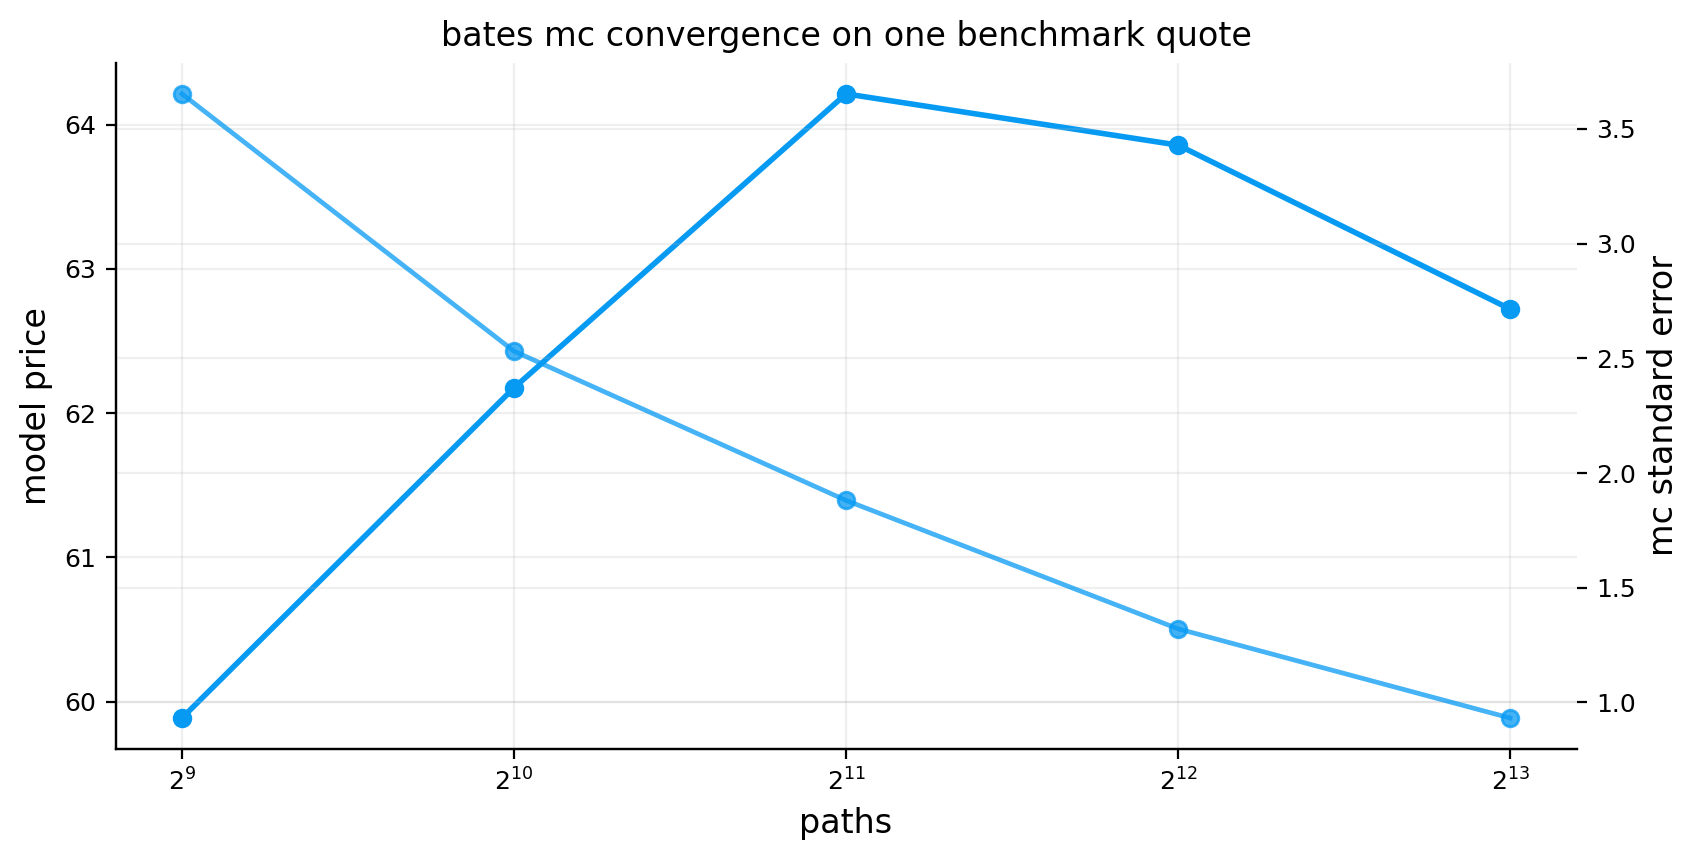

In [58]:
paths_grid = np.array([512, 1024, 2048, 4096, 8192])
q_conv = bates_fit.iloc[[int(np.argmin(np.abs(bates_fit["k"].to_numpy(dtype=float))) )]].copy()
bates_conv = []
for n_path in paths_grid:
    zc_s, zc_v, zc_j, uc_j = bates_shocks(int(n_path), n_step_mc, int(800 + n_path))
    px_c, se_c = bates_px_mc(
        q_conv["option_type"].eq("call").to_numpy(dtype=np.bool_),
        q_conv["forward"].to_numpy(dtype=float),
        q_conv["strike"].to_numpy(dtype=float),
        q_conv["tau"].to_numpy(dtype=float),
        q_conv["discount_factor"].to_numpy(dtype=float),
        p_bates[0], p_bates[1], p_bates[2], p_bates[3], p_bates[4], p_bates[5], p_bates[6], p_bates[7],
        mc_steps_per_year, zc_s, zc_v, zc_j, uc_j,
    )
    bates_conv.append({"paths": int(n_path), "price": float(px_c[0]), "mc_standard_error": float(se_c[0])})
bates_convergence = pd.DataFrame(bates_conv)
fig, ax1 = plt.subplots(figsize=(8.6, 4.4))
ax1.plot(bates_convergence["paths"], bates_convergence["price"], marker="o", lw=2.0)
ax1.set_xscale("log", base=2)
ax1.set_title("bates mc convergence on one benchmark quote")
ax1.set_xlabel("paths")
ax1.set_ylabel("model price")
ax2 = ax1.twinx()
ax2.plot(bates_convergence["paths"], bates_convergence["mc_standard_error"], marker="o", lw=1.7, alpha=0.75)
ax2.set_ylabel("mc standard error")
plt.tight_layout()
plt.show()

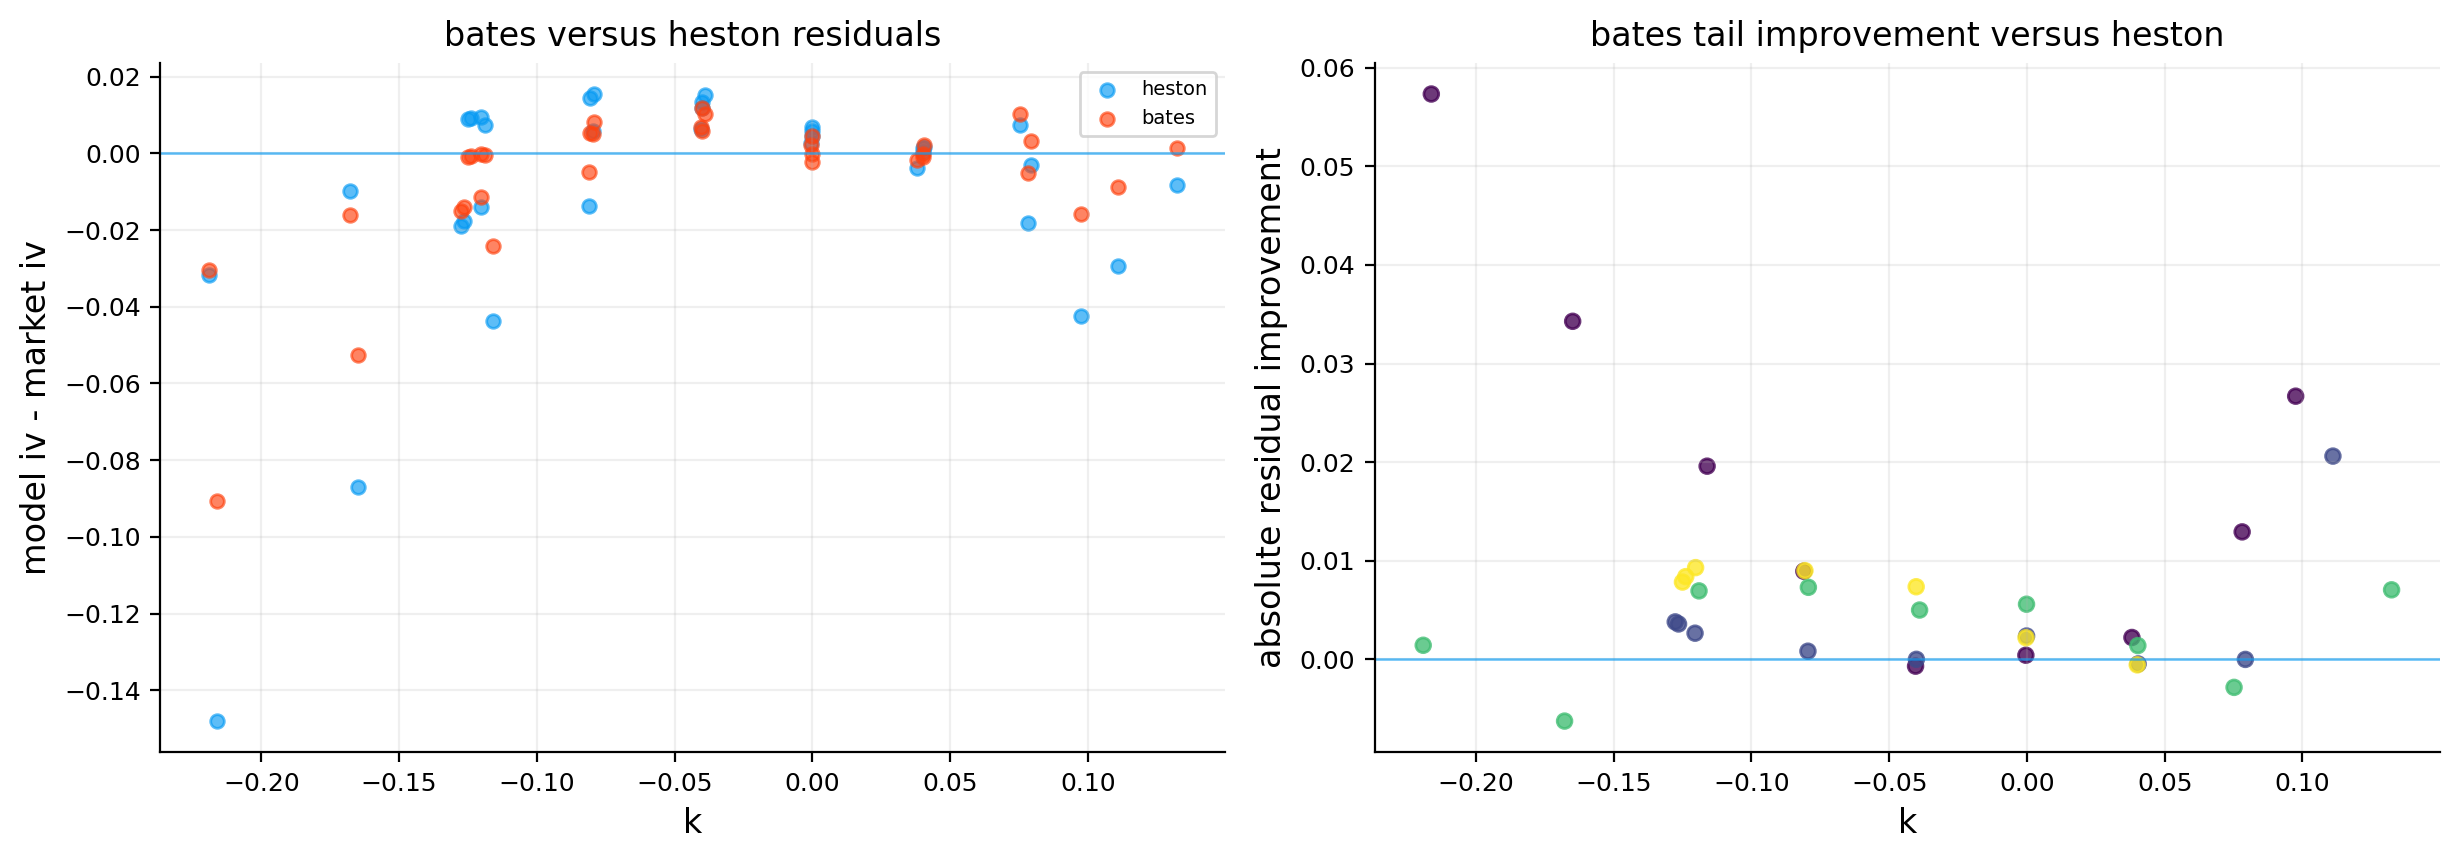

In [59]:
hb = heston_fit[["quote_id", "k", "dte_days", "iv_residual"]].rename(columns={"iv_residual": "heston"}).merge(bates_fit[["quote_id", "iv_residual"]].rename(columns={"iv_residual": "bates"}), on="quote_id", how="inner")
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
axes[0].scatter(hb["k"], hb["heston"], s=24, alpha=0.65, label="heston")
axes[0].scatter(hb["k"], hb["bates"], s=24, alpha=0.65, label="bates")
axes[0].axhline(0.0, lw=0.9, alpha=0.65)
axes[0].set_title("bates versus heston residuals")
axes[0].set_xlabel("k")
axes[0].set_ylabel("model iv - market iv")
axes[0].legend()
improve = np.abs(hb["heston"]) - np.abs(hb["bates"])
axes[1].scatter(hb["k"], improve, c=hb["dte_days"], cmap="viridis", s=28, alpha=0.78)
axes[1].axhline(0.0, lw=0.9, alpha=0.65)
axes[1].set_title("bates tail improvement versus heston")
axes[1].set_xlabel("k")
axes[1].set_ylabel("absolute residual improvement")
plt.tight_layout()
plt.show()

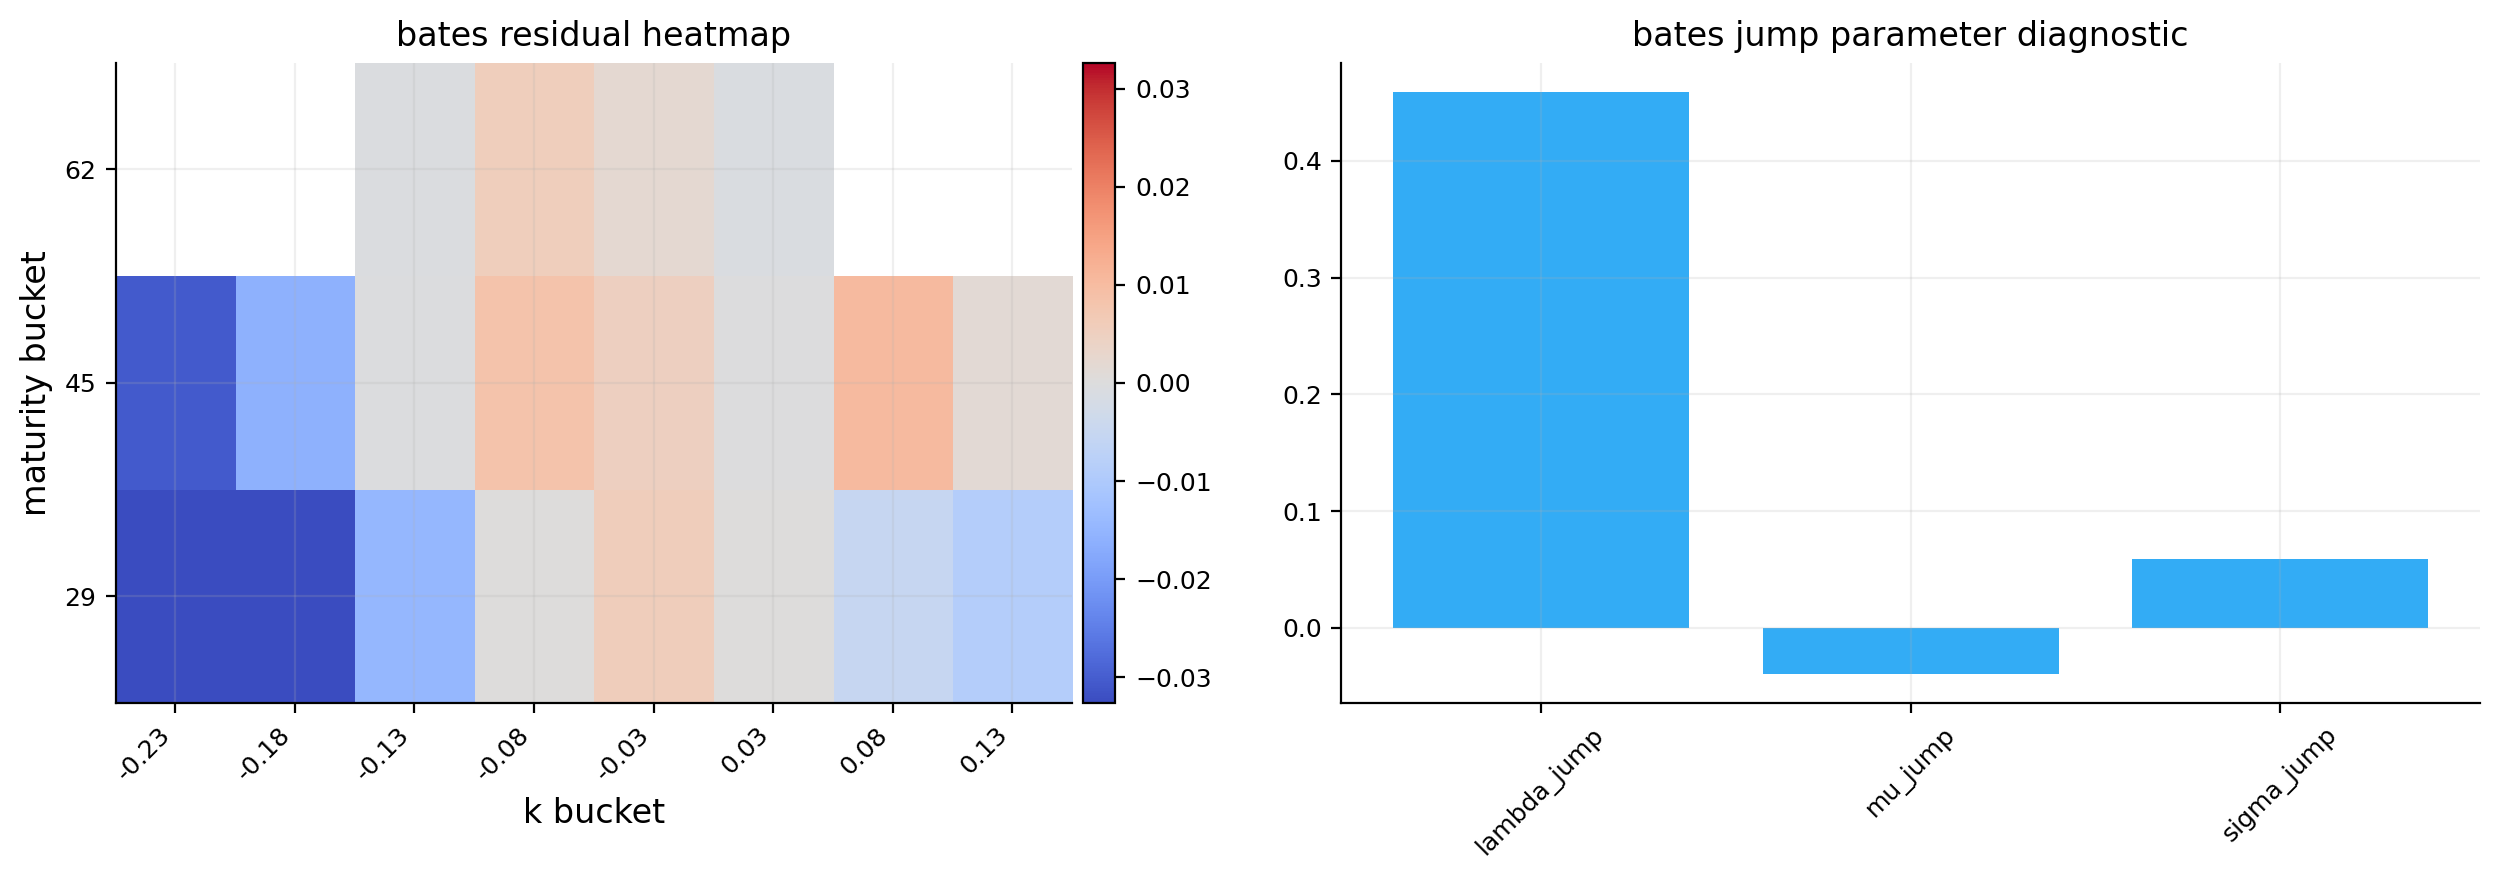

In [60]:
z = bates_fit.copy()
z["k_bin"] = pd.cut(z["k"], np.linspace(-0.26, 0.26, 11))
z["dte_bin"] = pd.cut(z["dte_days"], np.linspace(21.0, 135.0, 8))
h = z.pivot_table(index="dte_bin", columns="k_bin", values="iv_residual", aggfunc="median", observed=False)
lim = float(np.nanquantile(np.abs(h.to_numpy(dtype=float)), 0.90)) if np.isfinite(h.to_numpy(dtype=float)).any() else 0.03
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.5))
im = axes[0].imshow(h.to_numpy(dtype=float), origin="lower", aspect="auto", cmap="coolwarm", vmin=-lim, vmax=lim)
axes[0].set_title("bates residual heatmap")
axes[0].set_xlabel("k bucket")
axes[0].set_ylabel("maturity bucket")
axes[0].set_xticks(np.arange(h.shape[1]))
axes[0].set_xticklabels([f"{b.mid:.2f}" for b in h.columns], rotation=45, ha="right")
axes[0].set_yticks(np.arange(h.shape[0]))
axes[0].set_yticklabels([f"{b.mid:.0f}" for b in h.index])
fig.colorbar(im, ax=axes[0], pad=0.01)
p_jump = bates_params[["lambda_jump", "mu_jump", "sigma_jump"]].iloc[0]
axes[1].bar(p_jump.index, p_jump.values, alpha=0.82)
axes[1].set_title("bates jump parameter diagnostic")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [61]:
def svi_iv_at(q, p_table):
    vals = []
    for _, row in q.iterrows():
        p = p_table[p_table["expiry"].eq(row["expiry"])]
        if p.empty:
            vals.append(np.nan)
        else:
            pp = p.iloc[0]
            vals.append(float(svi_w(np.array([row["k"]], dtype=float), pp["a"], pp["b"], pp["rho"], pp["m"], pp["sigma"])[0]))
    return np.sqrt(np.maximum(np.asarray(vals, dtype=float), 1e-12) / q["tau"].to_numpy(dtype=float))


def ssvi_iv_at(q, p_frame, theta_table):
    x = q.merge(theta_table[["expiry", "theta_ssvi"]], on="expiry", how="left")
    p = p_frame.iloc[0]
    w = ssvi_w(x["k"].to_numpy(dtype=float), x["theta_ssvi"].to_numpy(dtype=float), p["rho"], p["eta"], p["gamma"])
    return np.sqrt(np.maximum(w, 1e-12) / x["tau"].to_numpy(dtype=float))


def sabr_iv_at(q, p_table, beta):
    vals = np.full(len(q), np.nan, dtype=float)
    for expiry, g in q.groupby("expiry"):
        p = p_table[p_table["expiry"].eq(expiry)]
        if p.empty:
            continue
        pp = p.iloc[0]
        loc = q.index.get_indexer(g.index)
        vals[loc] = sabr_iv_hagan(g["forward"].to_numpy(dtype=float), g["strike"].to_numpy(dtype=float), g["tau"].to_numpy(dtype=float), pp["alpha"], beta, pp["rho"], pp["nu"])
    return vals

In [62]:

def fit_row(model, q, target):
    wt = q["weight"] if "weight" in q.columns else pd.Series(1.0, index=q.index)
    e_px = q["model_price"] - q["mid"] if "model_price" in q.columns else pd.Series(np.nan, index=q.index)
    e_iv = q["model_iv"] - q["iv_mid"] if "model_iv" in q.columns else pd.Series(np.nan, index=q.index)
    tail = q["k"].abs() >= 0.14
    tail_count = int(tail.sum())
    return {
        "model": model,
        "target_type": target,
        "n_quotes": int(len(q)),
        "weighted_price_rmse": wrmse(e_px, wt),
        "weighted_iv_rmse": wrmse(e_iv, wt),
        "median_abs_iv_error": float(np.nanmedian(np.abs(e_iv))),
        "p90_abs_iv_error": float(np.nanquantile(np.abs(e_iv), 0.90)),
        "tail_count": tail_count,
        "tail_error": wrmse(e_iv[tail], wt[tail]) if tail_count >= 8 else np.nan,
    }


def eval_all_models(q):
    out = []
    z = q.copy()
    z["model_iv"] = svi_iv_at(z, svi_params)
    z["model_price"] = black76_price(z["option_type"].to_numpy(), z["forward"], z["strike"], z["tau"], z["model_iv"], z["discount_factor"])
    out.append(("svi", z.copy(), "total variance"))

    z = q.copy()
    z["model_iv"] = ssvi_iv_at(z, ssvi_params, theta_curve)
    z["model_price"] = black76_price(z["option_type"].to_numpy(), z["forward"], z["strike"], z["tau"], z["model_iv"], z["discount_factor"])
    out.append(("ssvi", z.copy(), "total variance"))

    z = q.copy()
    z["model_iv"] = sabr_iv_at(z, sabr_params_main, primary_beta)
    z["model_price"] = black76_price(z["option_type"].to_numpy(), z["forward"], z["strike"], z["tau"], z["model_iv"], z["discount_factor"])
    out.append(("sabr", z.copy(), "implied volatility"))

    z = q.copy()
    z["model_price"] = merton_px(z["option_type"].eq("call").to_numpy(dtype=np.bool_), z["forward"].to_numpy(dtype=float), z["strike"].to_numpy(dtype=float), z["tau"].to_numpy(dtype=float), z["discount_factor"].to_numpy(dtype=float), p_merton[0], p_merton[1], p_merton[2], p_merton[3], 60)
    z["model_iv"] = iv_from_px(z, "model_price")
    out.append(("merton", z.copy(), "price"))

    z = q.copy()
    px, se = heston_px_mc(z["option_type"].eq("call").to_numpy(dtype=np.bool_), z["forward"].to_numpy(dtype=float), z["strike"].to_numpy(dtype=float), z["tau"].to_numpy(dtype=float), z["discount_factor"].to_numpy(dtype=float), p_heston[0], p_heston[1], p_heston[2], p_heston[3], p_heston[4], mc_steps_per_year, z_s_final, z_v_final)
    z["model_price"] = px
    z["mc_standard_error"] = se
    z["model_iv"] = iv_from_px(z, "model_price")
    out.append(("heston", z.copy(), "simulation price"))

    z = q.copy()
    px, se = bates_px_mc(z["option_type"].eq("call").to_numpy(dtype=np.bool_), z["forward"].to_numpy(dtype=float), z["strike"].to_numpy(dtype=float), z["tau"].to_numpy(dtype=float), z["discount_factor"].to_numpy(dtype=float), p_bates[0], p_bates[1], p_bates[2], p_bates[3], p_bates[4], p_bates[5], p_bates[6], p_bates[7], mc_steps_per_year, zb_s_final, zb_v_final, zb_j_final, ub_j_final)
    z["model_price"] = px
    z["mc_standard_error"] = se
    z["model_iv"] = iv_from_px(z, "model_price")
    out.append(("bates", z.copy(), "simulation price"))
    return out


own_panel_fit = pd.DataFrame([
    fit_row("svi", svi_fit, "total variance"),
    fit_row("ssvi", ssvi_fit, "total variance"),
    fit_row("sabr", sabr_fit_main, "implied volatility"),
    fit_row("merton", merton_fit, "price"),
    fit_row("heston", heston_fit, "simulation price"),
    fit_row("bates", bates_fit, "simulation price"),
])
benchmark_fits = eval_all_models(q_benchmark)
benchmark_fit = pd.concat([fit.assign(model=name) for name, fit, target in benchmark_fits], ignore_index=True)
common_benchmark_fit = pd.DataFrame([fit_row(name, fit, target) for name, fit, target in benchmark_fits]).rename(columns={"n_quotes": "benchmark_quotes"})
common_benchmark_fit = common_benchmark_fit.merge(speed_summary[["model", "calibration_time"]] if "speed_summary" in globals() else pd.DataFrame(columns=["model", "calibration_time"]), on="model", how="left")
model_comparison = common_benchmark_fit.copy()
display(own_panel_fit)
display(common_benchmark_fit)


,model,target_type,n_quotes,weighted_price_rmse,weighted_iv_rmse,median_abs_iv_error,p90_abs_iv_error,tail_count,tail_error
0,svi,total variance,3873,0.263015,0.000763,0.000343,0.001022,428,0.001495
1,ssvi,total variance,3873,2.433024,0.008318,0.003846,0.016519,428,0.029566
2,sabr,implied volatility,3873,0.490227,0.002502,0.000990,0.007092,428,0.008707
3,merton,price,54,3.326638,0.009212,0.004419,0.032250,8,0.013282
4,heston,simulation price,34,3.863250,0.014869,0.009626,0.039230,4,NaN
5,bates,simulation price,34,2.093534,0.009049,0.005343,0.021700,4,NaN


,model,target_type,benchmark_quotes,weighted_price_rmse,weighted_iv_rmse,median_abs_iv_error,p90_abs_iv_error,tail_count,tail_error,calibration_time
0,svi,total variance,54,0.185691,0.000824,0.000542,0.001183,8,0.000860,NaN
1,ssvi,total variance,54,2.274493,0.008057,0.005736,0.027053,8,0.019424,NaN
2,sabr,implied volatility,54,0.365040,0.002710,0.001111,0.010382,8,0.006495,NaN
3,merton,price,54,3.326638,0.009212,0.004419,0.032250,8,0.013282,NaN
4,heston,simulation price,54,7.489972,0.014368,0.013268,0.026449,8,0.028539,NaN
5,bates,simulation price,54,2.885128,0.007572,0.005872,0.015908,8,0.016230,NaN


In [63]:
speed_summary = pd.DataFrame([
    {"model": "svi", "compile_warmup_time": svi_compile_time, "calibration_time": float(svi_diag["calibration_time"].sum()), "objective_evaluations": int(svi_diag["objective_evaluations"].fillna(0).sum()), "quotes_per_second": len(svi_fit) / max(float(svi_diag["calibration_time"].sum()), 1e-9)},
    {"model": "ssvi", "compile_warmup_time": ssvi_compile_time, "calibration_time": float(ssvi_diag.loc[0, "calibration_time"]), "objective_evaluations": int(ssvi_diag.loc[0, "objective_evaluations"]), "quotes_per_second": len(ssvi_fit) / max(float(ssvi_diag.loc[0, "calibration_time"]), 1e-9)},
    {"model": "sabr", "compile_warmup_time": sabr_compile_time, "calibration_time": float(sabr_diag[sabr_diag["beta"].eq(primary_beta)]["calibration_time"].sum()), "objective_evaluations": int(sabr_diag[sabr_diag["beta"].eq(primary_beta)]["objective_evaluations"].sum()), "quotes_per_second": len(sabr_fit_main) / max(float(sabr_diag[sabr_diag["beta"].eq(primary_beta)]["calibration_time"].sum()), 1e-9)},
    {"model": "merton", "compile_warmup_time": merton_compile_time, "calibration_time": float(merton_diag.loc[0, "calibration_time"]), "objective_evaluations": int(merton_diag.loc[0, "objective_evaluations"]), "quotes_per_second": len(merton_fit) / max(float(merton_diag.loc[0, "calibration_time"]), 1e-9)},
    {"model": "heston", "compile_warmup_time": heston_compile_time, "calibration_time": float(heston_diag.loc[0, "calibration_time"]), "objective_evaluations": int(heston_diag.loc[0, "objective_evaluations"]), "quotes_per_second": len(heston_fit) / max(float(heston_diag.loc[0, "calibration_time"]), 1e-9)},
    {"model": "bates", "compile_warmup_time": bates_compile_time, "calibration_time": float(bates_diag.loc[0, "calibration_time"]), "objective_evaluations": int(bates_diag.loc[0, "objective_evaluations"]), "quotes_per_second": len(bates_fit) / max(float(bates_diag.loc[0, "calibration_time"]), 1e-9)},
])
display(speed_summary)
model_comparison = common_benchmark_fit.drop(columns=["calibration_time"], errors="ignore").merge(speed_summary[["model", "calibration_time"]], on="model", how="left")


,model,compile_warmup_time,calibration_time,objective_evaluations,quotes_per_second
0,svi,7.915055,7.637519,3024,507.101815
1,ssvi,0.648623,0.056061,9,"69,085.706954"
2,sabr,1.633890,0.468387,339,"8,268.794535"
3,merton,3.336702,0.051038,23,"1,058.043482"
4,heston,3.486851,3.417353,177,9.949221
5,bates,3.498584,3.707852,174,9.169731


In [64]:
model_state = pd.DataFrame([
    {"model": "svi", "success": bool(svi_diag["success"].mean() > 0.85), "bound_warning": bool(svi_diag["parameter_at_bound"].mean() > 0.25), "suspicious_parameter_flag": bool(svi_diag["wing_warning"].mean() > 0.10), "mc_warning": False, "reason": "slice fits"},
    {"model": "ssvi", "success": bool(ssvi_diag.loc[0, "success"]), "bound_warning": bool(ssvi_diag.loc[0, "parameter_at_bound"]), "suspicious_parameter_flag": bool(ssvi_diag.loc[0, "weighted_rmse_iv"] > 1.75 * model_comparison.loc[model_comparison["model"].eq("svi"), "weighted_iv_rmse"].iloc[0]), "mc_warning": False, "reason": "global surface discipline"},
    {"model": "sabr", "success": bool(sabr_diag[sabr_diag["beta"].eq(primary_beta)]["success"].mean() > 0.85), "bound_warning": bool(sabr_diag[sabr_diag["beta"].eq(primary_beta)][["rho_bound_flag", "nu_bound_flag"]].mean().max() > 0.30), "suspicious_parameter_flag": False, "mc_warning": False, "reason": f"beta {primary_beta:.1f}"},
    {"model": "merton", "success": bool(merton_diag.loc[0, "success"]), "bound_warning": bool(merton_params.loc[0, "parameter_at_bound"]), "suspicious_parameter_flag": bool(merton_params.loc[0, "lambda_jump"] > 5.0), "mc_warning": False, "reason": "diagnostic only"},
    {"model": "heston", "success": bool(heston_diag.loc[0, "success"]), "bound_warning": bool(heston_params.loc[0, "parameter_at_bound"]), "suspicious_parameter_flag": bool(heston_diag.loc[0, "feller_warning"]), "mc_warning": bool(heston_diag.loc[0, "median_mc_standard_error"] > np.nanmedian(heston_fit["eps_px"])), "reason": "simulation price fit"},
    {"model": "bates", "success": bool(bates_diag.loc[0, "success"]), "bound_warning": bool(bates_params.loc[0, "parameter_at_bound"]), "suspicious_parameter_flag": bool(bates_params.loc[0, "lambda_jump"] > 5.5), "mc_warning": bool(bates_diag.loc[0, "median_mc_standard_error"] > np.nanmedian(bates_fit["eps_px"])), "reason": "diagnostic only"},
])
display(model_state)

,model,success,bound_warning,suspicious_parameter_flag,mc_warning,reason
0,svi,True,False,False,False,slice fits
1,ssvi,True,False,True,False,global surface discipline
2,sabr,True,False,False,False,beta 0.5
3,merton,True,False,False,False,diagnostic only
4,heston,True,False,True,True,simulation price fit
5,bates,True,False,False,True,diagnostic only


In [65]:
fit_iv = pd.concat([
    svi_fit[["quote_id", "k", "dte_days", "model_iv"]].assign(model="svi"),
    ssvi_fit[["quote_id", "k", "dte_days", "model_iv"]].assign(model="ssvi"),
    sabr_fit_main[["quote_id", "k", "dte_days", "model_iv"]].assign(model="sabr"),
], ignore_index=True)
wide_iv = fit_iv.pivot_table(index="quote_id", columns="model", values="model_iv")
wide_iv["model_iv_std"] = wide_iv.std(axis=1)
uncertainty_summary = pd.DataFrame([{
    "median_quote_iv_uncertainty": float(np.nanmedian(q0["eps_iv"])),
    "median_quote_price_uncertainty": float(np.nanmedian(q0["eps_px"])),
    "median_cross_model_iv_disagreement": float(np.nanmedian(wide_iv["model_iv_std"])),
    "median_heston_mc_standard_error": float(np.nanmedian(heston_fit["mc_standard_error"])),
    "median_bates_mc_standard_error": float(np.nanmedian(bates_fit["mc_standard_error"])),
    "bootstrap_price_uncertainty": np.nan,
}])
display(uncertainty_summary)

,median_quote_iv_uncertainty,median_quote_price_uncertainty,median_cross_model_iv_disagreement,median_heston_mc_standard_error,median_bates_mc_standard_error,bootstrap_price_uncertainty
0,0.002500,0.995061,0.002620,0.454690,0.474161,NaN


In [66]:

svi_err = float(model_comparison.loc[model_comparison["model"].eq("svi"), "weighted_iv_rmse"].iloc[0])
ssvi_err = float(model_comparison.loc[model_comparison["model"].eq("ssvi"), "weighted_iv_rmse"].iloc[0])
sabr_err = float(model_comparison.loc[model_comparison["model"].eq("sabr"), "weighted_iv_rmse"].iloc[0])
heston_err = float(model_comparison.loc[model_comparison["model"].eq("heston"), "weighted_iv_rmse"].iloc[0])
sabr_diag_main = sabr_diag[sabr_diag["beta"].eq(primary_beta)].copy()
sabr_success_rate = float(sabr_diag_main["success"].mean())
rho_bound_share = float(sabr_diag_main["rho_bound_flag"].mean())
nu_bound_share = float(sabr_diag_main["nu_bound_flag"].mean())
ssvi_ok_for_trade = bool((ssvi_err <= 0.004) or (ssvi_err <= 3.0 * sabr_err))
sabr_ok_for_trade = bool((sabr_err <= 0.0025) and (sabr_success_rate > 0.85) and (rho_bound_share < 0.20) and (nu_bound_share < 0.20))
sabr_in_signal = bool((sabr_success_rate > 0.85) and (rho_bound_share < 0.20) and (nu_bound_share < 0.20))
heston_ok_for_trade = bool(
    heston_diag.loc[0, "success"]
    and heston_err <= 0.0060
    and not bool(heston_params.loc[0, "parameter_at_bound"])
    and float(heston_fit["mc_standard_error"].median()) < 0.50 * float(np.nanmedian(np.abs(heston_fit["price_residual"])))
)
model_decision = pd.DataFrame([
    {"model": "svi", "signal_decision": "candidate", "reason": "holdout signal core"},
    {"model": "ssvi", "signal_decision": "candidate" if ssvi_ok_for_trade else "diagnostic", "reason": "surface discipline model"},
    {"model": "sabr", "signal_decision": "candidate" if sabr_ok_for_trade else "diagnostic" if not sabr_in_signal else "candidate with fit warning", "reason": f"abs err={sabr_err:.4f}, success={sabr_success_rate:.2f}"},
    {"model": "heston", "signal_decision": "candidate" if heston_ok_for_trade else "diagnostic", "reason": "mc se, bounds, and residual checks"},
    {"model": "merton", "signal_decision": "no signal", "reason": "diagnostic jump bridge only"},
    {"model": "bates", "signal_decision": "no signal", "reason": "diagnostic stochastic-vol jump model only"},
])
display(model_decision)


,model,signal_decision,reason
0,svi,candidate,holdout signal core
1,ssvi,candidate,surface discipline model
2,sabr,candidate with fit warning,"abs err=0.0027, success=1.00"
3,heston,diagnostic,"mc se, bounds, and residual checks"
4,merton,no signal,diagnostic jump bridge only
5,bates,no signal,diagnostic stochastic-vol jump model only


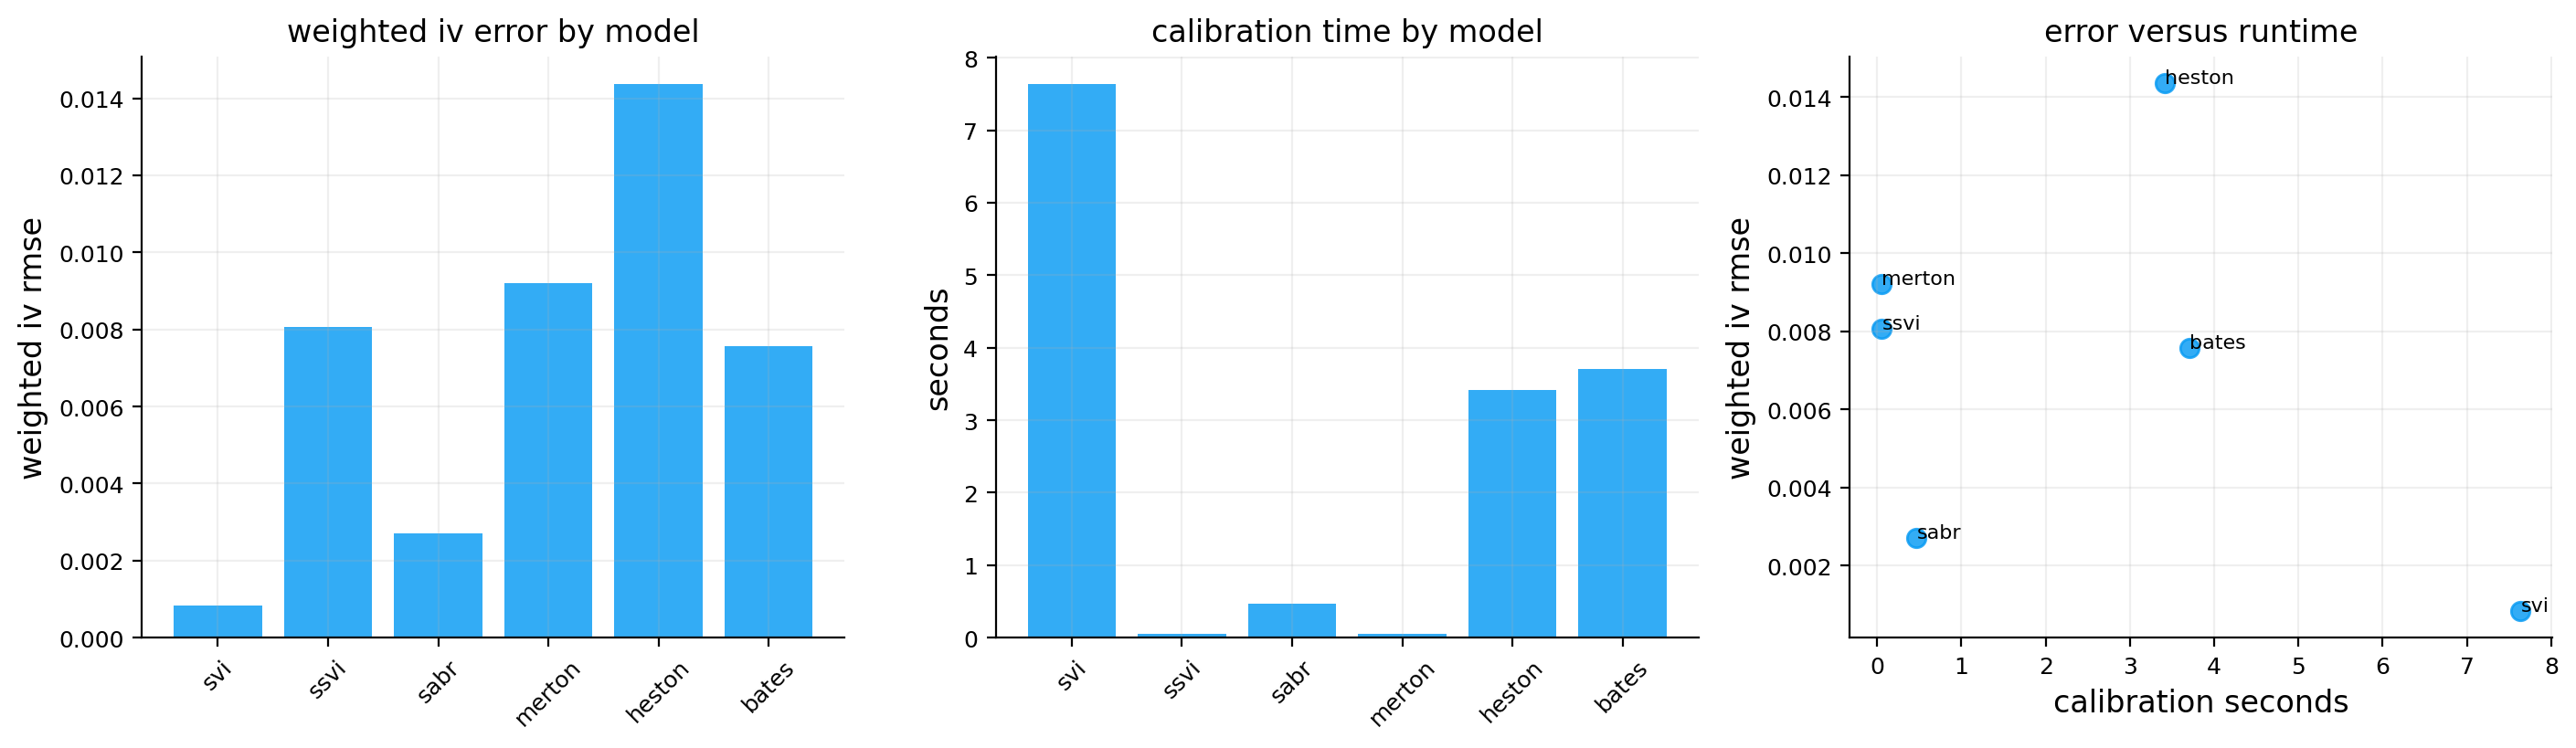

In [67]:
plot_q = model_comparison.copy()
if "calibration_time" not in plot_q.columns:
    plot_q = plot_q.merge(speed_summary[["model", "calibration_time"]], on="model", how="left")
else:
    time_map = speed_summary.set_index("model")["calibration_time"]
    plot_q["calibration_time"] = plot_q["calibration_time"].fillna(plot_q["model"].map(time_map))
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.2))
axes[0].bar(plot_q["model"], plot_q["weighted_iv_rmse"], alpha=0.82)
axes[0].set_title("weighted iv error by model")
axes[0].set_ylabel("weighted iv rmse")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(plot_q["model"], plot_q["calibration_time"], alpha=0.82)
axes[1].set_title("calibration time by model")
axes[1].set_ylabel("seconds")
axes[1].tick_params(axis="x", rotation=45)
axes[2].scatter(plot_q["calibration_time"], plot_q["weighted_iv_rmse"], s=54, alpha=0.82)
for _, row in plot_q.iterrows():
    axes[2].annotate(row["model"], (row["calibration_time"], row["weighted_iv_rmse"]), fontsize=8)
axes[2].set_title("error versus runtime")
axes[2].set_xlabel("calibration seconds")
axes[2].set_ylabel("weighted iv rmse")
plt.tight_layout()
plt.show()

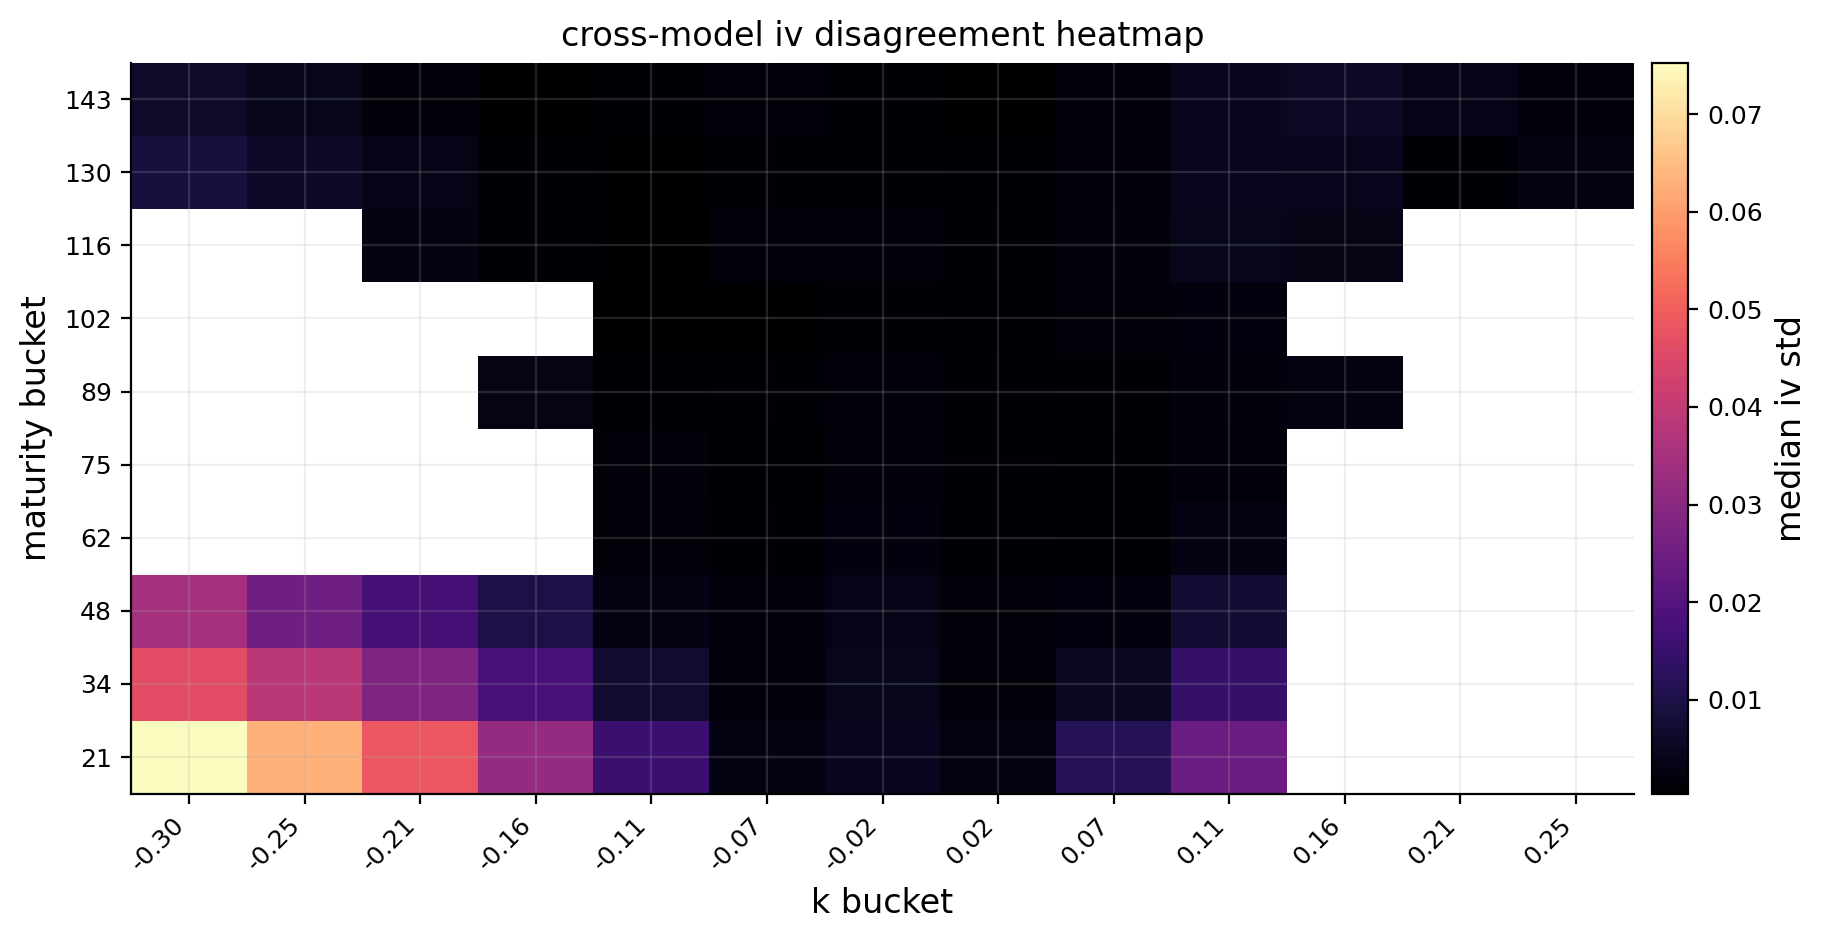

In [68]:
z = fit_iv.merge(wide_iv[["model_iv_std"]], left_on="quote_id", right_index=True, how="left")
z["k_bin"] = pd.cut(z["k"], np.linspace(-max_abs_k, max_abs_k, 15))
z["dte_bin"] = pd.cut(z["dte_days"], np.linspace(min_dte, max_dte, 11))
h = z.drop_duplicates("quote_id").pivot_table(index="dte_bin", columns="k_bin", values="model_iv_std", aggfunc="median", observed=False)
fig, ax = plt.subplots(figsize=(9.8, 4.8))
im = ax.imshow(h.to_numpy(dtype=float), origin="lower", aspect="auto", cmap="magma")
ax.set_title("cross-model iv disagreement heatmap")
ax.set_xlabel("k bucket")
ax.set_ylabel("maturity bucket")
ax.set_xticks(np.arange(h.shape[1]))
ax.set_xticklabels([f"{b.mid:.2f}" for b in h.columns], rotation=45, ha="right")
ax.set_yticks(np.arange(h.shape[0]))
ax.set_yticklabels([f"{b.mid:.0f}" for b in h.index])
fig.colorbar(im, ax=ax, pad=0.01, label="median iv std")
plt.tight_layout()
plt.show()

In [69]:

def holdout_split(q):
    q_anchor = choose_k_grid_quotes(q, target_dtes_px, k_targets_px, max_expiries=6, min_strikes=8, require_buckets=False, label="anchor")
    if q_anchor.empty or q_anchor.groupby("expiry").size().ge(min_quotes_per_expiry).sum() < 3:
        q_anchor = choose_k_grid_quotes(q, target_dtes_px, k_targets_anchor, max_expiries=6, min_strikes=6, require_buckets=False, label="anchor")
    rest = q[~q["quote_id"].isin(q_anchor["quote_id"])].copy()
    q_holdout = choose_k_grid_quotes(rest, target_dtes_px, k_targets_trade, max_expiries=6, min_strikes=5, require_buckets=False, label="holdout")
    if q_holdout.empty:
        keep = q_anchor["quote_id"].unique()
        q_holdout = q[~q["quote_id"].isin(keep)].sort_values(["expiry", "relative_spread", "k"]).groupby("expiry", sort=True).head(6).reset_index(drop=True)
    return q_anchor.reset_index(drop=True), q_holdout.reset_index(drop=True)


q_anchor0, q_trade = holdout_split(q0)
signal_svi_params, _, signal_svi_diag = fit_svi(q_anchor0)
p_signal_ssvi, theta_signal, ok_signal_ssvi, _, _, _, _ = fit_ssvi(q_anchor0)
signal_ssvi_params = pd.DataFrame([{"rho": p_signal_ssvi[0], "eta": p_signal_ssvi[1], "gamma": p_signal_ssvi[2]}])
signal_sabr_params, _, signal_sabr_diag = fit_sabr(q_anchor0, primary_beta)
q_trade["trade_id"] = np.arange(len(q_trade), dtype=int)
fair_values = q_trade[["trade_id", "quote_id", "date", "expiry", "option_type", "strike", "k", "dte_days", "forward", "discount_factor", "tau", "mid", "bid", "ask", "iv_mid", "delta", "vega", "half_spread", "expected_exit_half_spread", "eps_px", "eps_iv", "calib_scale_px", "weight", "relative_spread", "contract_id"]].copy()
fair_values["svi_iv"] = svi_iv_at(q_trade, signal_svi_params)
fair_values["svi_price"] = black76_price(fair_values["option_type"].to_numpy(), fair_values["forward"], fair_values["strike"], fair_values["tau"], fair_values["svi_iv"], fair_values["discount_factor"])
if ssvi_ok_for_trade:
    fair_values["ssvi_iv"] = ssvi_iv_at(q_trade, signal_ssvi_params, theta_signal)
    fair_values["ssvi_price"] = black76_price(fair_values["option_type"].to_numpy(), fair_values["forward"], fair_values["strike"], fair_values["tau"], fair_values["ssvi_iv"], fair_values["discount_factor"])
if sabr_in_signal:
    fair_values["sabr_iv"] = sabr_iv_at(q_trade, signal_sabr_params, primary_beta)
    fair_values["sabr_price"] = black76_price(fair_values["option_type"].to_numpy(), fair_values["forward"], fair_values["strike"], fair_values["tau"], fair_values["sabr_iv"], fair_values["discount_factor"])
if heston_ok_for_trade:
    px_h, se_h = heston_px_mc(q_trade["option_type"].eq("call").to_numpy(dtype=np.bool_), q_trade["forward"].to_numpy(dtype=float), q_trade["strike"].to_numpy(dtype=float), q_trade["tau"].to_numpy(dtype=float), q_trade["discount_factor"].to_numpy(dtype=float), p_heston[0], p_heston[1], p_heston[2], p_heston[3], p_heston[4], mc_steps_per_year, z_s_final, z_v_final)
    fair_values["heston_price"] = px_h
    fair_values["heston_mc_standard_error"] = se_h
    fair_values["heston_iv"] = iv_from_px(fair_values.rename(columns={"heston_price": "model_price"}), "model_price")
display(pd.DataFrame([{"anchor_quotes": len(q_anchor0), "holdout_quotes_scored": len(q_trade), "anchor_expiries": q_anchor0["expiry"].nunique(), "holdout_expiries": q_trade["expiry"].nunique()}]))


,anchor_quotes,holdout_quotes_scored,anchor_expiries,holdout_expiries
0,54,60,6,6


In [70]:
models_for_trade = ["svi"]
if sabr_in_signal:
    models_for_trade.append("sabr")
if ssvi_ok_for_trade:
    models_for_trade.append("ssvi")
if heston_ok_for_trade:
    models_for_trade.append("heston")
err_map = model_comparison.set_index("model")["weighted_iv_rmse"].to_dict()
model_wt = {name: 1.0 / max(err_map.get(name, svi_err), 1e-4) ** 2 for name in models_for_trade}
wt_sum = sum(model_wt.values())
for name in model_wt:
    model_wt[name] /= max(wt_sum, 1e-12)
if "svi" in model_wt and model_wt["svi"] > 0.70:
    extra = model_wt["svi"] - 0.70
    model_wt["svi"] = 0.70
    receivers = [m for m in model_wt if m != "svi"]
    recv_sum = sum(model_wt[m] for m in receivers)
    for m in receivers:
        model_wt[m] += extra * model_wt[m] / max(recv_sum, 1e-12)
if "ssvi" in model_wt and model_wt["ssvi"] > 0.20:
    extra = model_wt["ssvi"] - 0.20
    model_wt["ssvi"] = 0.20
    receivers = [m for m in model_wt if m != "ssvi"]
    recv_sum = sum(model_wt[m] for m in receivers)
    for m in receivers:
        model_wt[m] += extra * model_wt[m] / max(recv_sum, 1e-12)
if "sabr" in model_wt and model_wt["sabr"] < 0.20 and len(model_wt) > 1:
    need = 0.20 - model_wt["sabr"]
    donors = sorted([m for m in model_wt if m != "sabr"], key=lambda m: model_wt[m], reverse=True)
    for m in donors:
        take = min(need, max(0.0, model_wt[m] - 0.02))
        model_wt[m] -= take
        model_wt["sabr"] += take
        need -= take
        if need <= 1e-12:
            break
wt_sum = sum(model_wt.values())
for name in model_wt:
    model_wt[name] /= max(wt_sum, 1e-12)
px_cols = [f"{name}_price" for name in models_for_trade if f"{name}_price" in fair_values.columns]
iv_cols = [f"{name}_iv" for name in models_for_trade if f"{name}_iv" in fair_values.columns]
fair_values["ensemble_price"] = 0.0
fair_values["ensemble_iv"] = 0.0
for name in models_for_trade:
    if f"{name}_price" in fair_values.columns:
        fair_values["ensemble_price"] += model_wt[name] * fair_values[f"{name}_price"]
    if f"{name}_iv" in fair_values.columns:
        fair_values["ensemble_iv"] += model_wt[name] * fair_values[f"{name}_iv"]
fair_values["model_spread"] = fair_values[px_cols].std(axis=1).fillna(0.0)
fair_values["mc_error"] = fair_values["heston_mc_standard_error"] if "heston_mc_standard_error" in fair_values.columns else 0.0
display(pd.DataFrame({"model": list(model_wt.keys()), "ensemble_weight": list(model_wt.values())}))

,model,ensemble_weight
0,svi,0.700000
1,sabr,0.269513
2,ssvi,0.030487


In [71]:
bootstrap_runs = 2
def bootstrap_px(q_base, q_use):
    rows = []
    for run in range(bootstrap_runs):
        b = q_base.copy()
        b["iv_mid"] = np.clip(b["iv_mid"].to_numpy(dtype=float) + rng.normal(size=len(b)) * b["eps_iv"].to_numpy(dtype=float), 0.03, 2.50)
        b["total_var"] = b["iv_mid"] ** 2 * b["tau"]
        try:
            p_svi, _, _ = fit_svi(b)
            temp = q_use[["trade_id", "option_type", "forward", "strike", "tau", "discount_factor"]].copy()
            temp["svi_iv"] = svi_iv_at(q_use, p_svi)
            temp["svi_price"] = black76_price(temp["option_type"].to_numpy(), temp["forward"], temp["strike"], temp["tau"], temp["svi_iv"], temp["discount_factor"])
            px = model_wt.get("svi", 0.0) * temp["svi_price"].to_numpy(dtype=float)
            used = model_wt.get("svi", 0.0)
            if ssvi_ok_for_trade:
                p, th, _, _, _, _, _ = fit_ssvi(b)
                pf = pd.DataFrame([{"rho": p[0], "eta": p[1], "gamma": p[2]}])
                temp["ssvi_iv"] = ssvi_iv_at(q_use, pf, th)
                temp["ssvi_price"] = black76_price(temp["option_type"].to_numpy(), temp["forward"], temp["strike"], temp["tau"], temp["ssvi_iv"], temp["discount_factor"])
                px += model_wt.get("ssvi", 0.0) * temp["ssvi_price"].to_numpy(dtype=float)
                used += model_wt.get("ssvi", 0.0)
            if sabr_in_signal:
                p_sabr, _, _ = fit_sabr(b, primary_beta)
                temp["sabr_iv"] = sabr_iv_at(q_use, p_sabr, primary_beta)
                temp["sabr_price"] = black76_price(temp["option_type"].to_numpy(), temp["forward"], temp["strike"], temp["tau"], temp["sabr_iv"], temp["discount_factor"])
                px += model_wt.get("sabr", 0.0) * temp["sabr_price"].to_numpy(dtype=float)
                used += model_wt.get("sabr", 0.0)
            temp["bootstrap_price"] = px / max(used, 1e-12)
            temp["run"] = run
            rows.append(temp[["trade_id", "run", "bootstrap_price"]])
        except Exception:
            rows.append(pd.DataFrame({"trade_id": q_use["trade_id"], "run": run, "bootstrap_price": np.nan}))
    return pd.concat(rows, ignore_index=True)


boot_px = bootstrap_px(q_anchor0, q_trade)
boot_sig = boot_px.groupby("trade_id")["bootstrap_price"].std().rename("fit_error").reset_index()
fair_values = fair_values.merge(boot_sig, on="trade_id", how="left")
fit_err_med = float(np.nanmedian(fair_values["fit_error"])) if fair_values["fit_error"].notna().any() else 0.0
fair_values["fit_error"] = fair_values["fit_error"].fillna(fit_err_med).clip(lower=0.0)
uncertainty_summary.loc[0, "bootstrap_price_uncertainty"] = float(np.nanmedian(fair_values["fit_error"]))
display(uncertainty_summary)

,median_quote_iv_uncertainty,median_quote_price_uncertainty,median_cross_model_iv_disagreement,median_heston_mc_standard_error,median_bates_mc_standard_error,bootstrap_price_uncertainty
0,0.002500,0.995061,0.002620,0.454690,0.474161,0.283468


In [72]:

fair_values["price_residual"] = fair_values["ensemble_price"] - fair_values["mid"]
fair_values["iv_residual"] = fair_values["ensemble_iv"] - fair_values["iv_mid"]
fair_values["spread_residual"] = fair_values["price_residual"] / fair_values["half_spread"].replace(0, np.nan)
fair_values["hedge_buffer"] = 0.0001 * np.abs(fair_values["delta"].fillna(0.0)) * fair_values["forward"] + 0.10 * fair_values["half_spread"]
fair_values["total_error"] = (
    1.0 * fair_values["half_spread"]
    + 0.5 * fair_values["expected_exit_half_spread"].fillna(fair_values["half_spread"])
    + 0.5 * fair_values["model_spread"].fillna(0.0)
    + 0.5 * fair_values["fit_error"].fillna(0.0)
    + 0.5 * fair_values["mc_error"].fillna(0.0)
    + fair_values["hedge_buffer"].fillna(0.0)
).clip(lower=0.02)
fair_values["z_residual"] = fair_values["price_residual"] / fair_values["total_error"].replace(0, np.nan)
fair_values["strict_candidate"] = fair_values["z_residual"].abs() > 1.0
fair_values["watchlist_candidate"] = fair_values["z_residual"].abs() > 0.5
fair_values["candidate"] = fair_values["strict_candidate"]
fair_values["side"] = np.where(fair_values["price_residual"] > 0.0, "cheap", "rich")
fair_values["reason"] = np.select(
    [
        fair_values["strict_candidate"],
        fair_values["watchlist_candidate"],
        fair_values["price_residual"].abs() <= fair_values["half_spread"],
        fair_values["price_residual"].abs() <= fair_values["half_spread"] + 0.5 * fair_values["model_spread"],
    ],
    ["strict", "watchlist", "inside entry spread", "inside model disagreement"],
    default="inside fit or hedge buffer",
)
candidate_summary = pd.concat([
    fair_values.groupby(["strict_candidate", "side"]).size().rename("count").reset_index().assign(candidate_type="strict"),
    fair_values.groupby(["watchlist_candidate", "side"]).size().rename("count").reset_index().assign(candidate_type="watchlist"),
], ignore_index=True)
top_candidates = fair_values[fair_values["watchlist_candidate"]].copy().sort_values("z_residual", key=lambda s: s.abs(), ascending=False)
reason_counts = fair_values["reason"].value_counts().rename_axis("reason").reset_index(name="count")
display(candidate_summary)
display(reason_counts)
display(top_candidates[["expiry", "option_type", "strike", "k", "dte_days", "mid", "ensemble_price", "price_residual", "total_error", "z_residual", "side", "reason"]].head(12))


,strict_candidate,side,count,candidate_type,watchlist_candidate
0,False,cheap,41,strict,NaN
1,False,rich,19,strict,NaN
2,NaN,cheap,39,watchlist,False
3,NaN,rich,18,watchlist,False
4,NaN,cheap,2,watchlist,True
5,NaN,rich,1,watchlist,True


,reason,count
0,inside entry spread,36
1,inside model disagreement,20
2,watchlist,3
3,inside fit or hedge buffer,1


,expiry,option_type,strike,k,dte_days,mid,ensemble_price,price_residual,total_error,z_residual,side,reason
29,2024-02-05,call,"5,200.000000",0.094589,46.333333,0.925000,1.266565,0.341565,0.525455,0.650037,cheap,watchlist
9,2024-01-11,call,"5,000.000000",0.058306,21.333333,0.950000,1.201475,0.251475,0.439296,0.572451,cheap,watchlist
5,2024-01-11,call,"4,810.000000",0.019565,21.333333,17.100000,16.051775,-1.048225,1.995406,-0.525319,rich,watchlist


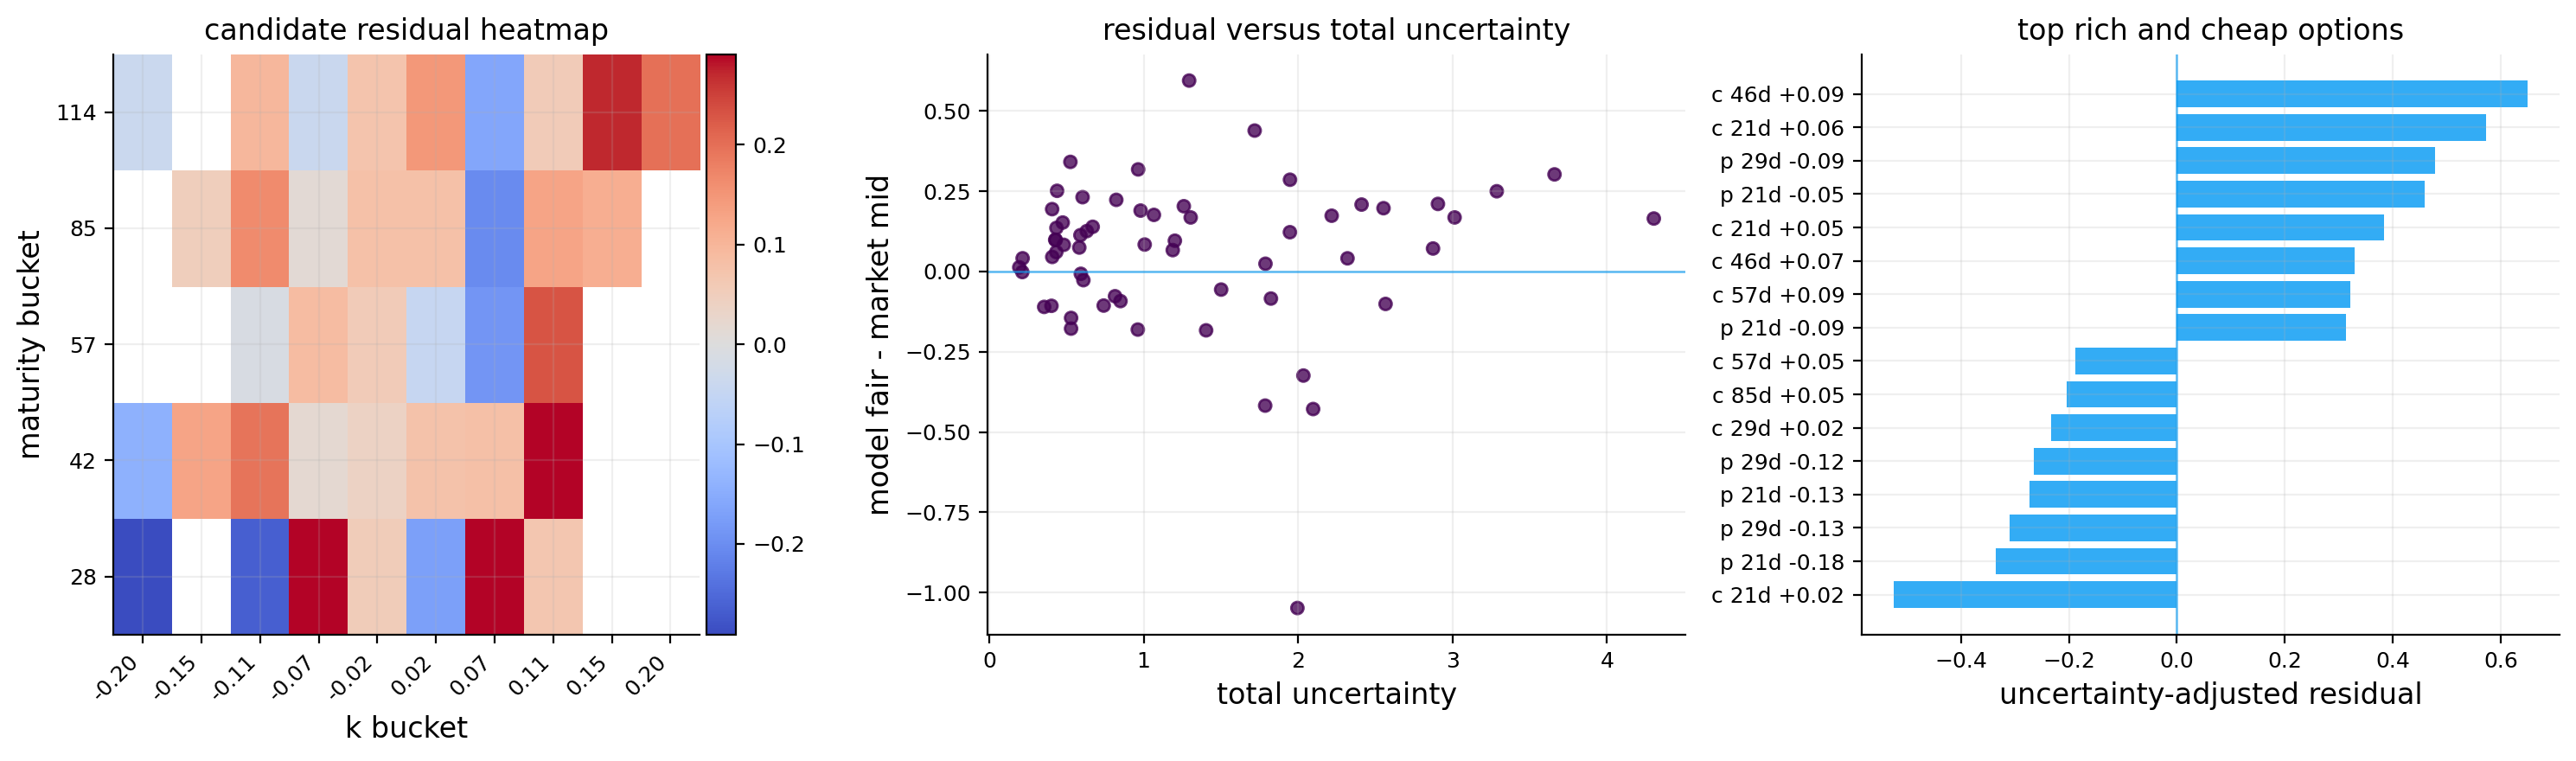

In [73]:
z = fair_values.copy()
z["k_bin"] = pd.cut(z["k"], np.linspace(-0.26, 0.26, 13))
z["dte_bin"] = pd.cut(z["dte_days"], np.linspace(21.0, 135.0, 9))
h = z.pivot_table(index="dte_bin", columns="k_bin", values="z_residual", aggfunc="median", observed=False)
lim = float(np.nanquantile(np.abs(h.to_numpy(dtype=float)), 0.90)) if np.isfinite(h.to_numpy(dtype=float)).any() else 2.0
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.5))
im = axes[0].imshow(h.to_numpy(dtype=float), origin="lower", aspect="auto", cmap="coolwarm", vmin=-lim, vmax=lim)
axes[0].set_title("candidate residual heatmap")
axes[0].set_xlabel("k bucket")
axes[0].set_ylabel("maturity bucket")
axes[0].set_xticks(np.arange(h.shape[1]))
axes[0].set_xticklabels([f"{b.mid:.2f}" for b in h.columns], rotation=45, ha="right")
axes[0].set_yticks(np.arange(h.shape[0]))
axes[0].set_yticklabels([f"{b.mid:.0f}" for b in h.index])
fig.colorbar(im, ax=axes[0], pad=0.01)

axes[1].scatter(fair_values["total_error"], fair_values["price_residual"], c=fair_values["candidate"].astype(int), cmap="viridis", s=26, alpha=0.78)
axes[1].axhline(0.0, lw=0.9, alpha=0.65)
axes[1].set_title("residual versus total uncertainty")
axes[1].set_xlabel("total uncertainty")
axes[1].set_ylabel("model fair - market mid")

cheap = fair_values.nlargest(8, "z_residual")
rich = fair_values.nsmallest(8, "z_residual")
bars = pd.concat([cheap, rich]).sort_values("z_residual")
labels = [f"{r.option_type[0]} {r.dte_days:.0f}d {r.k:+.2f}" for r in bars.itertuples()]
axes[2].barh(labels, bars["z_residual"], alpha=0.82)
axes[2].axvline(0.0, lw=0.9, alpha=0.65)
axes[2].set_title("top rich and cheap options")
axes[2].set_xlabel("uncertainty-adjusted residual")
plt.tight_layout()
plt.show()

In [74]:
def fit_trade_models(q):
    p_svi, _, _ = fit_svi(q)
    p_sabr, _, _ = fit_sabr(q, primary_beta)
    p_ssvi = pd.DataFrame()
    theta_ssvi = pd.DataFrame()
    if ssvi_ok_for_trade:
        p, theta_ssvi, _, _, _, _, _ = fit_ssvi(q)
        p_ssvi = pd.DataFrame([{"rho": p[0], "eta": p[1], "gamma": p[2]}])
    return p_svi, p_ssvi, theta_ssvi, p_sabr


def score_date(q):
    q_anchor, q_holdout = holdout_split(q)
    if q_anchor.empty or q_holdout.empty:
        return pd.DataFrame()
    p_svi, p_ssvi, theta_ssvi, p_sabr = fit_trade_models(q_anchor)
    out = q_holdout.copy()
    out["svi_iv"] = svi_iv_at(out, p_svi)
    out["svi_price"] = black76_price(out["option_type"].to_numpy(), out["forward"], out["strike"], out["tau"], out["svi_iv"], out["discount_factor"])
    cols = ["svi_price"]
    if sabr_in_signal:
        out["sabr_iv"] = sabr_iv_at(out, p_sabr, primary_beta)
        out["sabr_price"] = black76_price(out["option_type"].to_numpy(), out["forward"], out["strike"], out["tau"], out["sabr_iv"], out["discount_factor"])
        cols.append("sabr_price")
    if ssvi_ok_for_trade and not p_ssvi.empty:
        out["ssvi_iv"] = ssvi_iv_at(out, p_ssvi, theta_ssvi)
        out["ssvi_price"] = black76_price(out["option_type"].to_numpy(), out["forward"], out["strike"], out["tau"], out["ssvi_iv"], out["discount_factor"])
        cols.append("ssvi_price")
    weights = np.array([model_wt.get(c.replace("_price", ""), 0.0) for c in cols], dtype=float)
    weights = weights / max(float(weights.sum()), 1e-12)
    out["ensemble_price"] = np.zeros(len(out), dtype=float)
    for c, w in zip(cols, weights):
        out["ensemble_price"] += w * out[c]
    out["model_spread"] = out[cols].std(axis=1).fillna(0.0)
    out["price_residual"] = out["ensemble_price"] - out["mid"]
    out["spread_residual"] = out["price_residual"] / out["half_spread"].replace(0, np.nan)
    out["hedge_buffer"] = 0.0001 * np.abs(out["delta"].fillna(0.0)) * out["forward"] + 0.10 * out["half_spread"]
    out["total_error"] = (out["half_spread"] + 0.5 * out["expected_exit_half_spread"] + 0.5 * out["model_spread"] + out["hedge_buffer"]).clip(lower=0.02)
    out["z_residual"] = out["price_residual"] / out["total_error"].replace(0, np.nan)
    out["strict_candidate"] = out["z_residual"].abs() > 1.0
    out["watchlist_candidate"] = out["z_residual"].abs() > 0.5
    out["candidate"] = out["strict_candidate"]
    out["anchor_quotes"] = len(q_anchor)
    return out

In [75]:
n_signal_dates = None
n_backtest_dates = None
n_signal_workers = min(4, max(1, (os.cpu_count() or 2) // 2))
all_dates = np.array(sorted(calibration_panel["date"].unique()))
signal_dates = pd.to_datetime(
    surface_support_by_date[
        (surface_support_by_date["quotes"] >= 100)
        & (surface_support_by_date["expiries"] >= min_expiries_per_date)
        & (surface_support_by_date["near_atm_quotes"] >= 18)
    ]["date"]
).sort_values().to_numpy()
if n_signal_dates is not None:
    signal_dates = signal_dates[-(int(n_signal_dates) + 1):]
val_rows = []
t0 = tic()


def score_one_signal_date(d):
    d = pd.Timestamp(d).normalize()
    next_dates = all_dates[all_dates > np.datetime64(d)]
    if len(next_dates) == 0:
        return pd.DataFrame()
    d_next = pd.Timestamp(next_dates[0]).normalize()
    qd = calibration_panel[calibration_panel["date"].eq(d)].copy()
    scored = score_date(qd)
    if scored.empty:
        return pd.DataFrame()
    q_next = quote_panel[quote_panel["date"].eq(d_next)].copy()
    q_next["next_mid"] = q_next["mid"]
    q_next["next_spot"] = q_next["spot"]
    q_next["next_half_spread"] = 0.5 * (q_next["ask"] - q_next["bid"]).clip(lower=0.0)
    m = scored.merge(q_next[["contract_id", "next_mid", "next_spot", "next_half_spread"]], on="contract_id", how="inner")
    m["next_date"] = d_next
    return m


dates_to_score = list(signal_dates[:-1])
if n_backtest_dates is not None:
    dates_to_score = dates_to_score[-int(n_backtest_dates):]
with ThreadPoolExecutor(max_workers=n_signal_workers) as pool:
    futures = [pool.submit(score_one_signal_date, d) for d in dates_to_score]
    for fut in as_completed(futures):
        m = fut.result()
        if not m.empty:
            val_rows.append(m)
validation_panel = pd.concat(val_rows, ignore_index=True) if val_rows else pd.DataFrame()
if not validation_panel.empty:
    validation_panel = validation_panel.sort_values(["date", "expiry", "k"]).reset_index(drop=True)
toc("build validation panel", t0, len(validation_panel))
print(f"signal dates scored: {len(dates_to_score):,}; validation rows: {len(validation_panel):,}")

signal dates scored: 504; validation rows: 28,415


In [76]:

if not validation_panel.empty:
    validation_panel["raw_side"] = np.sign(validation_panel["price_residual"]).replace(0, np.nan)
    validation_panel["raw_option_mid_pnl"] = validation_panel["raw_side"] * (validation_panel["next_mid"] - validation_panel["mid"])
    validation_panel["raw_delta_hedge_pnl"] = validation_panel["raw_side"] * (-validation_panel["delta"].fillna(0.0)) * (validation_panel["next_spot"] - validation_panel["spot"])
    validation_panel["bid_ask_cost"] = validation_panel["half_spread"] + validation_panel["next_half_spread"].fillna(validation_panel["half_spread"])
    validation_panel["hedge_cost"] = 0.0001 * np.abs(validation_panel["delta"].fillna(0.0)) * (validation_panel["spot"] + validation_panel["next_spot"])
    validation_panel["raw_hedged_pnl"] = validation_panel["raw_option_mid_pnl"] + validation_panel["raw_delta_hedge_pnl"] - validation_panel["bid_ask_cost"] - validation_panel["hedge_cost"]
    date_ic = validation_panel.groupby("date").apply(lambda g: g[["z_residual", "raw_hedged_pnl"]].corr(method="spearman").iloc[0, 1] if len(g) >= 5 else np.nan).rename("ic").reset_index()
    date_ic = date_ic.sort_values("date").reset_index(drop=True)
    date_ic["train_ic"] = date_ic["ic"].expanding(min_periods=2).mean().shift(1)
    date_ic["signal_direction"] = np.where(date_ic["train_ic"] > 0.02, 1.0, np.where(date_ic["train_ic"] < -0.02, -1.0, 0.0))
    validation_panel = validation_panel.merge(date_ic[["date", "ic", "train_ic", "signal_direction"]], on="date", how="left")
    validation_panel["option_mid_pnl"] = validation_panel["signal_direction"] * validation_panel["raw_option_mid_pnl"]
    validation_panel["delta_hedge_pnl"] = validation_panel["signal_direction"] * validation_panel["raw_delta_hedge_pnl"]
    validation_panel["next_hedged_pnl"] = validation_panel["signal_direction"] * validation_panel["raw_hedged_pnl"]
    scored_panel = validation_panel[validation_panel["signal_direction"].ne(0.0)].copy()
    if not scored_panel.empty:
        scored_panel["residual_decile"] = pd.qcut(scored_panel["z_residual"].rank(method="first"), 10, labels=False, duplicates="drop")
        residual_deciles = scored_panel.groupby("residual_decile").agg(
            mean_z=("z_residual", "mean"),
            mean_next_hedged_pnl=("next_hedged_pnl", "mean"),
            hit_rate=("next_hedged_pnl", lambda x: float(np.mean(x > 0))),
            count=("next_hedged_pnl", "size"),
        ).reset_index()
    else:
        residual_deciles = pd.DataFrame()
    rank_correlation = pd.DataFrame([
        {"score": "raw residual", "spearman_corr": validation_panel[["price_residual", "raw_hedged_pnl"]].corr(method="spearman").iloc[0, 1]},
        {"score": "spread adjusted residual", "spearman_corr": validation_panel[["spread_residual", "raw_hedged_pnl"]].corr(method="spearman").iloc[0, 1]},
        {"score": "uncertainty adjusted residual", "spearman_corr": validation_panel[["z_residual", "raw_hedged_pnl"]].corr(method="spearman").iloc[0, 1]},
    ])
    signal_direction_summary = date_ic.copy()
else:
    residual_deciles = pd.DataFrame()
    rank_correlation = pd.DataFrame()
    signal_direction_summary = pd.DataFrame()
display(rank_correlation)
display(signal_direction_summary)
display(residual_deciles)


,score,spearman_corr
0,raw residual,-0.155215
1,spread adjusted residual,-0.143879
2,uncertainty adjusted residual,-0.146875


,date,ic,train_ic,signal_direction
0,2022-01-03,-0.267519,NaN,0.000000
1,2022-01-04,0.691112,NaN,0.000000
2,2022-01-05,-0.778216,0.211797,1.000000
3,2022-01-06,-0.647189,-0.118207,-1.000000
4,2022-01-07,-0.653737,-0.250453,-1.000000
...,...,...,...,...
499,2023-12-21,-0.630175,-0.147257,-1.000000
500,2023-12-22,-0.555406,-0.148223,-1.000000
501,2023-12-26,-0.559965,-0.149035,-1.000000
502,2023-12-27,-0.641512,-0.149854,-1.000000


,residual_decile,mean_z,mean_next_hedged_pnl,hit_rate,count
0,0,-0.976128,0.367608,0.518230,2825
1,1,-0.458093,0.554784,0.513982,2825
2,2,-0.266791,0.689913,0.522832,2825
3,3,-0.129641,0.893330,0.549575,2824
4,4,-0.019514,1.227511,0.622655,2825
5,5,0.083035,1.286864,0.742655,2825
6,6,0.197436,1.144087,0.742564,2824
7,7,0.343295,0.899729,0.700177,2825
8,8,0.551048,1.038221,0.727434,2825
9,9,1.093437,0.624459,0.683540,2825


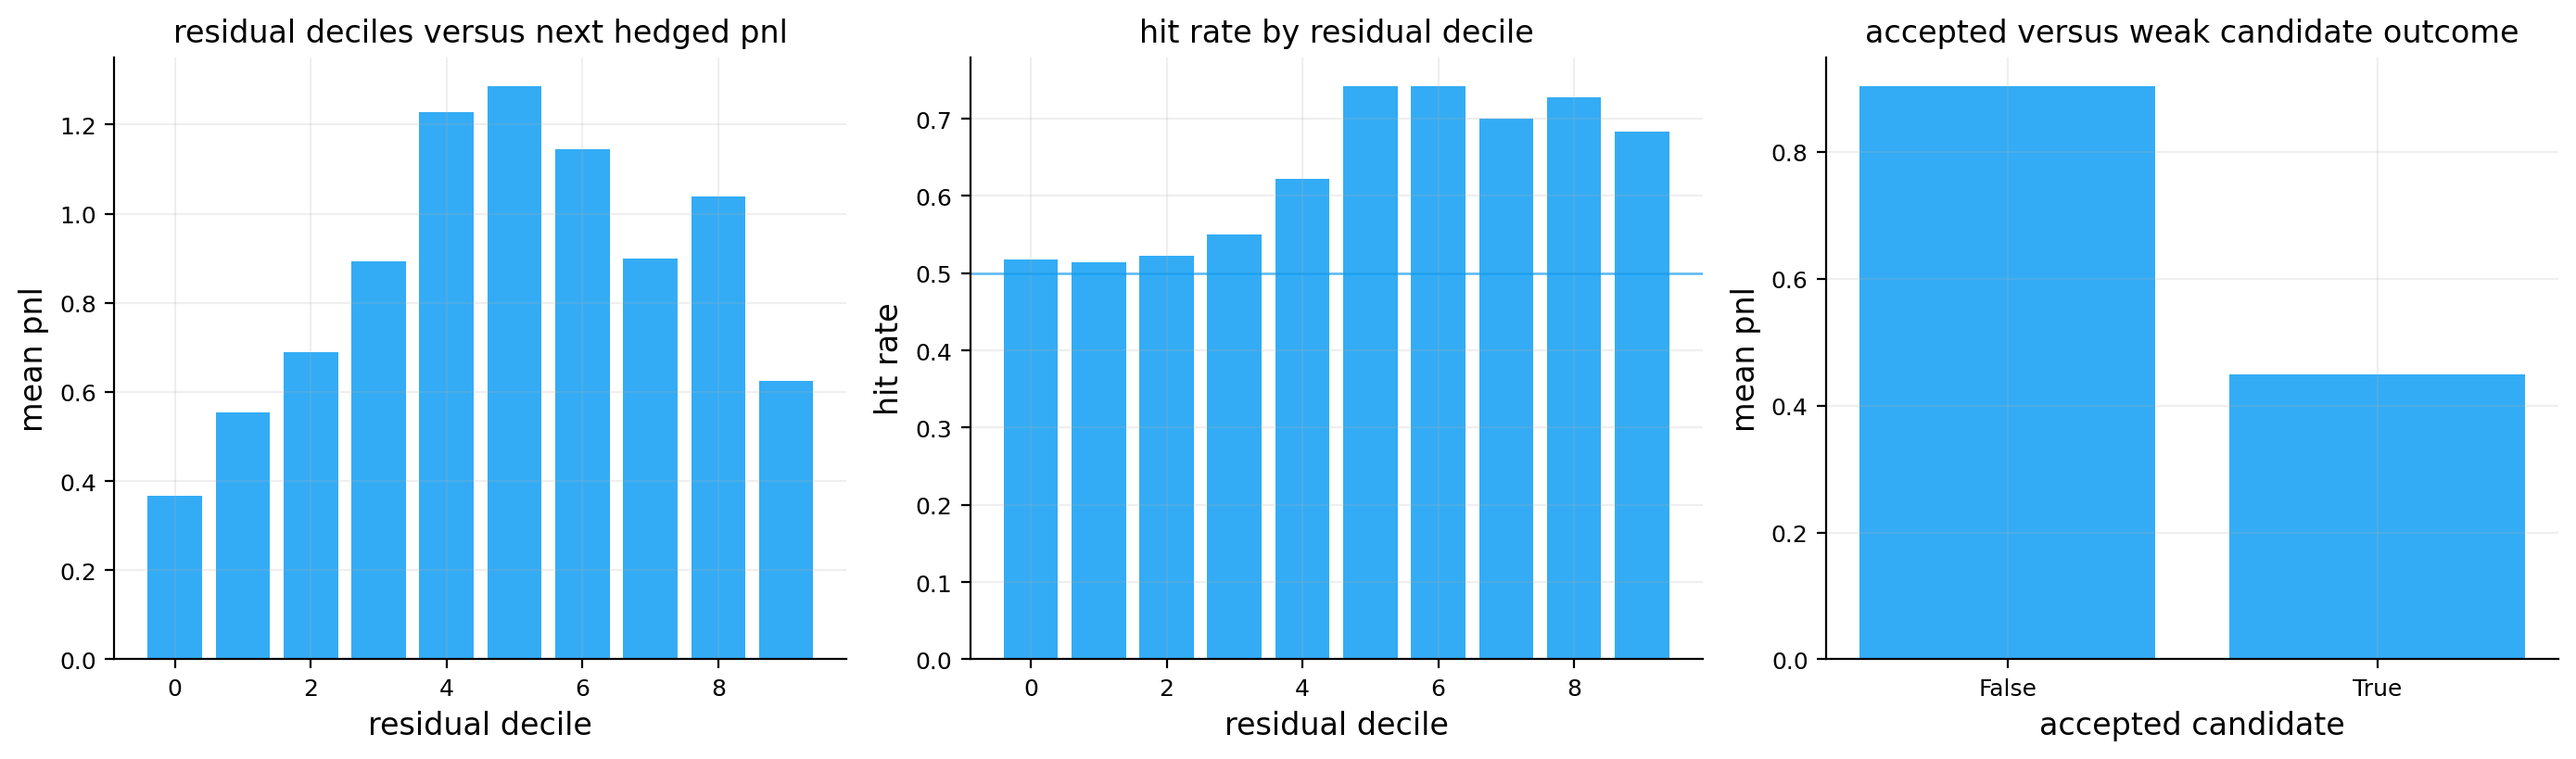

In [77]:
if not validation_panel.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2))
    axes[0].bar(residual_deciles["residual_decile"], residual_deciles["mean_next_hedged_pnl"], alpha=0.82)
    axes[0].axhline(0.0, lw=0.9, alpha=0.65)
    axes[0].set_title("residual deciles versus next hedged pnl")
    axes[0].set_xlabel("residual decile")
    axes[0].set_ylabel("mean pnl")
    axes[1].bar(residual_deciles["residual_decile"], residual_deciles["hit_rate"], alpha=0.82)
    axes[1].axhline(0.5, lw=0.9, alpha=0.65)
    axes[1].set_title("hit rate by residual decile")
    axes[1].set_xlabel("residual decile")
    axes[1].set_ylabel("hit rate")
    outcome = validation_panel.groupby("candidate")["next_hedged_pnl"].mean().rename("mean_pnl").reset_index()
    axes[2].bar(outcome["candidate"].astype(str), outcome["mean_pnl"], alpha=0.82)
    axes[2].axhline(0.0, lw=0.9, alpha=0.65)
    axes[2].set_title("accepted versus weak candidate outcome")
    axes[2].set_xlabel("accepted candidate")
    axes[2].set_ylabel("mean pnl")
    plt.tight_layout()
    plt.show()

In [78]:
option_multiplier = 100.0
beta_window = 60
fixed_hold_days = 3

spx_daily = pd.read_csv(data_dir / "spx_daily_yfinance.csv")
spx_daily["date"] = pd.to_datetime(spx_daily["date"], errors="coerce").dt.normalize()
spx_daily = spx_daily.sort_values("date").drop_duplicates("date", keep="last")
spx_daily["spx_close"] = pd.to_numeric(spx_daily["close"], errors="coerce")
spx_daily["spx_ret"] = np.log(spx_daily["spx_close"] / spx_daily["spx_close"].shift(1))

spy_daily = pd.read_csv(data_dir / "spy_yfinance.csv")
spy_daily["date"] = pd.to_datetime(spy_daily["Date"], errors="coerce").dt.normalize()
spy_daily = spy_daily.sort_values("date").drop_duplicates("date", keep="last")
spy_daily["spy_close"] = pd.to_numeric(spy_daily["Close"], errors="coerce")
spy_daily["spy_dividend"] = pd.to_numeric(spy_daily.get("Dividends", 0.0), errors="coerce").fillna(0.0)
spy_daily["spy_ret_tr"] = np.log(pd.to_numeric(spy_daily["Adj Close"], errors="coerce") / pd.to_numeric(spy_daily["Adj Close"], errors="coerce").shift(1))

hedge_market = spx_daily[["date", "spx_close", "spx_ret"]].merge(spy_daily[["date", "spy_close", "spy_dividend", "spy_ret_tr"]], on="date", how="left")
roll_cov = hedge_market["spx_ret"].rolling(beta_window).cov(hedge_market["spy_ret_tr"])
roll_var = hedge_market["spy_ret_tr"].rolling(beta_window).var()
hedge_market["beta_spx_to_spy"] = (roll_cov / roll_var).replace([np.inf, -np.inf], np.nan).clip(0.85, 1.15).bfill().ffill().fillna(1.0)
hedge_market = hedge_market.set_index("date")


In [79]:
max_hedge_entries, entry_spacing_trade_days = 80, 5
if not validation_panel.empty:
    signal_pool = validation_panel[
        validation_panel["watchlist_candidate"]
        & validation_panel["signal_direction"].ne(0.0)
        & np.isfinite(validation_panel["z_residual"])
        & validation_panel["dte_days"].between(7.0, 90.0)
    ].copy()
    if not signal_pool.empty:
        signal_pool["date"] = pd.to_datetime(signal_pool["date"], errors="coerce").dt.normalize()
        if "model_spread" not in signal_pool.columns:
            signal_pool["model_spread"] = 0.0
        spread_cut = signal_pool["model_spread"].quantile(0.80)
        signal_pool = signal_pool[signal_pool["model_spread"].fillna(0.0) <= spread_cut].copy()
        signal_pool["entry_rank"] = signal_pool["z_residual"].abs()
        signal_pick = signal_pool.sort_values(["date", "entry_rank"], ascending=[True, False]).groupby("date", as_index=False).head(1).copy()
        signal_pick["quantity"] = signal_pick["signal_direction"] * np.sign(signal_pick["price_residual"])
        signal_pick = signal_pick[np.isfinite(signal_pick["quantity"]) & signal_pick["quantity"].ne(0.0)].copy()
    else:
        signal_pick = pd.DataFrame()
else:
    signal_pool = pd.DataFrame()
    signal_pick = pd.DataFrame()


def take_chronological_entries(x, min_gap_days=5, max_entries=80):
    rows = []
    last_date = None
    x = x.sort_values("date").copy()
    for _, r in x.iterrows():
        d = pd.Timestamp(r["date"]).normalize()
        if last_date is None or (d - last_date).days >= int(min_gap_days):
            rows.append(r)
            last_date = d
        if len(rows) >= int(max_entries):
            break
    return pd.DataFrame(rows).reset_index(drop=True) if rows else pd.DataFrame()


if not signal_pick.empty:
    signal_pick = take_chronological_entries(signal_pick, min_gap_days=entry_spacing_trade_days, max_entries=max_hedge_entries)

entry_dates = pd.to_datetime(signal_pick["date"], errors="coerce").dropna().sort_values().to_numpy() if not signal_pick.empty else np.array([], dtype="datetime64[ns]")
display(pd.DataFrame([{"signal_pool": len(signal_pool), "daily_picks": len(signal_pick), "first_entry": pd.to_datetime(entry_dates.min()).date() if len(entry_dates) else pd.NaT, "last_entry": pd.to_datetime(entry_dates.max()).date() if len(entry_dates) else pd.NaT}]))


,signal_pool,daily_picks,first_entry,last_entry
0,5298,80,2022-01-05,2023-07-10


In [80]:
entry_date_set = set(pd.Timestamp(d).normalize() for d in entry_dates)
base_hedge_mask = (
    quote_panel["iv_ok"].fillna(False)
    & quote_panel["dte_days"].between(7.0, 90.0)
    & (quote_panel["mid"] > 0.25)
    & (quote_panel["relative_spread"].fillna(np.inf) <= 0.65)
)
entry_day_quotes = quote_panel[base_hedge_mask & quote_panel["date"].isin(entry_date_set)].copy()
entry_day_quotes["dte"] = entry_day_quotes["dte_days"]
entry_day_quotes["rel_spread"] = entry_day_quotes["relative_spread"]
entry_day_quotes["half_spread"] = 0.5 * (entry_day_quotes["ask"] - entry_day_quotes["bid"]).clip(lower=0.0)
entry_day_quotes["timestamp"] = entry_day_quotes["date"]

if not entry_day_quotes.empty:
    candidate_keys = entry_day_quotes["contract_key"].unique()
    first_future = pd.Timestamp(entry_dates.min()).normalize() if len(entry_dates) else pd.NaT
    last_future = pd.Timestamp(entry_dates.max()).normalize() + pd.Timedelta(days=18) if len(entry_dates) else pd.NaT
    future_counts = quote_panel[
        quote_panel["contract_key"].isin(candidate_keys)
        & quote_panel["date"].between(first_future, last_future)
    ][["date", "contract_key"]].drop_duplicates(["date", "contract_key"]).copy()
    future_counts = future_counts.sort_values(["contract_key", "date"])
    future_counts["future_quote_count"] = future_counts.groupby("contract_key").cumcount(ascending=False) + 1
    entry_day_quotes = entry_day_quotes.merge(future_counts, on=["date", "contract_key"], how="left")
else:
    entry_day_quotes["future_quote_count"] = pd.Series(dtype=float)

quote_by_date = {
    pd.Timestamp(d).normalize(): g.copy()
    for d, g in entry_day_quotes.groupby("date", sort=False)
}

display(pd.DataFrame([{"entry_day_quotes": len(entry_day_quotes), "entry_dates_with_quotes": len(quote_by_date), "candidate_contracts": entry_day_quotes["contract_key"].nunique() if len(entry_day_quotes) else 0}]))


,entry_day_quotes,entry_dates_with_quotes,candidate_contracts
0,444213,80,112067


In [81]:
schedule_cols = ["entry_date", "contract_key", "quantity", "label", "entry_score", "entry_residual", "entry_total_error", "entry_z", "max_hold_days", "exit_on_convergence", "exit_on_sign_flip"]


def pick_matched_baseline(day, option_type, target_dte):
    want = day[day["option_type"].eq(option_type)].copy()
    if want.empty:
        return None
    target_dte = float(target_dte) if np.isfinite(target_dte) else 35.0
    lo = max(7.0, target_dte - 10.0)
    hi = min(90.0, target_dte + 10.0)
    d = want[want["dte_days"].between(lo, hi) & want["delta"].abs().between(0.25, 0.75)].copy()
    if d.empty:
        d = want[want["dte_days"].between(max(7.0, target_dte - 18.0), min(90.0, target_dte + 18.0)) & want["delta"].abs().between(0.20, 0.80)].copy()
    if d.empty:
        d = want[want["dte_days"].between(21.0, 60.0) & want["delta"].abs().between(0.20, 0.80)].copy()
    if d.empty:
        return None
    volume = pd.to_numeric(d["volume"], errors="coerce").fillna(0.0) if "volume" in d.columns else pd.Series(0.0, index=d.index)
    future = pd.to_numeric(d["future_quote_count"], errors="coerce").fillna(0.0) if "future_quote_count" in d.columns else pd.Series(0.0, index=d.index)
    d["entry_score"] = (
        -2.0 * (d["delta"].abs() - 0.50).abs()
        -0.06 * (d["dte_days"] - target_dte).abs()
        -1.75 * d["relative_spread"].fillna(0.0)
        +0.00015 * volume
        +0.015 * future
    )
    return d.sort_values("entry_score", ascending=False).iloc[0]


if not signal_pick.empty:
    entry_schedule_residual = pd.DataFrame({
        "entry_date": pd.to_datetime(signal_pick["date"], errors="coerce").dt.normalize(),
        "contract_key": signal_pick["contract_key"],
        "quantity": signal_pick["quantity"],
        "label": "residual_selector",
        "entry_score": signal_pick["z_residual"].abs(),
        "entry_residual": signal_pick["price_residual"],
        "entry_total_error": signal_pick["total_error"],
        "entry_z": signal_pick["z_residual"],
        "max_hold_days": np.nan,
        "exit_on_convergence": False,
        "exit_on_sign_flip": False,
    })
else:
    entry_schedule_residual = pd.DataFrame(columns=schedule_cols)

matched_rows = []
baseline_match_rows = []
if not signal_pick.empty:
    for _, pick in signal_pick.iterrows():
        d = pd.Timestamp(pick["date"]).normalize()
        day = quote_by_date.get(d)
        if day is None or day.empty:
            continue
        row = pick_matched_baseline(day, pick["option_type"], pick["dte_days"])
        if row is None:
            continue
        matched_rows.append({
            "entry_date": d,
            "contract_key": row["contract_key"],
            "quantity": float(pick["quantity"]),
            "label": "matched_atm",
            "entry_score": row["entry_score"],
            "entry_residual": np.nan,
            "entry_total_error": np.nan,
            "entry_z": np.nan,
            "max_hold_days": np.nan,
            "exit_on_convergence": False,
            "exit_on_sign_flip": False,
        })
        baseline_match_rows.append({
            "entry_date": d,
            "residual_option_type": pick["option_type"],
            "matched_option_type": row["option_type"],
            "residual_quantity": float(pick["quantity"]),
            "matched_quantity": float(pick["quantity"]),
            "residual_dte": float(pick["dte_days"]),
            "matched_dte": float(row["dte_days"]),
        })
entry_schedule_matched_baseline = pd.DataFrame(matched_rows, columns=schedule_cols)
baseline_match_check = pd.DataFrame(baseline_match_rows)

if not entry_schedule_residual.empty and not entry_schedule_matched_baseline.empty:
    matched_dates = set(pd.to_datetime(entry_schedule_matched_baseline["entry_date"], errors="coerce").dt.normalize())
    entry_schedule_residual = entry_schedule_residual[pd.to_datetime(entry_schedule_residual["entry_date"], errors="coerce").dt.normalize().isin(matched_dates)].reset_index(drop=True)

display(pd.DataFrame([{"residual_schedule": len(entry_schedule_residual), "matched_schedule": len(entry_schedule_matched_baseline), "same_type_match_rate": len(entry_schedule_matched_baseline) / max(len(signal_pick), 1)}]))
if not baseline_match_check.empty:
    display(baseline_match_check.groupby(["residual_option_type", "matched_option_type", "residual_quantity", "matched_quantity"]).size().rename("matches").reset_index())


,residual_schedule,matched_schedule,same_type_match_rate
0,80,80,1.000000


,residual_option_type,matched_option_type,residual_quantity,matched_quantity,matches
0,call,call,-1.000000,-1.000000,18
1,call,call,1.000000,1.000000,22
2,put,put,-1.000000,-1.000000,33
3,put,put,1.000000,1.000000,7


In [82]:
def schedule_for_fixed_hold(x, label, hold_days):
    if x.empty:
        return pd.DataFrame(columns=schedule_cols)
    y = x.copy()
    y["label"] = label
    y["max_hold_days"] = int(hold_days)
    y["exit_on_convergence"] = False
    y["exit_on_sign_flip"] = False
    return y[schedule_cols].copy()


schedule_map = {
    "matched_atm_3d": schedule_for_fixed_hold(entry_schedule_matched_baseline, "matched_atm_3d", fixed_hold_days),
    "surface_residual_3d": schedule_for_fixed_hold(entry_schedule_residual, "surface_residual_3d", fixed_hold_days),
}
run_meta = pd.DataFrame([
    {"run": "matched_atm_3d", "selector": "matched_atm", "hold_days": fixed_hold_days, "exit_rule": "fixed"},
    {"run": "surface_residual_3d", "selector": "surface_residual", "hold_days": fixed_hold_days, "exit_rule": "fixed"},
])
all_schedules = pd.concat([s for s in schedule_map.values() if not s.empty], ignore_index=True) if any(not s.empty for s in schedule_map.values()) else pd.DataFrame(columns=schedule_cols)
scheduled_keys = set(all_schedules["contract_key"].astype(str)) if not all_schedules.empty else set()

display(run_meta.assign(entries=run_meta["run"].map({k: len(v) for k, v in schedule_map.items()})))


,run,selector,hold_days,exit_rule,entries
0,matched_atm_3d,matched_atm,3,fixed,80
1,surface_residual_3d,surface_residual,3,fixed,80


In [83]:
if scheduled_keys and not all_schedules.empty:
    first_entry = pd.to_datetime(all_schedules["entry_date"], errors="coerce").min() - pd.Timedelta(days=3)
    last_entry = pd.to_datetime(all_schedules["entry_date"], errors="coerce").max() + pd.Timedelta(days=18)
    hedge_option_book = quote_panel[
        quote_panel["contract_key"].astype(str).isin(scheduled_keys)
        & quote_panel["date"].between(first_entry, last_entry)
    ].copy()
else:
    first_entry = pd.NaT
    last_entry = pd.NaT
    hedge_option_book = quote_panel.head(0).copy()

if len(hedge_option_book):
    hedge_option_book["dte"] = hedge_option_book["dte_days"]
    hedge_option_book["rel_spread"] = hedge_option_book["relative_spread"]
    hedge_option_book["half_spread"] = 0.5 * (hedge_option_book["ask"] - hedge_option_book["bid"]).clip(lower=0.0)
    hedge_option_book["timestamp"] = hedge_option_book["date"]

if not validation_panel.empty and len(hedge_option_book):
    residual_marks = validation_panel[["date", "contract_key", "price_residual", "total_error", "z_residual"]].drop_duplicates(["date", "contract_key"])
    hedge_option_book = hedge_option_book.merge(residual_marks, on=["date", "contract_key"], how="left", suffixes=("", "_signal"))

display(pd.DataFrame([{"scheduled_runs": len(schedule_map), "scheduled_entries": len(all_schedules), "hedge_book_rows": len(hedge_option_book), "hedge_contracts": len(scheduled_keys), "first_entry": first_entry, "last_entry": last_entry}]))


,scheduled_runs,scheduled_entries,hedge_book_rows,hedge_contracts,first_entry,last_entry
0,2,160,6658,159,2022-01-02,2023-07-28


In [84]:
def blank_hedge_result(reason="not run"):
    return {"nav": pd.DataFrame(), "returns": pd.DataFrame(), "pnl": pd.DataFrame(), "components": pd.DataFrame(), "exposures": pd.DataFrame(), "trades": pd.DataFrame(), "summary": pd.DataFrame(), "diagnostics": {"reason": reason}}


scheduled_results = {}
if len(hedge_option_book):
    for run_name, schedule in schedule_map.items():
        if schedule.empty:
            scheduled_results[run_name] = blank_hedge_result("empty schedule")
            continue
        try:
            scheduled_results[run_name] = run_scheduled_option_hedging_backtest(
                option_path=hedge_option_book,
                entry_schedule=schedule,
                spot_series=hedge_market["spx_close"],
                greeks=hedge_option_book,
                hedge_price_series=hedge_market["spy_close"],
                hedge_dividend_series=hedge_market["spy_dividend"],
                hedge_beta_series=hedge_market["beta_spx_to_spy"],
                strategies=("delta",),
                delta_band=14.0,
                delta_inner_band=3.0,
                delta_share_lot=25.0,
                delta_cooldown_days=1,
                trading_cost_bps=1.0,
                use_bid_ask_costs=True,
                option_multiplier=option_multiplier,
                exit_dte_days=7.0,
                missing_option_mark="skip_day",
                pnl_mode="usd_equivalent",
                quote_price_unit="usd",
                hedge_symbol="SPY",
                annualization_days=ann_days,
                contract_size=1.0,
            )
        except Exception as exc:
            scheduled_results[run_name] = blank_hedge_result(str(exc))
else:
    scheduled_results = {run_name: blank_hedge_result("empty hedge book") for run_name in schedule_map}

run_status = []
for run_name, result in scheduled_results.items():
    run_status.append({"run": run_name, "component_rows": len(result["components"]), "opened_entries": result.get("diagnostics", {}).get("n_opened_episodes", 0), "reason": result.get("diagnostics", {}).get("reason", "")})
display(pd.DataFrame(run_status))


,run,component_rows,opened_entries,reason
0,matched_atm_3d,320,80,
1,surface_residual_3d,316,80,


In [85]:
summary_parts = []
for run_name, result in scheduled_results.items():
    s = summarize_hedging_backtest(result).copy()
    if s.empty:
        s = pd.DataFrame([{"strategy": "delta", "status": "skipped", "total_pnl": np.nan}])
    s["run"] = run_name
    summary_parts.append(s)
scheduled_backtest_summary = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()
scheduled_backtest_summary = scheduled_backtest_summary.merge(run_meta, on="run", how="left") if not scheduled_backtest_summary.empty else scheduled_backtest_summary


def normalized_rows(run_name, result):
    s = summarize_hedging_backtest(result).copy()
    c = result.get("components", pd.DataFrame()).copy()
    if s.empty or c.empty:
        return pd.DataFrame()
    c = c.sort_values(["strategy", "episode_id", "date"])
    first = c.groupby(["strategy", "episode_id"], as_index=False).head(1).copy()
    first["entry_premium"] = (first["main_pos"].abs() * first["option_mid"].abs() * option_multiplier).replace([np.inf, -np.inf], np.nan)
    first["initial_abs_vega"] = first["vega_after"].abs().replace([np.inf, -np.inf], np.nan)
    first["initial_abs_delta"] = first["delta_after"].abs().replace([np.inf, -np.inf], np.nan)
    den = first.groupby("strategy").agg(
        entry_premium=("entry_premium", "sum"),
        initial_abs_vega=("initial_abs_vega", "sum"),
        initial_abs_delta=("initial_abs_delta", "sum"),
        episodes=("episode_id", "nunique"),
    ).reset_index()
    avg_delta = c.groupby("strategy")["delta_after"].apply(lambda x: float(np.nanmean(np.abs(x)))).rename("average_abs_delta").reset_index()
    out = s.merge(den, on="strategy", how="left").merge(avg_delta, on="strategy", how="left")
    out["run"] = run_name
    out["pnl_per_option_premium"] = out["total_pnl"] / out["entry_premium"].abs().clip(lower=1e-12)
    out["pnl_per_traded_notional"] = out["total_pnl"] / out["traded_notional"].abs().clip(lower=1e-12)
    out["pnl_per_initial_vega"] = out["total_pnl"] / out["initial_abs_vega"].abs().clip(lower=1e-12)
    out["pnl_per_average_abs_delta"] = out["total_pnl"] / out["average_abs_delta"].abs().clip(lower=1e-12)
    out["cost_pct_premium"] = out["total_costs"] / out["entry_premium"].abs().clip(lower=1e-12)
    out["max_drawdown_per_notional"] = out["max_drawdown"] / out["traded_notional"].abs().clip(lower=1e-12)
    return out


normalized_parts = [normalized_rows(run_name, result) for run_name, result in scheduled_results.items()]
normalized_performance = pd.concat([x for x in normalized_parts if not x.empty], ignore_index=True) if any(not x.empty for x in normalized_parts) else pd.DataFrame()
normalized_performance = normalized_performance.merge(run_meta, on="run", how="left") if not normalized_performance.empty else normalized_performance
fixed_hold_performance = normalized_performance[["run", "selector", "hold_days", "strategy", "episodes", "total_pnl", "pnl_per_option_premium", "pnl_per_traded_notional", "pnl_per_initial_vega", "cost_pct_premium", "max_drawdown_per_notional"]].copy() if not normalized_performance.empty else pd.DataFrame()
matched_benchmark_summary = scheduled_backtest_summary.copy()
trade_summary = fixed_hold_performance.copy() if not fixed_hold_performance.empty else scheduled_backtest_summary.copy()

display(scheduled_backtest_summary)
display(fixed_hold_performance)


,strategy,status,n_days,total_pnl,mean_daily_pnl,std_daily_pnl,total_costs,trade_count,traded_notional,max_drawdown,mean_abs_delta_after,mean_abs_vega_after,run,selector,hold_days,exit_rule
0,delta,ok,318,"-26,620.779516",-83.713143,"1,397.265681","14,371.736825",240,"37,367,368.250000","-38,436.759012",28.654916,"45,980.303026",matched_atm_3d,matched_atm,3,fixed
1,delta,ok,314,"-9,031.743112",-28.763513,537.567972,"3,910.222750",173,"4,802,227.500000","-15,690.727703",8.028346,"17,676.777941",surface_residual_3d,surface_residual,3,fixed


,run,selector,hold_days,strategy,episodes,total_pnl,pnl_per_option_premium,pnl_per_traded_notional,pnl_per_initial_vega,cost_pct_premium,max_drawdown_per_notional
0,matched_atm_3d,matched_atm,3,delta,80,"-26,620.779516",-0.034140,-0.000712,-0.006864,0.018431,-0.001029
1,surface_residual_3d,surface_residual,3,delta,80,"-9,031.743112",-0.078465,-0.001881,-0.006269,0.033971,-0.003267


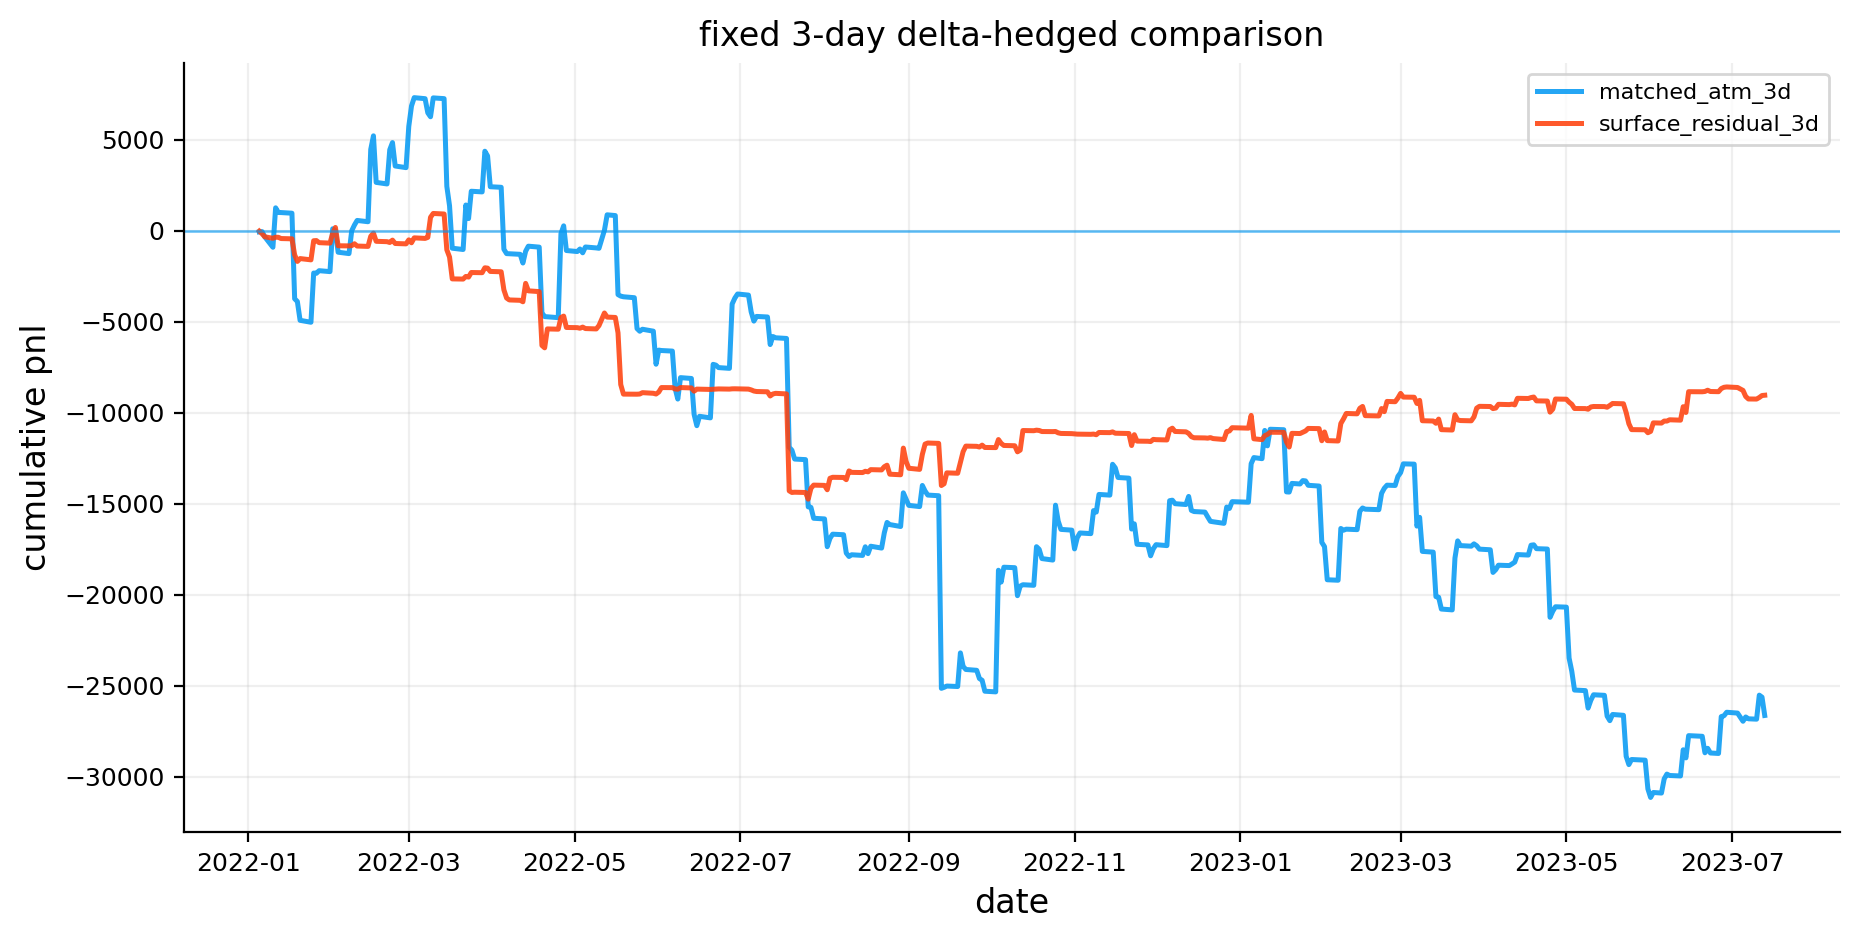

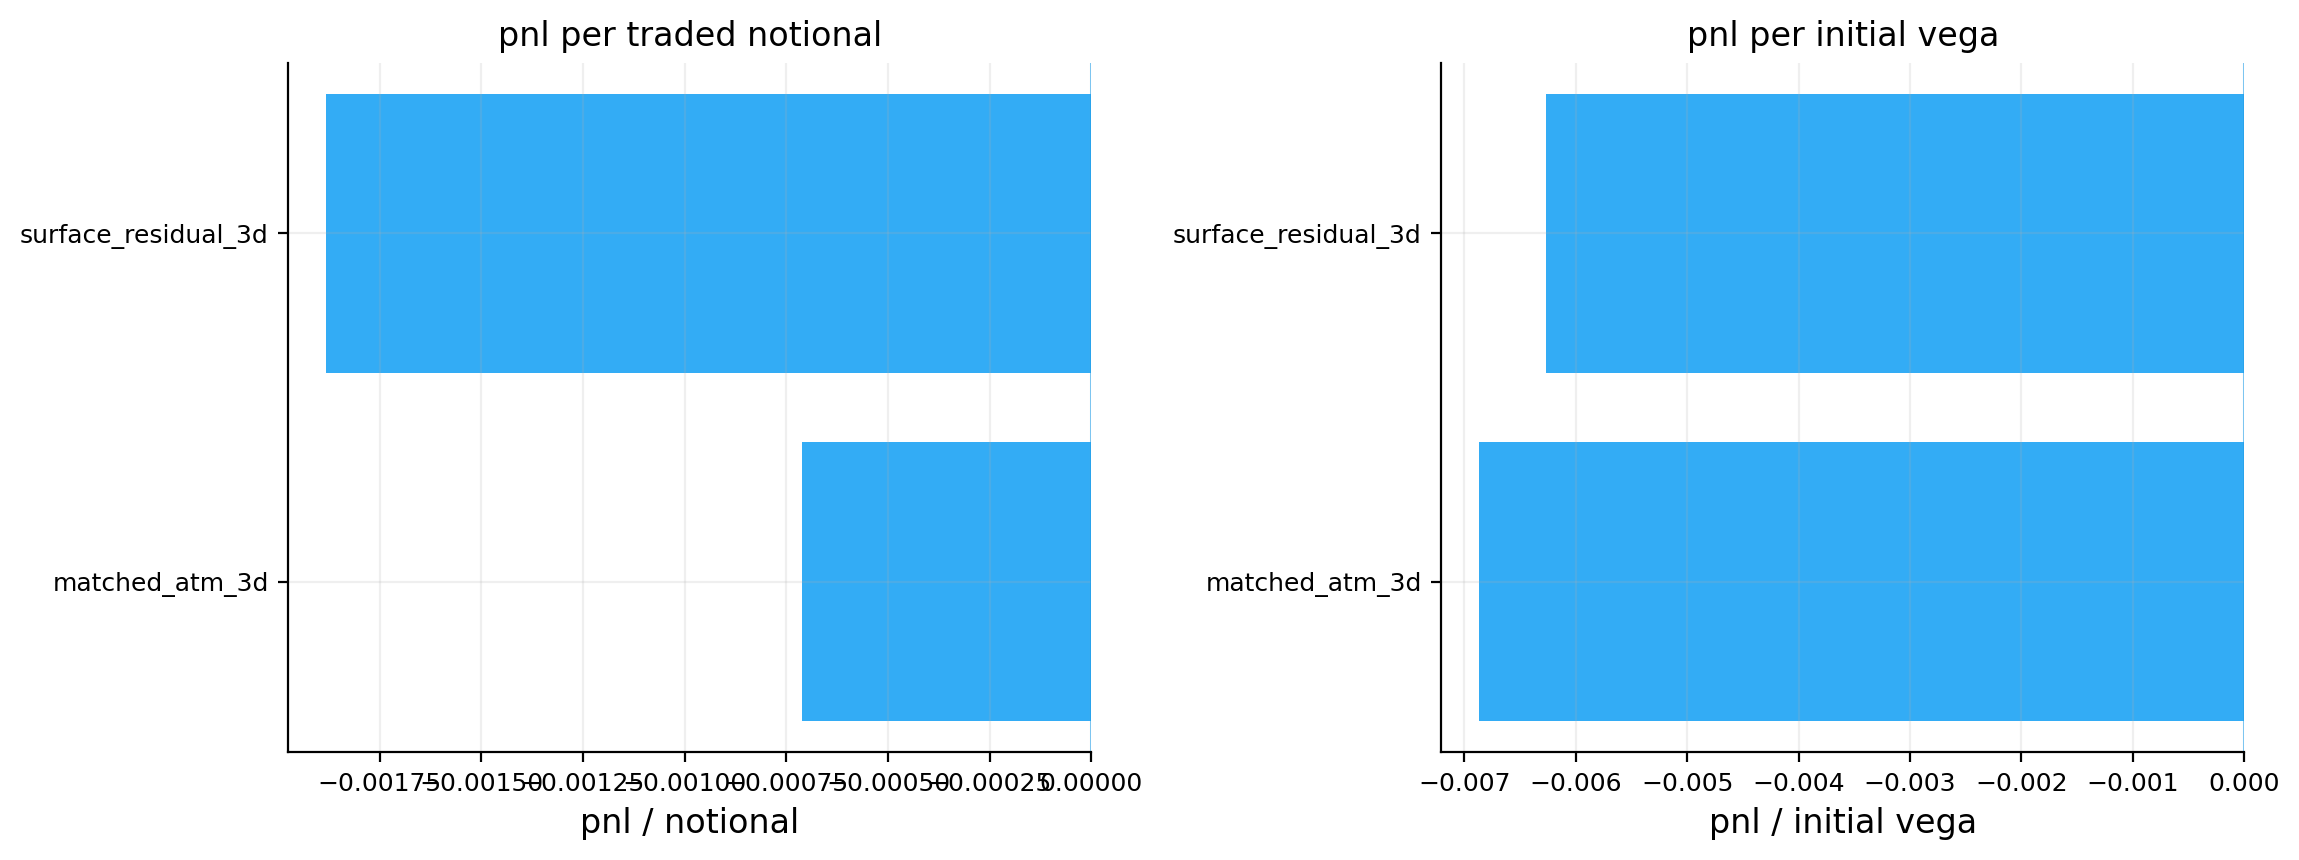

In [86]:
if scheduled_results:
    fig, ax = plt.subplots(figsize=(9.4, 4.8))
    for run_name, result in scheduled_results.items():
        nav = result["nav"]
        if "delta" in nav.columns:
            ax.plot(nav.index, nav["delta"], lw=1.8, alpha=0.88, label=run_name)
    ax.axhline(0.0, lw=0.9, alpha=0.65)
    ax.set_title("fixed 3-day delta-hedged comparison")
    ax.set_xlabel("date")
    ax.set_ylabel("cumulative pnl")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

if not fixed_hold_performance.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
    labels = fixed_hold_performance["run"]
    axes[0].barh(labels, fixed_hold_performance["pnl_per_traded_notional"], alpha=0.82)
    axes[0].axvline(0.0, lw=0.9, alpha=0.65)
    axes[0].set_title("pnl per traded notional")
    axes[0].set_xlabel("pnl / notional")
    axes[1].barh(labels, fixed_hold_performance["pnl_per_initial_vega"], alpha=0.82)
    axes[1].axvline(0.0, lw=0.9, alpha=0.65)
    axes[1].set_title("pnl per initial vega")
    axes[1].set_xlabel("pnl / initial vega")
    plt.tight_layout()
    plt.show()


,run,option_mid_pnl,delta_hedge_pnl,bid_ask_and_hedge_cost,net_pnl,mean_abs_delta_after,mean_abs_vega_after
0,matched_atm_3d,"-17,135.000000","3,593.750000","14,371.736825","-26,620.779516",29.162983,"45,944.644697"
1,surface_residual_3d,"-13,475.000000","8,446.000000","3,910.222750","-9,031.743112",8.057869,"17,658.830385"


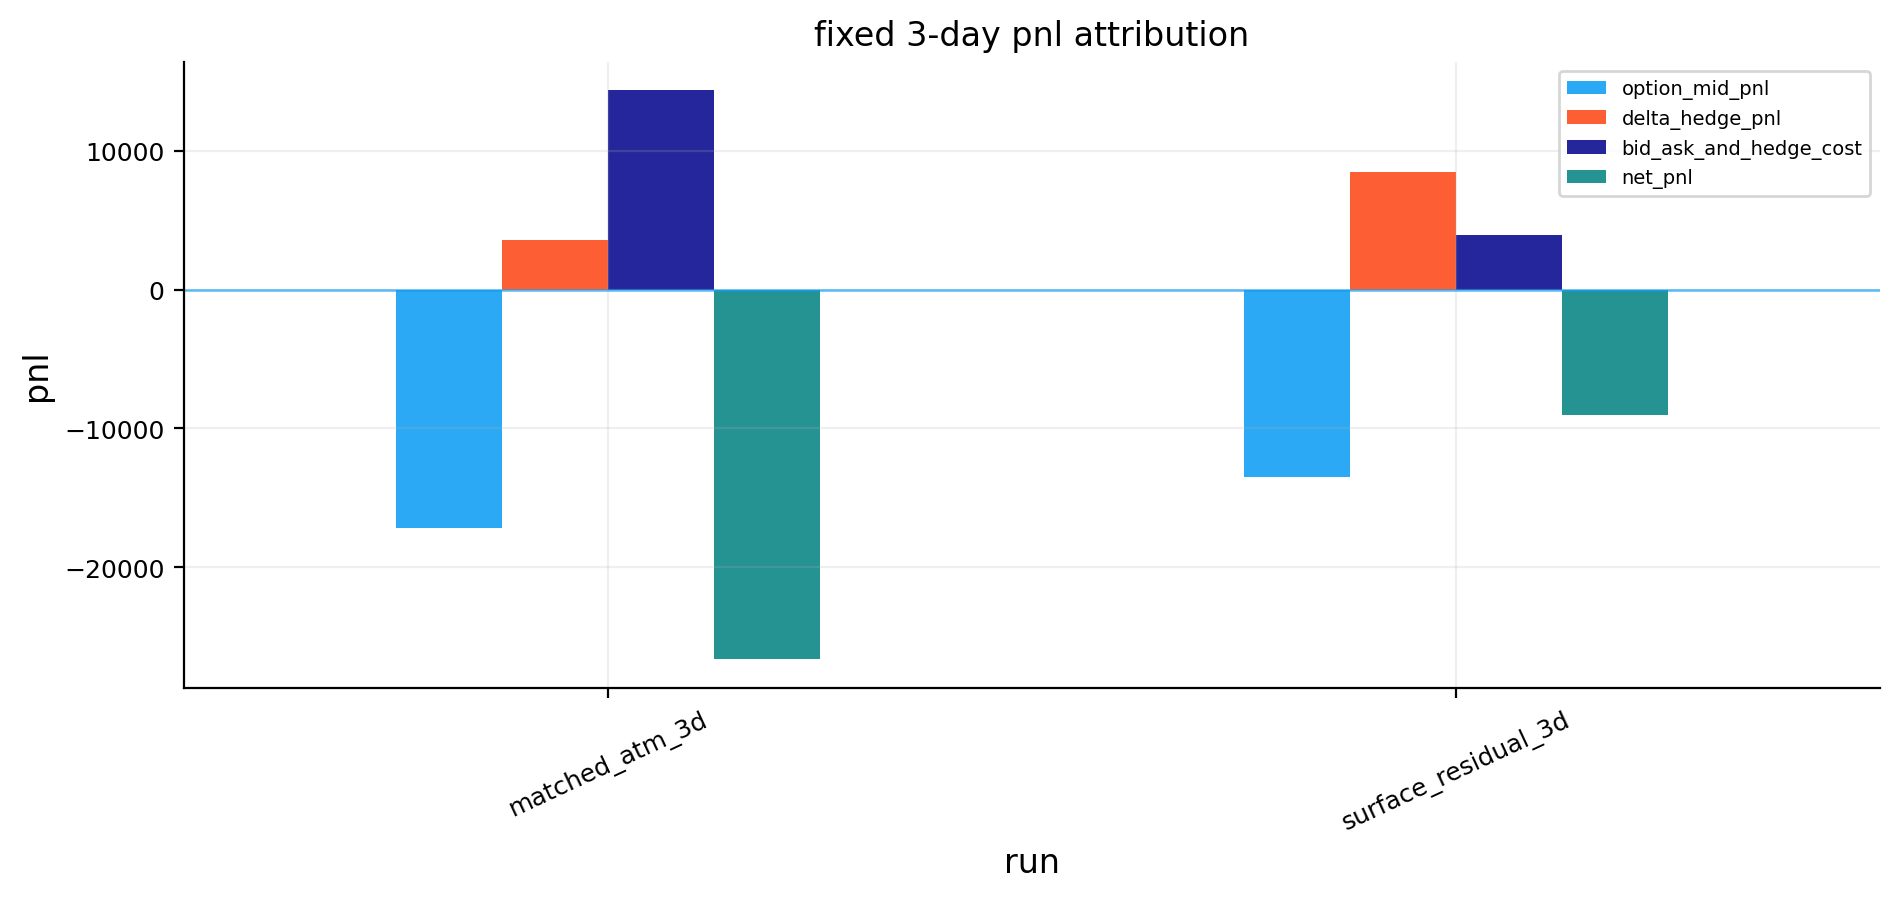

In [87]:
component_parts = []
trade_parts_scheduled = []
for run_name, result in scheduled_results.items():
    if not result["components"].empty:
        component_parts.append(result["components"].assign(run=run_name))
    if not result["trades"].empty:
        trade_parts_scheduled.append(result["trades"].assign(run=run_name))
scheduled_components = pd.concat(component_parts, ignore_index=True) if component_parts else pd.DataFrame()
scheduled_trades = pd.concat(trade_parts_scheduled, ignore_index=True) if trade_parts_scheduled else pd.DataFrame()

if not scheduled_components.empty:
    scheduled_attribution = scheduled_components.groupby("run").agg(
        option_mid_pnl=("main_option_pnl", "sum"),
        delta_hedge_pnl=("underlying_hedge_pnl", "sum"),
        bid_ask_and_hedge_cost=("transaction_costs", "sum"),
        net_pnl=("net_pnl", "sum"),
        mean_abs_delta_after=("delta_after", lambda x: float(np.nanmean(np.abs(x)))),
        mean_abs_vega_after=("vega_after", lambda x: float(np.nanmean(np.abs(x)))),
    ).reset_index()
    display(scheduled_attribution)
    a = scheduled_attribution.set_index("run")[["option_mid_pnl", "delta_hedge_pnl", "bid_ask_and_hedge_cost", "net_pnl"]]
    fig, ax = plt.subplots(figsize=(9.6, 4.6))
    a.plot(kind="bar", ax=ax, alpha=0.85)
    ax.axhline(0.0, lw=0.9, alpha=0.65)
    ax.set_title("fixed 3-day pnl attribution")
    ax.set_xlabel("run")
    ax.set_ylabel("pnl")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()
else:
    scheduled_attribution = pd.DataFrame()


In [88]:
stochastic_vol_objects = {
    "calibration_panel": calibration_panel,
    "model_panel": model_panel,
    "svi_diag": svi_diag,
    "ssvi_diag": ssvi_diag,
    "sabr_diag": sabr_diag,
    "merton_diag": merton_diag,
    "heston_diag": heston_diag,
    "bates_diag": bates_diag,
    "own_panel_fit": own_panel_fit,
    "common_benchmark_fit": common_benchmark_fit,
    "model_comparison": model_comparison,
    "speed_summary": speed_summary,
    "uncertainty_summary": uncertainty_summary,
    "candidate_summary": candidate_summary,
    "trade_summary": trade_summary,
    "entry_schedule_residual": entry_schedule_residual,
    "entry_schedule_matched_baseline": entry_schedule_matched_baseline,
    "baseline_match_check": baseline_match_check,
    "run_meta": run_meta,
    "fixed_hold_performance": fixed_hold_performance,
    "scheduled_backtest_summary": scheduled_backtest_summary,
    "matched_benchmark_summary": matched_benchmark_summary,
    "normalized_performance": normalized_performance,
    "scheduled_attribution": scheduled_attribution,
    "scheduled_components": scheduled_components,
    "scheduled_trades": scheduled_trades,
}
final_object_summary = []
for name, obj in stochastic_vol_objects.items():
    if isinstance(obj, pd.DataFrame):
        final_object_summary.append({"object": name, "rows": len(obj), "columns": len(obj.columns)})
    else:
        final_object_summary.append({"object": name, "rows": np.nan, "columns": np.nan})
display(pd.DataFrame(final_object_summary))


,object,rows,columns
0,calibration_panel,1515066,106
1,model_panel,1519842,106
2,svi_diag,29,15
3,ssvi_diag,1,10
4,sabr_diag,87,12
5,merton_diag,1,15
6,heston_diag,1,13
7,bates_diag,1,14
8,own_panel_fit,6,9
9,common_benchmark_fit,6,10


,requested_engine,engine_used,numba_available
0,auto,numba,True


,step,rows,removed
0,raw rows,258234,NaN
1,after schema normalization,258234,0.000000
2,after positive price filter,218710,"39,524.000000"
3,after bid/ask/spread filter,196404,"22,306.000000"
4,after DTE filter,136262,"60,142.000000"
5,after moneyness filter,121361,"14,901.000000"
6,after ATM-pair selection,121361,0.000000
7,final rows,121361,0.000000


,forward_fallback_share,forward_fallback_rows
0,0.000527,64


,model,benchmark_quotes,iv_quotes,weighted_iv_rmse,weighted_price_rmse,tail_error,runtime,success
0,svi,60,60,0.015561,0.602879,0.026674,1.354696,True
1,ssvi,60,60,0.049213,9.962740,0.078709,0.084069,True
2,sabr,60,60,0.018157,2.655991,0.030032,0.716396,True
3,merton,60,60,0.004798,0.781142,0.005809,282.607980,True
4,heston,60,60,0.036923,5.557398,0.044673,4.490017,True
5,bates,60,59,0.021282,2.878996,0.017302,3.090900,True


,decile,mean_z,mean_next_hedged_pnl,hit_rate,count
0,0,-0.911688,28.627377,0.535660,1977
1,1,-0.312500,18.286422,0.523279,1976
2,2,-0.109607,38.570148,0.542004,1976
3,3,0.008445,114.043749,0.562247,1976
4,4,0.110639,41.575876,0.534648,1977
5,5,0.242105,12.469300,0.491903,1976
6,6,0.394495,8.612801,0.506073,1976
7,7,0.581397,14.156114,0.553138,1976
8,8,0.853802,8.211917,0.567814,1976
9,9,2.819373,-6.209967,0.509863,1977


,schedule,entries
0,residual,41
1,matched_atm,41


,strategy,status,n_days,total_pnl,mean_daily_pnl,std_daily_pnl,total_costs,trade_count,traded_notional,max_drawdown,mean_abs_delta_after,mean_abs_vega_after,run,entry_premium,initial_vega,average_abs_delta,pnl_per_premium,pnl_per_traded_notional,pnl_per_initial_vega,cost_pct_premium
0,unhedged,ok,115,"1,705.293021",14.828635,858.388033,"4,617.897242",80,"286,945.365479","-14,945.121509",0.447369,"6,025.885748",matched_atm_fixed_3d,"145,494.339652","264,139.499738",0.492986,0.011721,0.005943,0.006456,0.031739
1,delta,ok,115,"-6,394.575376",-55.605003,302.952033,"5,158.805445",102,"2,991,486.383842","-7,841.469478",0.111664,"6,025.885748",matched_atm_fixed_3d,"145,494.339652","264,139.499738",0.151160,-0.043951,-0.002138,-0.024209,0.035457
2,unhedged,ok,104,-559.989358,-5.384513,177.475700,738.593900,65,"29,738.361911","-2,395.748181",0.052082,"1,388.890724",residual_selector_fixed_3d,"14,300.048061","53,161.125182",0.054101,-0.039160,-0.018831,-0.010534,0.051650
3,delta,ok,104,"-1,276.709914",-12.276057,81.624848,774.600464,67,"209,771.180101","-1,508.619926",0.026544,"1,388.890724",residual_selector_fixed_3d,"14,300.048061","53,161.125182",0.031466,-0.089280,-0.006086,-0.024016,0.054168


,valuation_currency,pnl_mode,price_unit_detected,annualization_days,contract_size,calendar,missing_option_mark_policy,n_option_book_rows,n_scheduled_entries,n_opened_episodes,n_missing_entry_contracts,n_missing_option_marks,n_missing_option_mark_errors,n_missing_option_mark_skip_days,n_stale_option_marks,n_exit_max_hold,n_exit_dte,n_exit_convergence,n_exit_sign_flip,n_exit_missing_mark,n_unique_main_contracts,strategies_run
0,USD,usd_equivalent,base,365.000000,1.000000,crypto_24_7,skip_day,1574,41,82,0,30,0,30,0,46,4,0,0,30,35,"[unhedged, delta]"


,valuation_currency,pnl_mode,price_unit_detected,annualization_days,contract_size,calendar,missing_option_mark_policy,n_option_book_rows,n_scheduled_entries,n_opened_episodes,n_missing_entry_contracts,n_missing_option_marks,n_missing_option_mark_errors,n_missing_option_mark_skip_days,n_stale_option_marks,n_exit_max_hold,n_exit_dte,n_exit_convergence,n_exit_sign_flip,n_exit_missing_mark,n_unique_main_contracts,strategies_run
0,USD,usd_equivalent,base,365.000000,1.000000,crypto_24_7,skip_day,1964,41,82,0,0,0,0,0,76,4,0,0,0,35,"[unhedged, delta]"


,asset,date,quotes,expiries,models,validation_rows,hedge_runs,engine
0,btc,2024-03-11,273,6,6,20126,2,auto


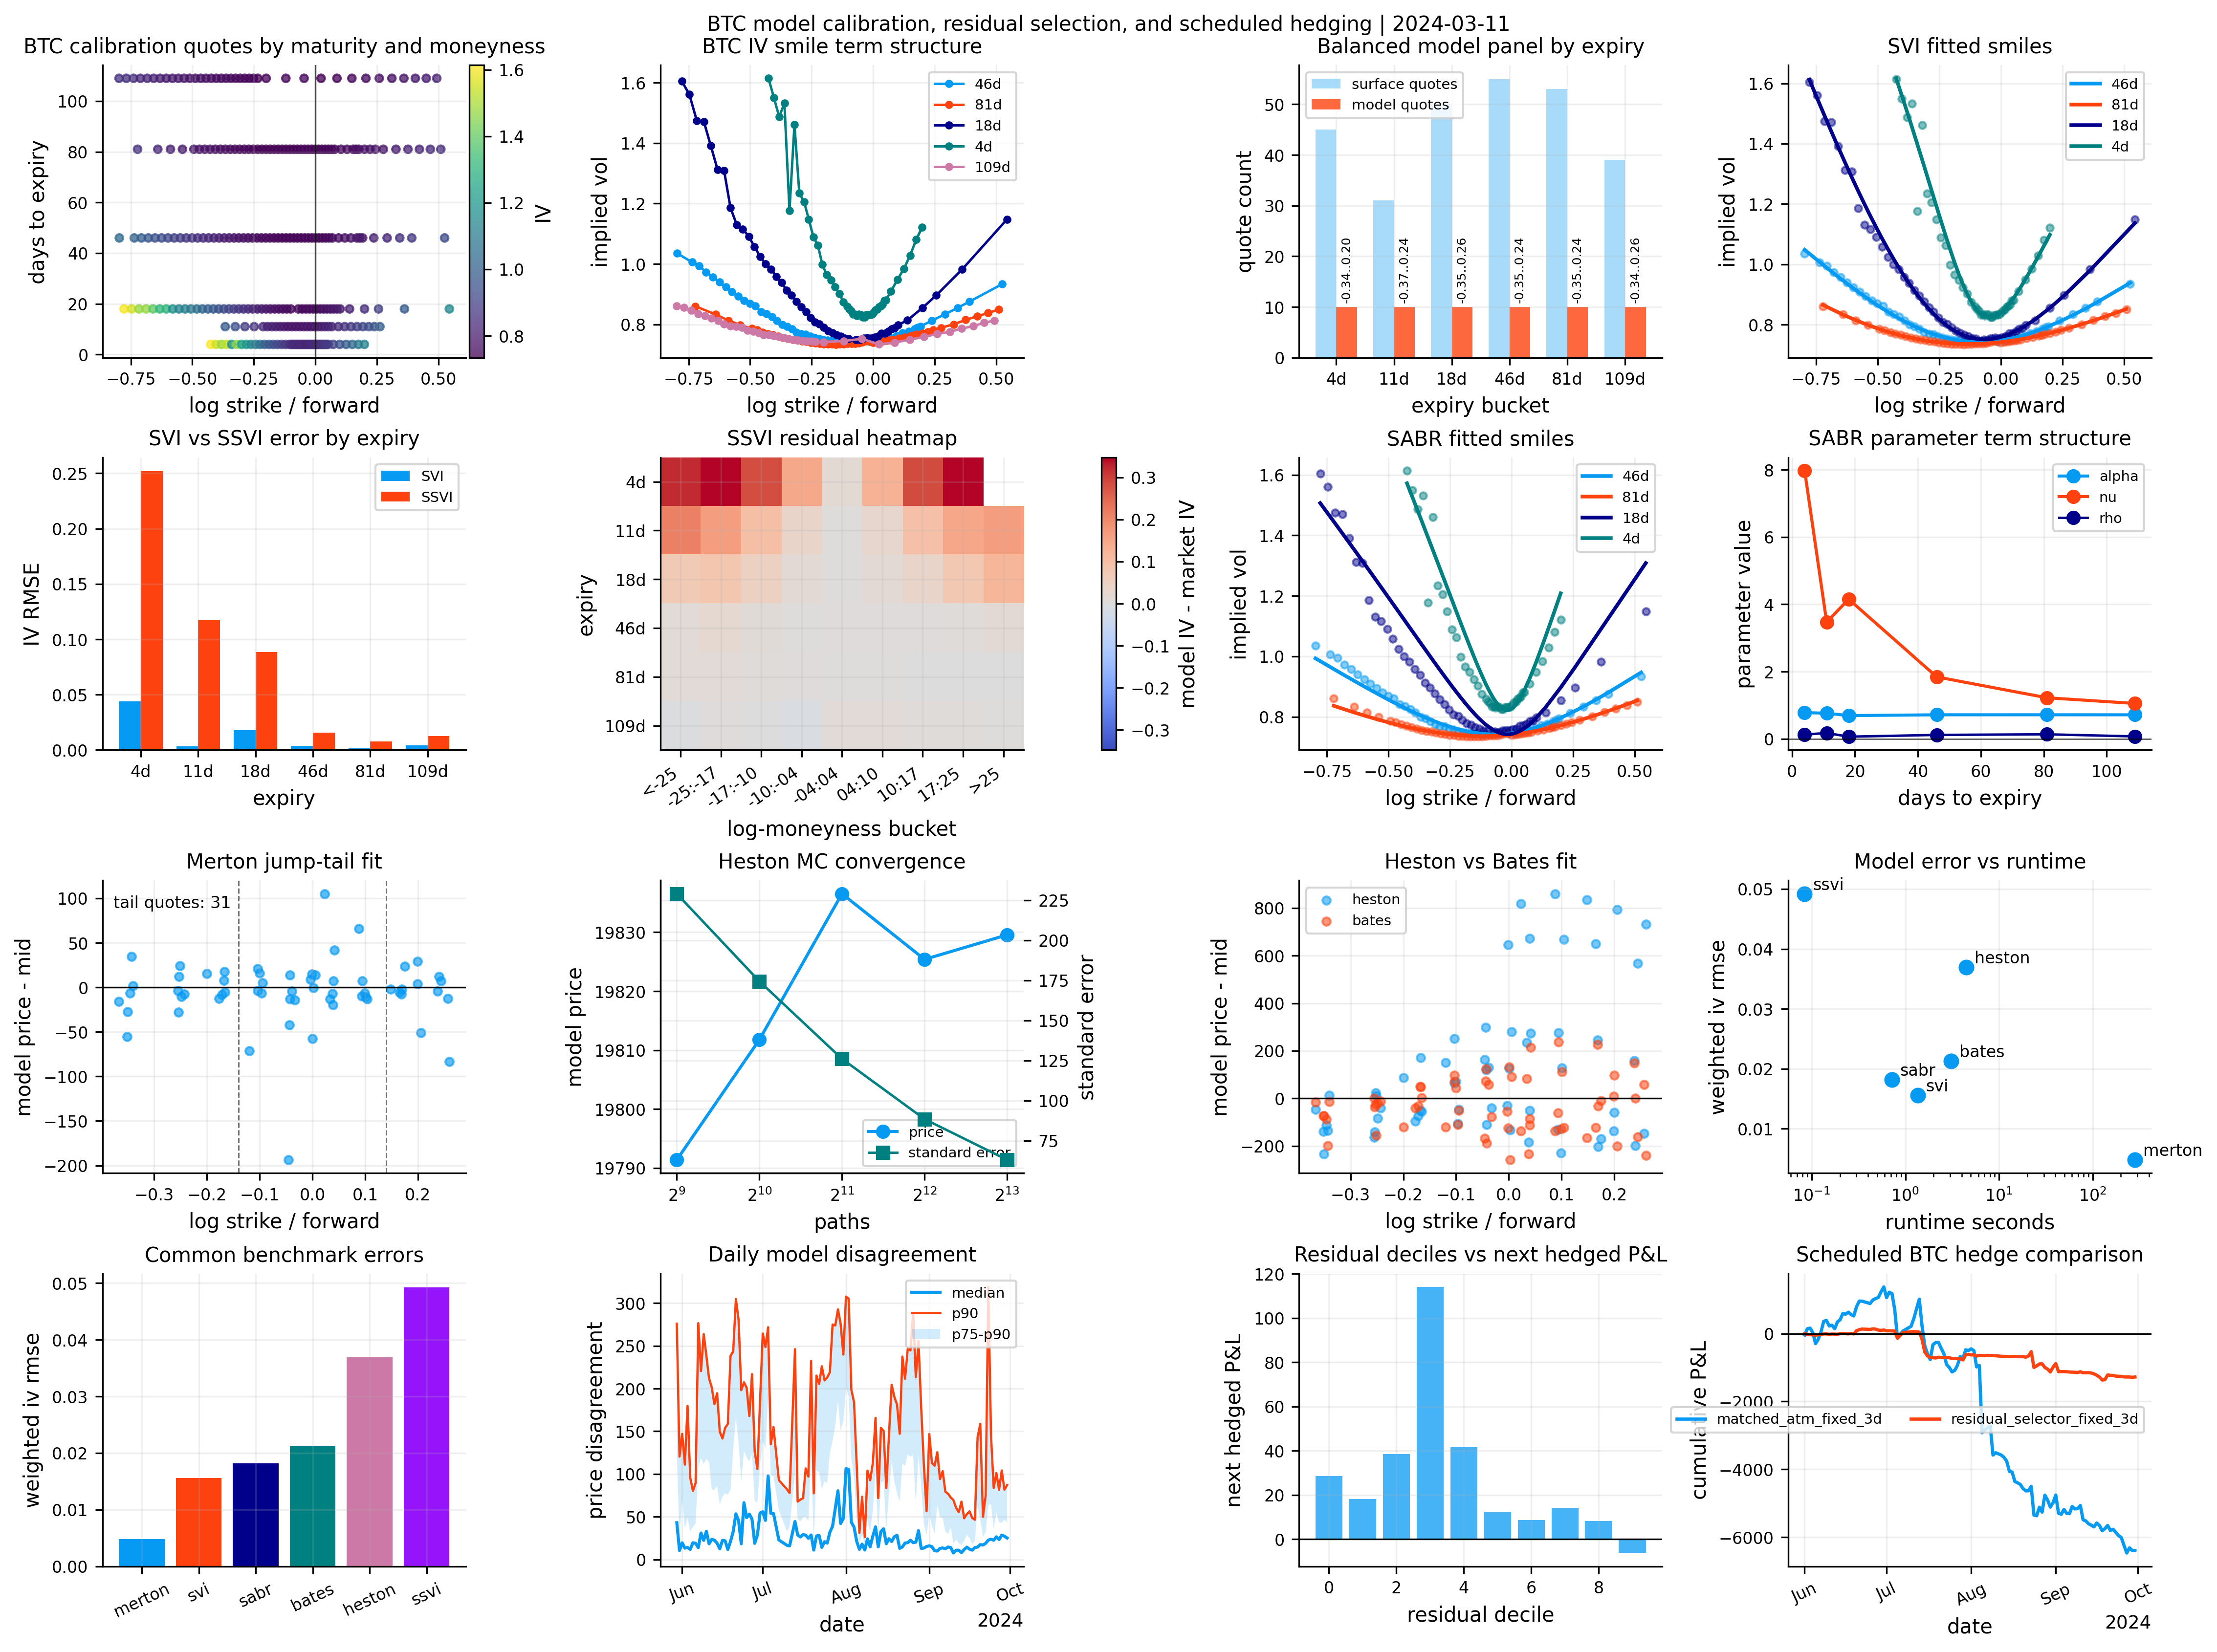

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from IPython.display import display

from quantfinlab.dataio.equity_ohlcv import load_ohlcv
from quantfinlab.dataio.option_chain import load_option_chain
from quantfinlab.dataio.rates import load_par_yield_curve

from quantfinlab.options.quote_cleaning import (
    attach_spot_from_series,
    convert_quotes_to_usd_equivalent,
    clean_option_quotes,
    surface_ready_quotes,
)
from quantfinlab.options.rates_dividends import (
    attach_rates,
    add_discount_factors,
    infer_carry_from_forward,
    infer_dividend_yield_from_forward,
)
from quantfinlab.options.parity import infer_forwards_from_parity
from quantfinlab.options.iv import implied_vol_table
from quantfinlab.options.greeks import compute_greeks_numpy
from quantfinlab.options.model_risk import (
    choose_model_engine,
    add_calibration_weights,
    calibration_quotes,
    choose_surface_date,
    balanced_model_quotes,
    common_model_quotes,
    compare_model_fits,
    model_fair_values,
    residual_scores,
    signal_dates,
    next_day_residual_check,
    residual_entry_schedule,
    market_summary,
)
from quantfinlab.options.svi import fit_svi_surface, fit_svi_holdout
from quantfinlab.options.ssvi import fit_ssvi_surface
from quantfinlab.options.sabr import fit_sabr_surface, fit_sabr_holdout
from quantfinlab.options.merton import fit_merton_jump_diffusion
from quantfinlab.options.heston import fit_heston_mc
from quantfinlab.options.bates import fit_bates_mc
from quantfinlab.backtest.options import (
    matched_option_schedule,
    hedge_book_from_schedules,
    run_scheduled_option_hedging_backtest,
    hedging_diagnostics,
    scheduled_hedge_comparison,
)
from quantfinlab.plotting.options import (
    calibration_quote_map,
    smile_term_structure,
    model_quote_overlay,
    svi_smiles,
    svi_ssvi_errors,
    ssvi_residuals,
    sabr_smiles,
    sabr_terms,
    merton_tail_fit,
    heston_mc_check,
    heston_bates_fit,
    model_speed_accuracy,
    benchmark_errors,
    model_disagreement,
    residual_deciles,
    scheduled_hedge_equity,
)

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
pd.set_option("display.max_columns", 120)

colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7", "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({"figure.figsize": (7, 3.5), "figure.dpi": 300, "savefig.dpi": 250, "axes.grid": True, "grid.alpha": 0.20, "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 11, "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8})

engine = "auto"
ann_days = 365.25
random_state = 7

root = Path.cwd()
if root.name.lower() == "notebooks":
    root = root.parent

data_dir = root / "data"

backend_report = choose_model_engine(engine=engine)
display(backend_report)

btc_spot = load_ohlcv(
    data_dir / "btc_usd_yfinance_2023_10_01_2024_10_15.csv",
    source="yfinance_csv",
    fields=("close",),
)
btc_spot = btc_spot["close"].rename("BTC")
btc_spot = btc_spot[btc_spot > 0]

btc_options = load_option_chain(
    data_dir / "btc_deribit_optiondx_2024_01_09.parquet",
    source="btc_deribit",
    annualization_days=365.0,
)

us_rates = load_par_yield_curve(
    data_dir / "par-yield-curve-rates-1990-2026.csv",
    source="us_treasury",
)

btc_quotes = attach_spot_from_series(
    btc_options,
    btc_spot,
    date_col="date",
    spot_col="spot",
    method="previous",
    overwrite=False,
)
btc_quotes = convert_quotes_to_usd_equivalent(
    btc_quotes,
    spot_col="spot",
    price_cols=("bid", "ask", "mid", "last", "mark"),
    unit="auto",
    contract_size=1.0,
)

clean_quotes, clean_report = clean_option_quotes(
    btc_quotes,
    min_dte=3,
    max_dte=180,
    moneyness_range=(0.45, 1.75),
    max_relative_spread=0.60,
    closest_atm_pairs=None,
    min_pairs_per_expiry=0,
    annualization_days=365.0,
)

rate_start = clean_quotes["date"].min() - pd.Timedelta(days=30)
rate_end = clean_quotes["date"].max()
us_rates = us_rates.loc[(us_rates.index >= rate_start) & (us_rates.index <= rate_end)].copy()

clean_quotes = attach_rates(
    clean_quotes,
    us_rates,
    date_col="date",
    tau_col="tau",
    out_col="rate",
)
clean_quotes = add_discount_factors(
    clean_quotes,
    rate_col="rate",
    tau_col="tau",
    out_col="discount_factor",
)
clean_quotes = infer_forwards_from_parity(
    clean_quotes,
    date_col="date",
    expiry_col="expiry",
    strike_col="strike",
    option_type_col="option_type",
    mid_col="mid",
    discount_col="discount_factor",
    spot_col="spot",
    out_col="forward",
)

forward_bad = ~np.isfinite(pd.to_numeric(clean_quotes["forward"], errors="coerce")) | (pd.to_numeric(clean_quotes["forward"], errors="coerce") <= 0)
forward_fallback = clean_quotes["spot"] * np.exp(clean_quotes["rate"].fillna(0.0) * clean_quotes["tau"].fillna(0.0))
clean_quotes.loc[forward_bad, "forward"] = forward_fallback.loc[forward_bad]
forward_report = pd.DataFrame([{"forward_fallback_share": float(forward_bad.mean()), "forward_fallback_rows": int(forward_bad.sum())}])

clean_quotes = infer_carry_from_forward(
    clean_quotes,
    spot_col="spot",
    forward_col="forward",
    tau_col="tau",
    out_col="implied_carry",
)
clean_quotes = infer_dividend_yield_from_forward(
    clean_quotes,
    rate_col="rate",
    carry_col="implied_carry",
    out_col="implied_dividend_yield",
)

iv_quotes = implied_vol_table(
    clean_quotes,
    price_cols=("bid", "mid", "ask"),
    option_type_col="option_type",
    spot_col="spot",
    forward_col="forward",
    strike_col="strike",
    tau_col="tau",
    rate_col="rate",
    discount_col="discount_factor",
    model="black76",
    engine=engine,
)
iv_quotes["iv_ok"] = iv_quotes["iv_mid_success"].fillna(False) & np.isfinite(iv_quotes["iv_mid"])
iv_quotes = compute_greeks_numpy(iv_quotes, iv_col="iv_mid")

surface_quotes = surface_ready_quotes(
    iv_quotes,
    min_iv=0.05,
    max_iv=3.50,
    min_tau=3 / 365.0,
    max_tau=180 / 365.0,
    min_weight=0.05,
    max_weight=20.0,
)
surface_quotes = add_calibration_weights(
    surface_quotes,
    price_uncertainty="half_spread",
    iv_uncertainty="spread_over_vega",
    expiry_balance=True,
)

btc_calibration = calibration_quotes(
    surface_quotes,
    min_dte=3.0,
    max_dte=120.0,
    min_vega=0.0,
    max_relative_spread=0.85,
    otm_only=True,
)

main_date = choose_surface_date(
    btc_calibration,
    min_expiries=4,
    min_quotes=80,
    prefer_tail_coverage=True,
)
btc_day = btc_calibration.loc[btc_calibration["date"].eq(main_date)].copy()

btc_model_quotes = balanced_model_quotes(
    btc_day,
    target_dtes=(7, 14, 21, 30, 45, 60),
    target_ks=(-0.35, -0.25, -0.17, -0.10, -0.04, 0.00, 0.04, 0.10, 0.17, 0.25),
    min_quotes_per_expiry=6,
    prefer_tail_coverage=True,
)

btc_svi = fit_svi_surface(
    btc_day,
    weight_col="obs_weight",
    engine=engine,
)
btc_ssvi = fit_ssvi_surface(
    btc_day,
    weight_col="obs_weight",
    engine=engine,
)
btc_sabr = fit_sabr_surface(
    btc_day,
    betas=(1.0, 0.7, 0.5),
    primary_beta=1.0,
    weight_col="obs_weight",
    engine=engine,
)
btc_merton = fit_merton_jump_diffusion(
    btc_model_quotes,
    weight_col="obs_weight",
    engine=engine,
    max_nfev=45,
    fit_by_expiry=True,
)
btc_heston = fit_heston_mc(
    btc_model_quotes,
    paths_opt=2048,
    paths_final=8192,
    steps_per_year=52,
    random_method="antithetic",
    common_random_numbers=True,
    engine=engine,
    random_state=random_state,
    max_nfev=70,
)
btc_bates = fit_bates_mc(
    btc_model_quotes,
    heston_start=btc_heston,
    jump_start=btc_merton,
    paths_opt=2048,
    paths_final=8192,
    steps_per_year=52,
    random_method="antithetic",
    common_random_numbers=True,
    engine=engine,
    random_state=random_state,
    max_nfev=60,
)

btc_common_quotes = common_model_quotes(
    btc_day,
    model_quotes=btc_model_quotes,
    min_tail_count=6,
)
model_comparison = compare_model_fits(
    btc_common_quotes,
    fits={
        "svi": btc_svi,
        "ssvi": btc_ssvi,
        "sabr": btc_sabr,
        "merton": btc_merton,
        "heston": btc_heston,
        "bates": btc_bates,
    },
    engine=engine,
)

dates_for_signal = signal_dates(
    btc_calibration,
    min_quotes=60,
    min_expiries=3,
    min_near_atm_quotes=10,
)
dates_for_signal = dates_for_signal[-120:]

btc_svi_daily = fit_svi_holdout(
    btc_calibration,
    dates=dates_for_signal,
    train_mode="anchor_strikes",
    weight_col="obs_weight",
    warm_start=True,
    engine=engine,
)
btc_sabr_daily = fit_sabr_holdout(
    btc_calibration,
    dates=dates_for_signal,
    beta=1.0,
    train_mode="anchor_strikes",
    weight_col="obs_weight",
    warm_start=True,
    engine=engine,
)

btc_fair_values = model_fair_values(
    btc_calibration,
    fits={"svi": btc_svi_daily, "sabr": btc_sabr_daily},
    ensemble_method="capped_weighted",
    max_model_weight=0.70,
    min_model_weight=0.30,
    engine=engine,
)
btc_scores = residual_scores(
    btc_fair_values,
    residual_col="ensemble_price_residual",
    quote_cost_col="half_spread",
    model_uncertainty_col="model_disagreement",
    score_method="cost_adjusted_z",
)
btc_validation = next_day_residual_check(
    btc_scores,
    option_quotes=btc_calibration,
    hedge_delta_col="delta",
    cost_model="scheduled",
    calendar="crypto_24_7",
    engine=engine,
)

btc_residual_schedule = residual_entry_schedule(
    btc_validation,
    selector_name="btc_residual_fixed_3d",
    hold_days=3,
    max_entries=60,
    entry_spacing_days=3,
    require_signal_direction=True,
    chronological=True,
)
btc_matched_schedule = matched_option_schedule(
    btc_residual_schedule,
    option_quotes=surface_quotes,
    same_date=True,
    same_option_type=True,
    same_quantity_sign=True,
    target_abs_delta=0.50,
    dte_tolerance_days=7,
    min_future_marks=3,
    selector_name="btc_matched_atm_fixed_3d",
)

schedule_report = pd.DataFrame([
    {"schedule": "residual", "entries": len(btc_residual_schedule)},
    {"schedule": "matched_atm", "entries": len(btc_matched_schedule)},
])

btc_hedge_book = hedge_book_from_schedules(
    surface_quotes,
    schedules=[btc_residual_schedule, btc_matched_schedule],
    lookahead_days=12,
)

empty_result = {
    "nav": pd.DataFrame(),
    "returns": pd.DataFrame(),
    "pnl": pd.DataFrame(),
    "components": pd.DataFrame(),
    "exposures": pd.DataFrame(),
    "trades": pd.DataFrame(),
    "summary": pd.DataFrame(),
    "diagnostics": {},
}

if btc_residual_schedule.empty or btc_matched_schedule.empty or btc_hedge_book.empty:
    btc_residual_results = empty_result
    btc_matched_results = empty_result
else:
    btc_residual_results = run_scheduled_option_hedging_backtest(
        option_path=btc_hedge_book,
        entry_schedule=btc_residual_schedule,
        spot_series=btc_spot,
        greeks=btc_hedge_book,
        hedge_price_series=btc_spot,
        hedge_dividend_series=None,
        hedge_beta_series=None,
        strategies=("unhedged", "delta"),
        option_multiplier=1.0,
        trading_cost_bps=2.0,
        use_bid_ask_costs=True,
        delta_band=0.10,
        delta_inner_band=0.03,
        delta_share_lot=0.001,
        delta_cooldown_days=0,
        max_hold_days=3,
        quote_price_unit="usd",
        valuation_currency="USD",
        pnl_mode="usd_equivalent",
        calendar="crypto_24_7",
        missing_option_mark="skip_day",
    )
    btc_matched_results = run_scheduled_option_hedging_backtest(
        option_path=btc_hedge_book,
        entry_schedule=btc_matched_schedule,
        spot_series=btc_spot,
        greeks=btc_hedge_book,
        hedge_price_series=btc_spot,
        hedge_dividend_series=None,
        hedge_beta_series=None,
        strategies=("unhedged", "delta"),
        option_multiplier=1.0,
        trading_cost_bps=2.0,
        use_bid_ask_costs=True,
        delta_band=0.10,
        delta_inner_band=0.03,
        delta_share_lot=0.001,
        delta_cooldown_days=0,
        max_hold_days=3,
        quote_price_unit="usd",
        valuation_currency="USD",
        pnl_mode="usd_equivalent",
        calendar="crypto_24_7",
        missing_option_mark="skip_day",
    )

btc_hedge_comparison = scheduled_hedge_comparison(
    {
        "matched_atm_fixed_3d": btc_matched_results,
        "residual_selector_fixed_3d": btc_residual_results,
    },
    normalize_by=("premium", "traded_notional", "initial_vega"),
)
btc_residual_diag = hedging_diagnostics(btc_residual_results)
btc_matched_diag = hedging_diagnostics(btc_matched_results)
btc_summary = market_summary(
    asset="btc",
    quotes=btc_day,
    model_comparison=model_comparison,
    validation=btc_validation,
    hedge_comparison=btc_hedge_comparison,
    engine=engine,
)

display(clean_report)
display(forward_report)
display(model_comparison)
display(btc_validation.attrs.get("summary", pd.DataFrame()))
display(schedule_report)
display(btc_hedge_comparison)
display(btc_residual_diag)
display(btc_matched_diag)
display(btc_summary)

fig = plt.figure(figsize=(15, 11), constrained_layout=True, dpi=300)
gs = fig.add_gridspec(4, 4)

ax_quote_map = fig.add_subplot(gs[0, 0])
ax_smile_terms = fig.add_subplot(gs[0, 1])
ax_model_overlay = fig.add_subplot(gs[0, 2])
ax_svi = fig.add_subplot(gs[0, 3])
ax_svi_ssvi = fig.add_subplot(gs[1, 0])
ax_ssvi_resid = fig.add_subplot(gs[1, 1])
ax_sabr_smiles = fig.add_subplot(gs[1, 2])
ax_sabr_params = fig.add_subplot(gs[1, 3])
ax_merton = fig.add_subplot(gs[2, 0])
ax_heston_mc = fig.add_subplot(gs[2, 1])
ax_heston_bates = fig.add_subplot(gs[2, 2])
ax_error_runtime = fig.add_subplot(gs[2, 3])
ax_benchmark = fig.add_subplot(gs[3, 0])
ax_disagreement = fig.add_subplot(gs[3, 1])
ax_deciles = fig.add_subplot(gs[3, 2])
ax_hedge = fig.add_subplot(gs[3, 3])

calibration_quote_map(ax_quote_map, btc_day, "k", "tau", "BTC calibration quotes by maturity and moneyness")
smile_term_structure(ax_smile_terms, btc_day, "k", "tau", "iv_mid", "BTC IV smile term structure")
model_quote_overlay(ax_model_overlay, btc_day, btc_model_quotes, "k", "tau", "Balanced model panel by expiry")
svi_smiles(ax_svi, btc_day, btc_svi, "SVI fitted smiles")
svi_ssvi_errors(ax_svi_ssvi, btc_svi, btc_ssvi, "SVI vs SSVI error by expiry")
ssvi_residuals(ax_ssvi_resid, btc_day, btc_ssvi, "SSVI residual heatmap")
sabr_smiles(ax_sabr_smiles, btc_day, btc_sabr, "SABR fitted smiles")
sabr_terms(ax_sabr_params, btc_sabr, "SABR parameter term structure")
merton_tail_fit(ax_merton, btc_model_quotes, btc_merton, "Merton jump-tail fit")
heston_mc_check(ax_heston_mc, btc_heston, "Heston MC convergence")
heston_bates_fit(ax_heston_bates, btc_model_quotes, btc_heston, btc_bates, "Heston vs Bates fit")
model_speed_accuracy(ax_error_runtime, model_comparison, "Model error vs runtime")
benchmark_errors(ax_benchmark, model_comparison, "Common benchmark errors")
model_disagreement(ax_disagreement, btc_fair_values, "Daily model disagreement")
residual_deciles(ax_deciles, btc_validation, "Residual deciles vs next hedged P&L")
scheduled_hedge_equity(ax_hedge, {"matched_atm_fixed_3d": btc_matched_results, "residual_selector_fixed_3d": btc_residual_results}, btc_hedge_comparison, "Scheduled BTC hedge comparison")

for ax in fig.axes:
    ax.title.set_fontsize(10)
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle(
    f"BTC model calibration, residual selection, and scheduled hedging | {pd.Timestamp(main_date).date()}",
    fontsize=10,
    y=1.01,
)

plt.show()


